In [ ]:
#@title Imports, dependencies, MNIST download and transformation selection

#@title SNN and MLP on Backprop v Feedback Alignment
import os
import io
import math
import random
import contextlib
import numpy as np
import scipy
import warnings
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

# IPython dependencies (if running in a notebook)
try:
    from IPython.display import Image, SVG, display
except ImportError:
    pass

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms

# snntorch dependencies
try:
    import snntorch as snn
    from snntorch import spikeplot as splt
    from snntorch import spikegen
except ImportError:
    print("snnTorch not found. Installing...")
    import subprocess
    subprocess.check_call(["pip", "install", "snntorch", "--quiet"])
    import snntorch as snn
    from snntorch import spikeplot as splt
    from snntorch import spikegen

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

class Config():
    def __init__(self):
        self.BATCH_SIZE = 128
        self.NUM_EPOCHS = 10 # Speed up training
        self.NUM_INPUTS = np.int64(28**2) # 28x28 images
        self.NUM_OUTPUTS = 3 #10 #3 #11
        self.NUM_HIDDEN = 100
        self.ACTIVATION = "leaky"
        self.BIAS = True

        self.BETA = 0.8 # Slope for leaky relu on SNN
        self.NUM_SNN_TIMESTEPS = 25

        self.ADAM_BETA = (0.9, 0.999)
        self.LEARNING_RULE = 3e-4

config = Config()

def download_mnist(train_prop=0.8, keep_prop=0.5, neuromatch_magic_normalize = 1):
    valid_prop = 1 - train_prop
    discard_prop = 1 - keep_prop

    if neuromatch_magic_normalize:
        norm_func = transforms.Normalize((0.1307,), (0.3081,))
    else:
        norm_func = transforms.Normalize((0,), (1,))

    transform = transforms.Compose([
              transforms.Resize((28, 28)),
              transforms.Grayscale(),
              transforms.ToTensor(),
              norm_func
              ])

    with contextlib.redirect_stdout(io.StringIO()):
        full_train_set = torchvision.datasets.MNIST(
            root="./data/", train=True, download=True, transform=transform,
        )
        full_test_set = torchvision.datasets.MNIST(
            root="./data/", train=False, download=True, transform=transform,
        )

    train_set, valid_set, _ = torch.utils.data.random_split(
        full_train_set,
        [train_prop * keep_prop, valid_prop * keep_prop, discard_prop]
    )
    test_set, _ = torch.utils.data.random_split(
        full_test_set,
        [keep_prop, discard_prop]
    )

    print("Number of examples retained:")
    print(f"  {len(train_set)} (training)")
    print(f"  {len(valid_set)} (validation)")
    print(f"  {len(test_set)} (test)")

    return train_set, valid_set, test_set

train_set, valid_set, test_set = download_mnist(train_prop=0.65,
                                                keep_prop=0.1,
                                                neuromatch_magic_normalize = 1)

BATCH_SIZE = config.BATCH_SIZE
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
valid_loader = torch.utils.data.DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)


Number of examples retained:
  3900 (training)
  2100 (validation)
  1000 (test)


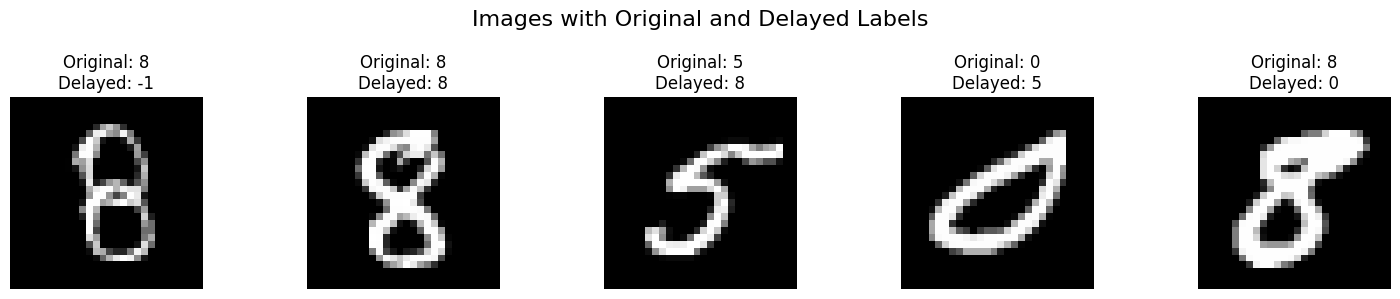

In [ ]:
#@markdown Plot some example images to make sure everything is loaded in properly

# Get an example batch
images, labels = next(iter(train_loader))

# Select the first 5 images and labels
num_examples = 5
example_images = images[:num_examples]
example_labels = labels[:num_examples]

# Apply a forward shift to create 'delayed' labels
delayed_labels = torch.cat((torch.tensor([-1]), example_labels[:-1]))

fig, axs = plt.subplots(1, num_examples, figsize=(15, 3))
for i in range(num_examples):
    axs[i].imshow(example_images[i].squeeze().cpu().numpy(), cmap='gray')
    axs[i].set_title(f"Original: {example_labels[i].item()}\nDelayed: {delayed_labels[i].item()}")
    axs[i].axis("off")
fig.suptitle("Images with Original and Delayed Labels", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()

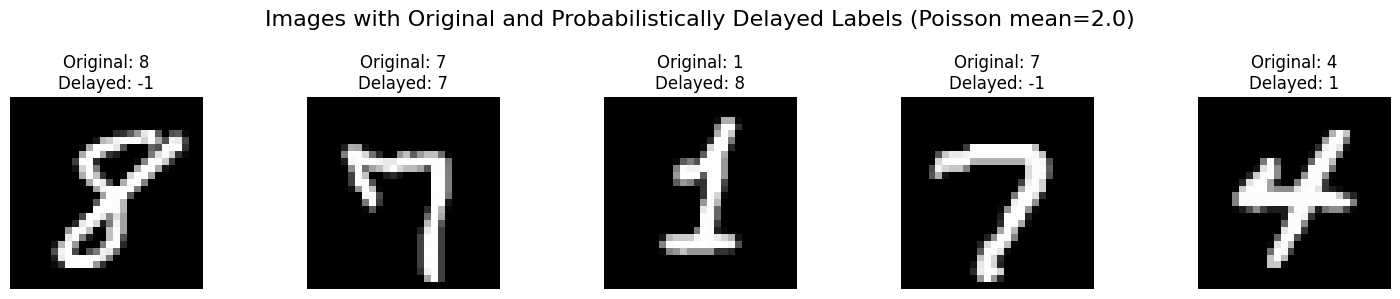

In [ ]:
#@markdown Probabilitic label delay on MNIST classification example

import torch
import numpy as np
import matplotlib.pyplot as plt
import random

def apply_probabilistic_delayed_labels(original_labels, num_examples, delay_mean=1.0):
    """
    Applies a probabilistic forward shift to labels with conflict resolution.

    Args:
        original_labels (torch.Tensor): The original labels for the batch.
        num_examples (int): The number of examples in the batch (determines the size
                            of the delayed labels array).
        delay_mean (float): The mean (lambda) for the Poisson distribution to determine
                            the delay amount for each label.

    Returns:
        torch.Tensor: A tensor of the new, probabilistically delayed labels.
                      Labels that are pushed out of bounds or for unassigned slots are -1.
    """
    # Initialize delayed_labels with a special value indicating empty/no label
    delayed_labels = torch.full((num_examples,), -1, dtype=torch.long)

    # Store tuples of (original_index, desired_delay_amount, original_label_value)
    label_delay_info = []

    # 1. Generate desired delay amounts for each label
    for i, label in enumerate(original_labels):
        # Generate delay amount using Poisson distribution
        delay_amount = np.random.poisson(delay_mean)
        label_delay_info.append((i, delay_amount, label.item()))

    # Sort by original_index to ensure 'sequential resolution' based on original position.
    # The label that appeared earlier in the original batch has priority if they conflict.
    label_delay_info.sort(key=lambda x: x[0])

    # 2. Apply delays and resolve conflicts
    # Use a boolean array to track occupied slots for efficient checking
    occupied_slots = [False] * num_examples

    for original_idx, delay_amount, label_value in label_delay_info:
        desired_target_idx = original_idx + delay_amount

        # Find the next available slot for this label, starting from its desired position
        current_target_idx = desired_target_idx
        while current_target_idx < num_examples and occupied_slots[current_target_idx]:
            current_target_idx += 1

        # Place the label if a slot is found within bounds
        if current_target_idx < num_examples:
            delayed_labels[current_target_idx] = label_value
            occupied_slots[current_target_idx] = True
        # If current_target_idx >= num_examples, the label is effectively 'lost'
        # or pushed out of the window. Its corresponding slot in delayed_labels
        # will remain -1.

    return delayed_labels

# --- Example Usage ---

# Get an example batch from the DataLoader
images, labels = next(iter(train_loader))

# Select the first N images and labels for demonstration
num_examples_to_plot = 5 # You can adjust this number
example_images = images[:num_examples_to_plot]
example_labels = labels[:num_examples_to_plot]

# User can select the probability distribution parameters.
# Here, we use a Poisson distribution for delay_amount.
# 'delay_mean_param' titrates the average number of steps a label is delayed.
delay_mean_param = 2.0 # Adjust this value to change the average delay

prob_delayed_labels = apply_probabilistic_delayed_labels(
    example_labels, num_examples_to_plot, delay_mean=delay_mean_param
)

# Plotting the images with original and probabilistically delayed labels
fig, axs = plt.subplots(1, num_examples_to_plot, figsize=(15, 3))
for i in range(num_examples_to_plot):
    axs[i].imshow(example_images[i].squeeze().cpu().numpy(), cmap='gray')
    axs[i].set_title(f"Original: {example_labels[i].item()}\nDelayed: {prob_delayed_labels[i].item()}")
    axs[i].axis("off")
fig.suptitle(f"Images with Original and Probabilistically Delayed Labels (Poisson mean={delay_mean_param})", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()

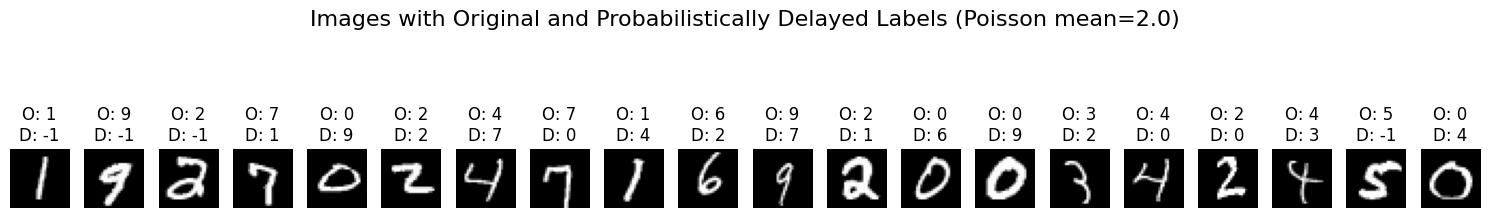

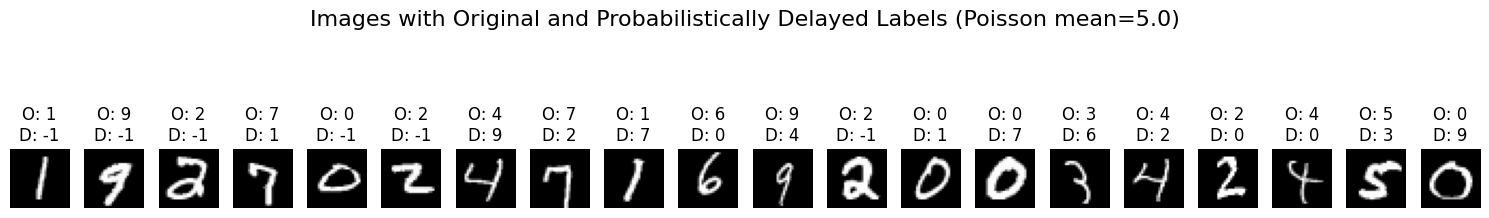

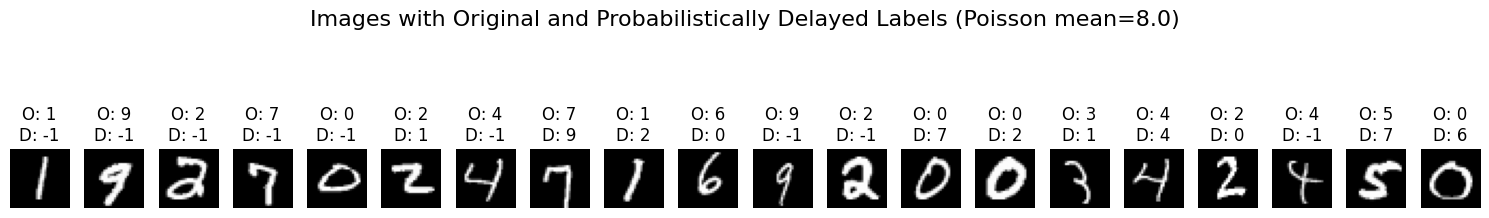

In [ ]:
#@markdown 3 other examples, now a larger batch, each with different delay probabilities
#@markdown Avg. Delays are 2, 5 and 8 steps
# Get an example batch from the DataLoader
images, labels = next(iter(train_loader))

# Select the first N images and labels for demonstration
num_examples_to_plot = 20 # You can adjust this number
example_images = images[:num_examples_to_plot]
example_labels = labels[:num_examples_to_plot]

# User can select the probability distribution parameters.
# Here, we use a Poisson distribution for delay_amount.
# 'delay_mean_param' titrates the average number of steps a label is delayed.
delay_mean_param = 2.0 # Adjust this value to change the average delay

prob_delayed_labels = apply_probabilistic_delayed_labels(
    example_labels, num_examples_to_plot, delay_mean=delay_mean_param
)

# Plotting the images with original and probabilistically delayed labels
fig, axs = plt.subplots(1, num_examples_to_plot, figsize=(15, 3))
for i in range(num_examples_to_plot):
    axs[i].imshow(example_images[i].squeeze().cpu().numpy(), cmap='gray')
    axs[i].set_title(f"O: {example_labels[i].item()}\nD: {prob_delayed_labels[i].item()}")
    axs[i].axis("off")
fig.suptitle(f"Images with Original and Probabilistically Delayed Labels (Poisson mean={delay_mean_param})", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()



# Select the first N images and labels for demonstration
num_examples_to_plot = 20 # You can adjust this number
example_images = images[:num_examples_to_plot]
example_labels = labels[:num_examples_to_plot]

# User can select the probability distribution parameters.
# Here, we use a Poisson distribution for delay_amount.
# 'delay_mean_param' titrates the average number of steps a label is delayed.
delay_mean_param = 5.0 # Adjust this value to change the average delay

prob_delayed_labels = apply_probabilistic_delayed_labels(
    example_labels, num_examples_to_plot, delay_mean=delay_mean_param
)

# Plotting the images with original and probabilistically delayed labels
fig, axs = plt.subplots(1, num_examples_to_plot, figsize=(15, 3))
for i in range(num_examples_to_plot):
    axs[i].imshow(example_images[i].squeeze().cpu().numpy(), cmap='gray')
    axs[i].set_title(f"O: {example_labels[i].item()}\nD: {prob_delayed_labels[i].item()}")
    axs[i].axis("off")
fig.suptitle(f"Images with Original and Probabilistically Delayed Labels (Poisson mean={delay_mean_param})", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()

# Select the first N images and labels for demonstration
num_examples_to_plot = 20 # You can adjust this number
example_images = images[:num_examples_to_plot]
example_labels = labels[:num_examples_to_plot]

# User can select the probability distribution parameters.
# Here, we use a Poisson distribution for delay_amount.
# 'delay_mean_param' titrates the average number of steps a label is delayed.
delay_mean_param = 8.0 # Adjust this value to change the average delay

prob_delayed_labels = apply_probabilistic_delayed_labels(
    example_labels, num_examples_to_plot, delay_mean=delay_mean_param
)

# Plotting the images with original and probabilistically delayed labels
fig, axs = plt.subplots(1, num_examples_to_plot, figsize=(15, 3))
for i in range(num_examples_to_plot):
    axs[i].imshow(example_images[i].squeeze().cpu().numpy(), cmap='gray')
    axs[i].set_title(f"O: {example_labels[i].item()}\nD: {prob_delayed_labels[i].item()}")
    axs[i].axis("off")
fig.suptitle(f"Images with Original and Probabilistically Delayed Labels (Poisson mean={delay_mean_param})", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()

In [ ]:

#@markdown `restrict_classes(dataset)`: Keeps specified classes in a dataset.

def restrict_classes(dataset, classes=[6], keep=True):
  """
  Removes or keeps specified classes in a dataset.

  Arguments:
  - dataset (torch dataset or subset): Dataset with class targets.
  - classes (list): List of classes to keep or remove.
  - keep (bool): If True, the classes specified are kept. If False, they are
  removed.

  Returns:
  - new_dataset (torch dataset or subset): Datset restricted as specified.
  """

  if hasattr(dataset, "dataset"):
    indices = np.asarray(dataset.indices)
    targets = dataset.dataset.targets[indices]
    dataset = dataset.dataset
  else:
    indices = np.arange(len(dataset))
    targets = dataset.targets

  specified_idxs = np.isin(targets, np.asarray(classes))
  if keep:
    retain_indices = indices[specified_idxs]
  else:
    retain_indices = indices[~specified_idxs]

  new_dataset = torch.utils.data.Subset(dataset, retain_indices)

  return new_dataset

In [ ]:
#@markdown restrict classes and probabilistically forward-delay labels

import torch
import numpy as np
import matplotlib.pyplot as plt
import random
import warnings

def create_delayed_dataloader(original_dataloader, delay_mean, num_desired_labels=None, classes_to_filter=None):
    """
    Creates a new DataLoader that yields probabilistically delayed labels for each batch.
    Optionally, filters the dataset to include only a specified number of unique classes.

    Args:
        original_dataloader (torch.utils.data.DataLoader): The original DataLoader.
        delay_mean (float): The mean (lambda) for the Poisson distribution to determine
                            the delay amount for each label, used by
                            apply_probabilistic_delayed_labels.
        num_desired_labels (int, optional): If specified and `classes_to_filter` is None,
                                            the dataset will be filtered to include only
                                            this many randomly selected unique classes.
                                            Labels for these classes will be remapped to be 0-indexed.
                                            Defaults to None.
        classes_to_filter (list, optional): A specific list of class labels to filter the
                                            dataset by. If provided, this list overrides the
                                            random sampling based on `num_desired_labels`.
                                            Defaults to None.

    Returns:
        torch.utils.data.DataLoader: A new DataLoader yielding (images, delayed_labels).
    """

    dataset_for_loader = original_dataloader.dataset
    selected_classes_map = None # Initialize to None

    if num_desired_labels is not None or classes_to_filter is not None:
        if classes_to_filter is not None:
            selected_classes = classes_to_filter
            num_actual_output_classes = len(selected_classes)
            print(f"Dataset will be filtered to include *pre-selected* classes: {sorted(selected_classes)}")
        else:
            # Determine the effective labels of the dataset in the dataloader
            if isinstance(original_dataloader.dataset, torch.utils.data.Subset):
                # If it's a Subset, get labels from the base dataset through its indices
                base_dataset = original_dataloader.dataset.dataset
                current_subset_indices = original_dataloader.dataset.indices
                if hasattr(base_dataset, 'targets'):
                    all_labels_in_current_scope = [base_dataset.targets[i].item() for i in current_subset_indices]
                elif hasattr(base_dataset, 'labels'):
                    all_labels_in_current_scope = [base_dataset.labels[i].item() for i in current_subset_indices]
                else:
                    raise AttributeError("Underlying base dataset has no 'targets' or 'labels' attribute for filtering.")
            else:
                # If it's a direct dataset, get labels directly
                if hasattr(original_dataloader.dataset, 'targets'):
                    all_labels_in_current_scope = original_dataloader.dataset.targets.tolist()
                elif hasattr(original_dataloader.dataset, 'labels'):
                    all_labels_in_current_scope = original_dataloader.dataset.labels.tolist()
                else:
                    raise AttributeError("Dataset has no 'targets' or 'labels' attribute for filtering.")

            unique_classes_in_scope = torch.unique(torch.tensor(all_labels_in_current_scope)).tolist()

            if num_desired_labels > len(unique_classes_in_scope):
                print(f"Warning: num_desired_labels ({num_desired_labels}) is greater than available unique classes ({len(unique_classes_in_scope)}). Using all available classes.")
                selected_classes = unique_classes_in_scope
                num_actual_output_classes = len(unique_classes_in_scope)
            else:
                selected_classes = random.sample(unique_classes_in_scope, num_desired_labels)
                num_actual_output_classes = num_desired_labels

            print(f"Dataset will be filtered to include only classes: {sorted(selected_classes)}")

        print(f"If you are using models, you might need to update `config.NUM_OUTPUTS` to {num_actual_output_classes} accordingly.")

        # Create a mapping from original class labels to new 0-indexed labels
        selected_classes_map = {original_label: new_label for new_label, original_label in enumerate(sorted(selected_classes))}

        # Use the restrict_classes helper function
        dataset_for_loader = restrict_classes(original_dataloader.dataset, classes=selected_classes, keep=True)


    def custom_collate_fn(batch):
        # batch is a list of (image, original_label) tuples
        images = torch.stack([item[0] for item in batch])
        original_labels_raw = [item[1] for item in batch] # These are from the original dataset/subset

        # Apply remapping if filtering was applied
        if selected_classes_map:
            # The labels obtained from `item[1]` can be Tensors or Python ints,
            # handle both cases when accessing the class_mapping.
            original_labels_tensor = torch.tensor([
                selected_classes_map[label.item() if isinstance(label, torch.Tensor) else label]
                for label in original_labels_raw
            ])
        else:
            original_labels_tensor = torch.tensor(original_labels_raw)

        num_examples_in_batch = len(batch)
        delayed_labels = apply_probabilistic_delayed_labels(
            original_labels_tensor, num_examples_in_batch, delay_mean=delay_mean
        )

        return images, delayed_labels

    # Prepare arguments for the new DataLoader
    dataloader_kwargs = {
        'dataset': dataset_for_loader, # Use the potentially filtered dataset
        'num_workers': original_dataloader.num_workers,
        'collate_fn': custom_collate_fn,
        'pin_memory': original_dataloader.pin_memory,
        'timeout': original_dataloader.timeout,
        'worker_init_fn': original_dataloader.worker_init_fn
    }

    # Always set batch_size, drop_last, and shuffle, letting DataLoader create the appropriate sampler.
    # This avoids issues where the original sampler (which was tied to the original dataset length)
    # is passed directly to a DataLoader wrapping a new, possibly smaller, Subset.
    dataloader_kwargs['batch_size'] = original_dataloader.batch_size
    dataloader_kwargs['drop_last'] = original_dataloader.drop_last
    # Check if the original DataLoader was shuffled, and replicate that behavior.
    # DataLoader creates a RandomSampler if shuffle=True, and SequentialSampler otherwise.
    dataloader_kwargs['shuffle'] = original_dataloader.shuffle if hasattr(original_dataloader, 'shuffle') else False

    # If a batch_sampler was explicitly provided to the original DataLoader,
    # replicating its exact behavior with a filtered subset is non-trivial.
    # For now, we will proceed with the assumption that the DataLoader will internally
    # create a standard sampler (Random or Sequential) based on the 'shuffle' flag.
    # If the user used a custom `batch_sampler`, this might need further customization.
    # A warning is appropriate here if batch_sampler is not None, as we are ignoring it.
    if original_dataloader.batch_sampler is not None:
        warnings.warn("Original DataLoader has a custom `batch_sampler`. "
                      "For the filtered DataLoader, `batch_size`, `drop_last`, "
                      "and `shuffle` from the original DataLoader will be used "
                      "to create a standard internal sampler. The custom `batch_sampler` "
                      "will not be directly re-used.")

    return torch.utils.data.DataLoader(**dataloader_kwargs)

# Example Usage with num_desired_labels:
print("\nCreating a new train_loader with delayed labels (mean delay = 2.0) and 2 desired classes...")

# Update config.NUM_OUTPUTS before initializing models if filtering
# This is illustrative; in a real scenario, you'd modify config before model definition cells
# For this example, we'll just demonstrate the DataLoader output
original_num_outputs = config.NUM_OUTPUTS # Store original to restore later if needed
num_desired_classes_example = 2
# config.NUM_OUTPUTS = num_desired_classes_example + 1 # +1 for the -1 label if it counts as a class - commented out to avoid global side-effect in this example

delayed_train_loader_filtered = create_delayed_dataloader(
    train_loader, delay_mean=2.0, num_desired_labels=num_desired_classes_example
)

images_batch_filtered, delayed_labels_batch_filtered = next(iter(delayed_train_loader_filtered))

print(f"Shape of images batch (filtered): {images_batch_filtered.shape}")
print(f"Shape of delayed labels batch (filtered): {delayed_labels_batch_filtered.shape}")
print(f"First 10 delayed labels from the batch (filtered): {delayed_labels_batch_filtered[:10]}")
print(f"Unique delayed labels (filtered): {torch.unique(delayed_labels_batch_filtered)}")

# Restore original config.NUM_OUTPUTS if not intended for global change
# config.NUM_OUTPUTS = original_num_outputs # commented out for the same reason
# print(f"Restored config.NUM_OUTPUTS to {config.NUM_OUTPUTS}")

print("\nCreating a new train_loader with delayed labels (mean delay = 2.0) without filtering...")

# Create a new DataLoader with probabilistic delayed labels for the training set (no filtering)
delayed_train_loader_unfiltered = create_delayed_dataloader(train_loader, delay_mean=2.0)

# Get an example batch from the new delayed dataloader
images_batch_unfiltered, delayed_labels_batch_unfiltered = next(iter(delayed_train_loader_unfiltered))

print(f"Shape of images batch: {images_batch_unfiltered.shape}")
print(f"Shape of delayed labels batch: {delayed_labels_batch_unfiltered.shape}")
print(f"First 10 delayed labels from the batch: {delayed_labels_batch_unfiltered[:10]}")
print(f"Unique delayed labels (unfiltered): {torch.unique(delayed_labels_batch_unfiltered)}")

# You can now use `delayed_train_loader_filtered` or `delayed_train_loader_unfiltered` for training with the new label structure.


Creating a new train_loader with delayed labels (mean delay = 2.0) and 2 desired classes...
Dataset will be filtered to include only classes: [0, 9]
If you are using models, you might need to update `config.NUM_OUTPUTS` to 2 accordingly.
Shape of images batch (filtered): torch.Size([128, 1, 28, 28])
Shape of delayed labels batch (filtered): torch.Size([128])
First 10 delayed labels from the batch (filtered): tensor([-1, -1,  0,  1,  1,  1,  1,  1, -1, -1])
Unique delayed labels (filtered): tensor([-1,  0,  1])

Creating a new train_loader with delayed labels (mean delay = 2.0) without filtering...
Shape of images batch: torch.Size([128, 1, 28, 28])
Shape of delayed labels batch: torch.Size([128])
First 10 delayed labels from the batch: tensor([0, 3, 1, 3, 6, 1, 3, 3, 5, 2])
Unique delayed labels (unfiltered): tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


/tmp/ipykernel_769/2758462264.py:132: UserWarning: Original DataLoader has a custom `batch_sampler`. For the filtered DataLoader, `batch_size`, `drop_last`, and `shuffle` from the original DataLoader will be used to create a standard internal sampler. The custom `batch_sampler` will not be directly re-used.
  warnings.warn("Original DataLoader has a custom `batch_sampler`. "


Dataset will be filtered to include only classes: [0, 6]
If you are using models, you might need to update `config.NUM_OUTPUTS` to 2 accordingly.


/tmp/ipykernel_769/2758462264.py:132: UserWarning: Original DataLoader has a custom `batch_sampler`. For the filtered DataLoader, `batch_size`, `drop_last`, and `shuffle` from the original DataLoader will be used to create a standard internal sampler. The custom `batch_sampler` will not be directly re-used.
  warnings.warn("Original DataLoader has a custom `batch_sampler`. "


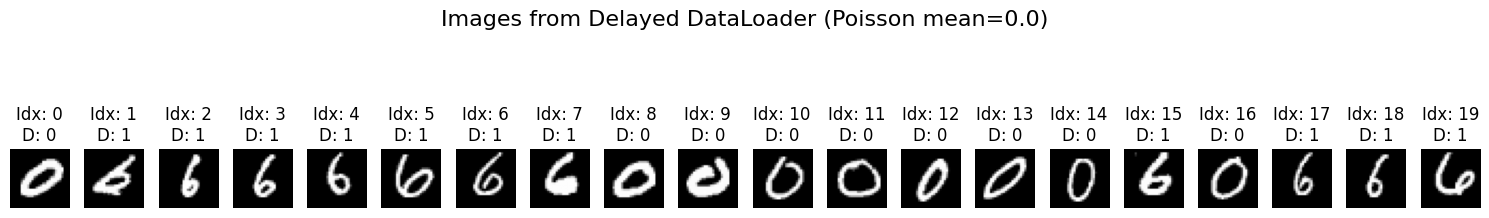

Dataset will be filtered to include only classes: [2, 6]
If you are using models, you might need to update `config.NUM_OUTPUTS` to 2 accordingly.


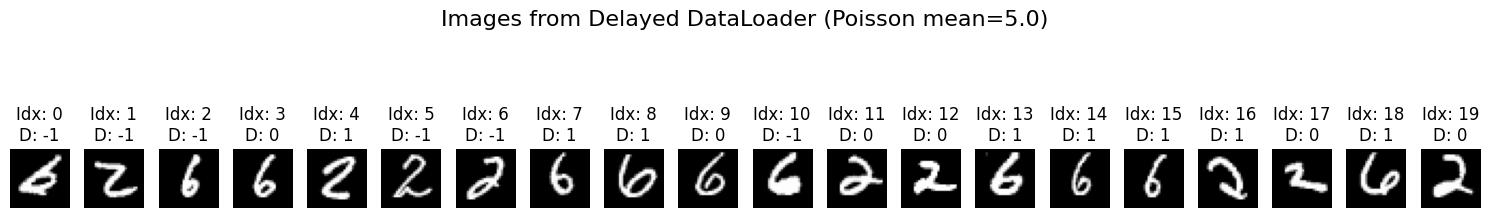

Dataset will be filtered to include only classes: [3, 7]
If you are using models, you might need to update `config.NUM_OUTPUTS` to 2 accordingly.


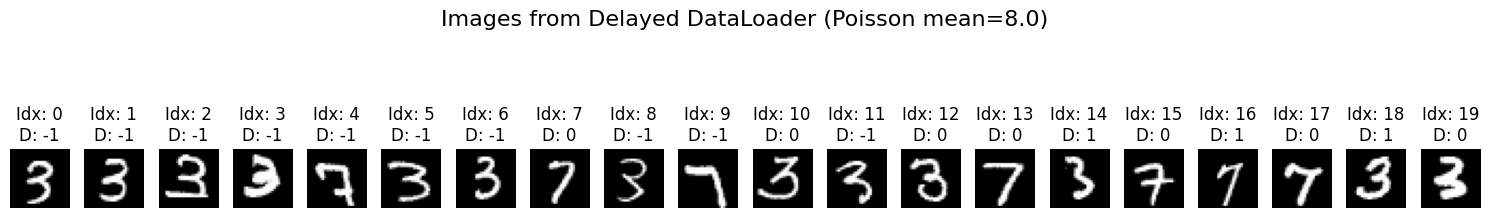

In [ ]:
#@markdown 3 other examples, now a larger batch, each with different delay probabilities
#@markdown Avg. Delays are 2, 5 and 8 steps

# This cell replicates the visualization from a previous example (cell `uLDhLup_jKR2`),
# demonstrating probabilistic label delays using the 'apply_probabilistic_delayed_labels' function.

# --- Example with delay_mean_param = 2.0 ---
# Create a delayed dataloader for this delay mean
delay_mean_param_2 = 0.0
delayed_train_loader_2 = create_delayed_dataloader(train_loader, delay_mean=delay_mean_param_2, num_desired_labels=2)

# Get an example batch from the delayed DataLoader
images, prob_delayed_labels = next(iter(delayed_train_loader_2))

# Since the labels from the delayed_train_loader are already probabilistically delayed,
# we need to get the original labels from the dataset directly for comparison in the title.
# This assumes the dataset is wrapped in the dataloader.

num_examples_to_plot = 20 # You can adjust this number
example_images = images[:num_examples_to_plot]
# To get original labels, we would ideally need to store them or retrieve them
# from the original dataset. For now, we will use the delayed labels directly in the plot title.
# The 'O:' will represent the index in the batch, and 'D:' will be the delayed label.

# Plotting the images with probabilistically delayed labels
fig, axs = plt.subplots(1, num_examples_to_plot, figsize=(15, 3))
for i in range(num_examples_to_plot):
    axs[i].imshow(example_images[i].squeeze().cpu().numpy(), cmap='gray')
    axs[i].set_title(f"Idx: {i}\nD: {prob_delayed_labels[i].item()}")
    axs[i].axis("off")
fig.suptitle(f"Images from Delayed DataLoader (Poisson mean={delay_mean_param_2})", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()


# --- Example with delay_mean_param = 5.0 ---
# Create a delayed dataloader for this delay mean
delay_mean_param_5 = 5.0
delayed_train_loader_5 = create_delayed_dataloader(train_loader, delay_mean=delay_mean_param_5, num_desired_labels=2)

# Get an example batch from the delayed DataLoader
images, prob_delayed_labels = next(iter(delayed_train_loader_5))

num_examples_to_plot = 20 # You can adjust this number
example_images = images[:num_examples_to_plot]

# Plotting the images with probabilistically delayed labels
fig, axs = plt.subplots(1, num_examples_to_plot, figsize=(15, 3))
for i in range(num_examples_to_plot):
    axs[i].imshow(example_images[i].squeeze().cpu().numpy(), cmap='gray')
    axs[i].set_title(f"Idx: {i}\nD: {prob_delayed_labels[i].item()}")
    axs[i].axis("off")
fig.suptitle(f"Images from Delayed DataLoader (Poisson mean={delay_mean_param_5})", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()

# --- Example with delay_mean_param = 8.0 ---
# Create a delayed dataloader for this delay mean
delay_mean_param_8 = 8.0
delayed_train_loader_8 = create_delayed_dataloader(train_loader, delay_mean=delay_mean_param_8, num_desired_labels=2)

# Get an example batch from the delayed DataLoader
images, prob_delayed_labels = next(iter(delayed_train_loader_8))

num_examples_to_plot = 20 # You can adjust this number
example_images = images[:num_examples_to_plot]

# Plotting the images with probabilistically delayed labels
fig, axs = plt.subplots(1, num_examples_to_plot, figsize=(15, 3))
for i in range(num_examples_to_plot):
    axs[i].imshow(example_images[i].squeeze().cpu().numpy(), cmap='gray')
    axs[i].set_title(f"Idx: {i}\nD: {prob_delayed_labels[i].item()}")
    axs[i].axis("off")
fig.suptitle(f"Images from Delayed DataLoader (Poisson mean={delay_mean_param_8})", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()

In [ ]:
#@markdown Define models for MLP and SNN feedforward networks.
#@markdown They will be trained with backprop for now

class MultiLayerPerceptron(torch.nn.Module):
    def __init__(self, num_inputs=config.NUM_INPUTS, num_hidden=config.NUM_HIDDEN, num_outputs=config.NUM_OUTPUTS, activation_type="leaky", bias=False):
        super().__init__()
        self.num_inputs = num_inputs
        self.num_hidden = num_hidden
        self.num_outputs = num_outputs
        self.bias = bias

        self.lin1 = torch.nn.Linear(num_inputs, num_hidden, bias=bias)
        self.lin2 = torch.nn.Linear(num_hidden, num_outputs, bias=bias)
        self.activation = torch.nn.LeakyReLU(config.BETA)

    def forward(self, X, y=None):
        h = self.activation(self.lin1(X.reshape(-1, self.num_inputs)))
        y_pred = self.lin2(h)
        return y_pred

class SNN_MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(config.NUM_INPUTS, config.NUM_HIDDEN)
        self.lif1 = snn.Leaky(beta=config.BETA)
        self.fc2 = nn.Linear(config.NUM_HIDDEN, config.NUM_OUTPUTS)
        self.lif2 = snn.Leaky(beta=config.BETA)

    def forward(self, x):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        spk2_rec, mem2_rec = [], []

        for step in range(config.NUM_SNN_TIMESTEPS):
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            spk2_rec.append(spk2)
            mem2_rec.append(mem2)

        return torch.stack(spk2_rec, dim=0), torch.stack(mem2_rec, dim=0)


In [ ]:
#@markdown Define models for recurrent networks.
#@markdown They will be trained with backprop for now

#### TODO: add recurrent MLP
# class RecurrentPerceptron(torch.nn.Module):
#     def __init__(self, num_inputs=config.NUM_INPUTS, num_hidden=config.NUM_HIDDEN, num_outputs=config.NUM_OUTPUTS, activation_type="leaky", bias=False):


class SNN_rec(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(config.NUM_INPUTS, config.NUM_HIDDEN)
        self.lif1 = snn.RLeaky(beta=config.BETA, linear_features=config.NUM_HIDDEN,
                                all_to_all=True
                               )
        self.fc2 = nn.Linear(config.NUM_HIDDEN, config.NUM_OUTPUTS)
        self.lif2 = snn.RLeaky(beta=config.BETA, linear_features=config.NUM_OUTPUTS, # Changed from config.NUM_HIDDEN to config.NUM_OUTPUTS
                                all_to_all=True
                               )

    def forward(self, x):
        spk1,mem1 = self.lif1.init_rleaky()
        spk2,mem2 = self.lif1.init_rleaky()
        spk2_rec, mem2_rec = [], []

        for step in range(config.NUM_SNN_TIMESTEPS):
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, spk1, mem1)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, spk2, mem2)
            spk2_rec.append(spk2)
            mem2_rec.append(mem2)

        return torch.stack(spk2_rec, dim=0), torch.stack(mem2_rec, dim=0)

In [ ]:
#@markdown define training loops, optimizers and instantiate models

def train_snn_model(model, optimizer, train_loader, test_loader, num_epochs=config.NUM_EPOCHS):
    """
    Generic training loop for SNNs (works for both standard and Feedback Alignment).
    """
    model.to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=-1)
    loss_hist, test_loss_hist = [], []
    train_acc_hist, test_acc_hist = [], []
    num_steps = config.NUM_SNN_TIMESTEPS

    for epoch in range(num_epochs):
        for iter_counter, (data, targets) in enumerate(train_loader):
            data, targets = data.to(device), targets.to(device)

            # Forward pass
            model.train()
            spk_rec, mem_rec = model(data.view(config.BATCH_SIZE, -1))

            # Loss and updates
            loss_val = torch.zeros((1), dtype=torch.float, device=device)
            for step in range(num_steps):
                loss_val += criterion(mem_rec[step], targets)
            loss_val /= num_steps

            optimizer.zero_grad()
            loss_val.backward()
            optimizer.step()

            # Train Tracking
            loss_hist.append(loss_val.item())
            _, predicted_train_labels = spk_rec.sum(dim=0).max(1)
            train_acc = (predicted_train_labels == targets).float().mean().item()
            train_acc_hist.append(train_acc)

            # Test Tracking
            with torch.no_grad():
                model.eval()
                test_data, test_targets = next(iter(test_loader))
                test_data, test_targets = test_data.to(device), test_targets.to(device)

                test_spk, test_mem = model(test_data.view(config.BATCH_SIZE, -1))
                test_loss = torch.zeros((1), dtype=torch.float, device=device)
                for step in range(num_steps):
                     test_loss += criterion(test_mem[step], test_targets)
                test_loss /= num_steps
                test_loss_hist.append(test_loss.item())

                _, predicted_test_labels = test_spk.sum(dim=0).max(1)
                test_acc = (predicted_test_labels == test_targets).float().mean().item()
                test_acc_hist.append(test_acc)

    return loss_hist, test_loss_hist, train_acc_hist, test_acc_hist


def train_mlp_model(model, optimizer, train_loader, test_loader, num_epochs=config.NUM_EPOCHS):
    """
    Generic training loop for MLPs (works for both standard and Feedback Alignment).
    """
    model.to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=-1)
    loss_hist, test_loss_hist = [], []
    train_acc_hist, test_acc_hist = [], []

    for epoch in range(num_epochs):
        for iter_counter, (data, targets) in enumerate(train_loader):
            data, targets = data.to(device), targets.to(device)

            # Forward pass
            model.train()
            y_pred = model(data.view(config.BATCH_SIZE, -1))

            # Loss and Updates
            loss_val = criterion(y_pred, targets)
            optimizer.zero_grad()
            loss_val.backward()
            optimizer.step()

            # Train Tracking
            loss_hist.append(loss_val.item())
            predicted_train_labels = torch.argmax(y_pred, dim=1)
            train_acc = (predicted_train_labels == targets).float().mean().item()
            train_acc_hist.append(train_acc)

            # Test Tracking
            with torch.no_grad():
                model.eval()
                test_data, test_targets = next(iter(test_loader))
                test_data, test_targets = test_data.to(device), test_targets.to(device)

                test_y_pred = model(test_data.view(config.BATCH_SIZE, -1))
                test_loss = criterion(test_y_pred, test_targets)
                test_loss_hist.append(test_loss.item())

                predicted_test_labels = torch.argmax(test_y_pred, dim=1)
                test_acc = (predicted_test_labels == test_targets).float().mean().item()
                test_acc_hist.append(test_acc)

    return loss_hist, test_loss_hist, train_acc_hist, test_acc_hist


# # 1. Standard Backprop Models
# print("--> Initializing Standard Backprop Models...")
# mlp_bp = MultiLayerPerceptron(num_hidden=config.NUM_HIDDEN, bias=config.BIAS).to(device)
# snn_bp = SNN_MLP().to(device)

# mlp_bp_optimizer = torch.optim.Adam(mlp_bp.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)
# snn_bp_optimizer = torch.optim.Adam(snn_bp.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)

In [ ]:
#@markdown define training loops, optimizers and instantiate Recurrent models

# 1. Standard Backprop Models
print("--> Initializing Backprop Models...")
mlp_bp = MultiLayerPerceptron(num_hidden=config.NUM_HIDDEN, bias=config.BIAS).to(device)
snn_bp = SNN_MLP().to(device)
rec_snn_bp = SNN_rec().to(device)

mlp_bp_optimizer = torch.optim.Adam(mlp_bp.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)
snn_bp_optimizer = torch.optim.Adam(snn_bp.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)
rec_snn_bp_optimizer = torch.optim.Adam(rec_snn_bp.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)

--> Initializing Backprop Models...


In [ ]:
#@title hope this works... (Delay = 2)
delay_mean_param_2 = 0.01
num_desired_labels_for_all = 2 # Define the number of desired labels centrally

# --- Determine common selected classes from the train_loader's dataset ---
# This logic extracts unique classes from the *base* dataset if it's a Subset
if isinstance(train_loader.dataset, torch.utils.data.Subset):
    base_train_dataset = train_loader.dataset.dataset
    if hasattr(base_train_dataset, 'targets'):
        all_labels_from_train_scope = [base_train_dataset.targets[i].item() for i in train_loader.dataset.indices]
    elif hasattr(base_train_dataset, 'labels'):
        all_labels_from_train_scope = [base_train_dataset.labels[i].item() for i in train_loader.dataset.indices]
    else:
        raise AttributeError("Train dataset has no 'targets' or 'labels' attribute for filtering.")
else:
    if hasattr(train_loader.dataset, 'targets'):
        all_labels_from_train_scope = train_loader.dataset.targets.tolist()
    elif hasattr(train_loader.dataset, 'labels'):
        all_labels_from_train_scope = train_loader.dataset.labels.tolist()
    else:
        raise AttributeError("Train dataset has no 'targets' or 'labels' attribute for filtering.")

unique_classes_from_train_set = torch.unique(torch.tensor(all_labels_from_train_scope)).tolist()

if num_desired_labels_for_all > len(unique_classes_from_train_set):
    common_selected_classes = unique_classes_from_train_set
    print(f"Warning: num_desired_labels ({num_desired_labels_for_all}) is greater than available unique classes in train set ({len(unique_classes_from_train_set)}). Using all available classes.")
else:
    common_selected_classes = random.sample(unique_classes_from_train_set, num_desired_labels_for_all)

print(f"Common classes selected for all loaders: {sorted(common_selected_classes)}")

# --- Create delayed dataloaders using the common selected classes ---
delayed_train_loader_2 = create_delayed_dataloader(
    train_loader, delay_mean=delay_mean_param_2, classes_to_filter=common_selected_classes
)
delayed_val_loader_2 = create_delayed_dataloader(
    valid_loader, delay_mean=delay_mean_param_2, classes_to_filter=common_selected_classes
)
delayed_test_loader_2 = create_delayed_dataloader(
    test_loader, delay_mean=delay_mean_param_2, classes_to_filter=common_selected_classes
)

print("Training Recurrent SNN (Backprop)...")
rec_snn_bp_loss, rec_snn_bp_tloss, rec_snn_bp_acc, rec_snn_bp_tacc = train_snn_model(
    rec_snn_bp, rec_snn_bp_optimizer, delayed_train_loader_2, delayed_test_loader_2
)

print("Training MLP (Backprop)...")
mlp_bp_loss, mlp_bp_tloss, mlp_bp_acc, mlp_bp_tacc = train_mlp_model(
    mlp_bp, mlp_bp_optimizer, delayed_train_loader_2, delayed_test_loader_2
)

print("Training SNN (Backprop)...")
snn_bp_loss, snn_bp_tloss, snn_bp_acc, snn_bp_tacc = train_snn_model(
    snn_bp, snn_bp_optimizer, delayed_train_loader_2, delayed_test_loader_2
)

# #@title hope this works... (Delay = 2)
# delay_mean_param_2 = 1.0
# delayed_train_loader_2 = create_delayed_dataloader(train_loader, delay_mean=delay_mean_param_2, num_desired_labels=2)
# delayed_val_loader_2 = create_delayed_dataloader(valid_loader, delay_mean=delay_mean_param_2, num_desired_labels=2)
# delayed_test_loader_2 = create_delayed_dataloader(test_loader, delay_mean=delay_mean_param_2, num_desired_labels=2)

# print("Training Recurrent SNN (Backprop)...")
# # rec_snn_bp_loss, rec_snn_bp_tloss, rec_snn_bp_acc, rec_snn_bp_tacc = train_snn_model(
# #     rec_snn_bp, rec_snn_bp_optimizer, delayed_train_loader_2, delayed_test_loader_2
# # )
# rec_snn_bp_loss, rec_snn_bp_tloss, rec_snn_bp_acc, rec_snn_bp_tacc = train_snn_model(
#     rec_snn_bp, rec_snn_bp_optimizer, train_loader, test_loader
# )


# print("Training MLP (Backprop)...")
# # mlp_bp_loss, mlp_bp_tloss, mlp_bp_acc, mlp_bp_tacc = train_mlp_model(
# #     mlp_bp, mlp_bp_optimizer, delayed_train_loader_2, delayed_test_loader_2
# # )

# mlp_bp_loss, mlp_bp_tloss, mlp_bp_acc, mlp_bp_tacc = train_mlp_model(
#     mlp_bp, mlp_bp_optimizer, train_loader, test_loader
# )

# print("Training SNN (Backprop)...")
# # snn_bp_loss, snn_bp_tloss, snn_bp_acc, snn_bp_tacc = train_snn_model(
# #     snn_bp, snn_bp_optimizer, delayed_train_loader_2, delayed_test_loader_2
# # )

# snn_bp_loss, snn_bp_tloss, snn_bp_acc, snn_bp_tacc = train_snn_model(
#     snn_bp, snn_bp_optimizer, train_loader, test_loader
# )




Common classes selected for all loaders: [0, 2]
Dataset will be filtered to include *pre-selected* classes: [0, 2]
If you are using models, you might need to update `config.NUM_OUTPUTS` to 2 accordingly.
Dataset will be filtered to include *pre-selected* classes: [0, 2]
If you are using models, you might need to update `config.NUM_OUTPUTS` to 2 accordingly.
Dataset will be filtered to include *pre-selected* classes: [0, 2]
If you are using models, you might need to update `config.NUM_OUTPUTS` to 2 accordingly.
Training Recurrent SNN (Backprop)...


/tmp/ipykernel_769/2758462264.py:132: UserWarning: Original DataLoader has a custom `batch_sampler`. For the filtered DataLoader, `batch_size`, `drop_last`, and `shuffle` from the original DataLoader will be used to create a standard internal sampler. The custom `batch_sampler` will not be directly re-used.
  warnings.warn("Original DataLoader has a custom `batch_sampler`. "


Training MLP (Backprop)...
Training SNN (Backprop)...


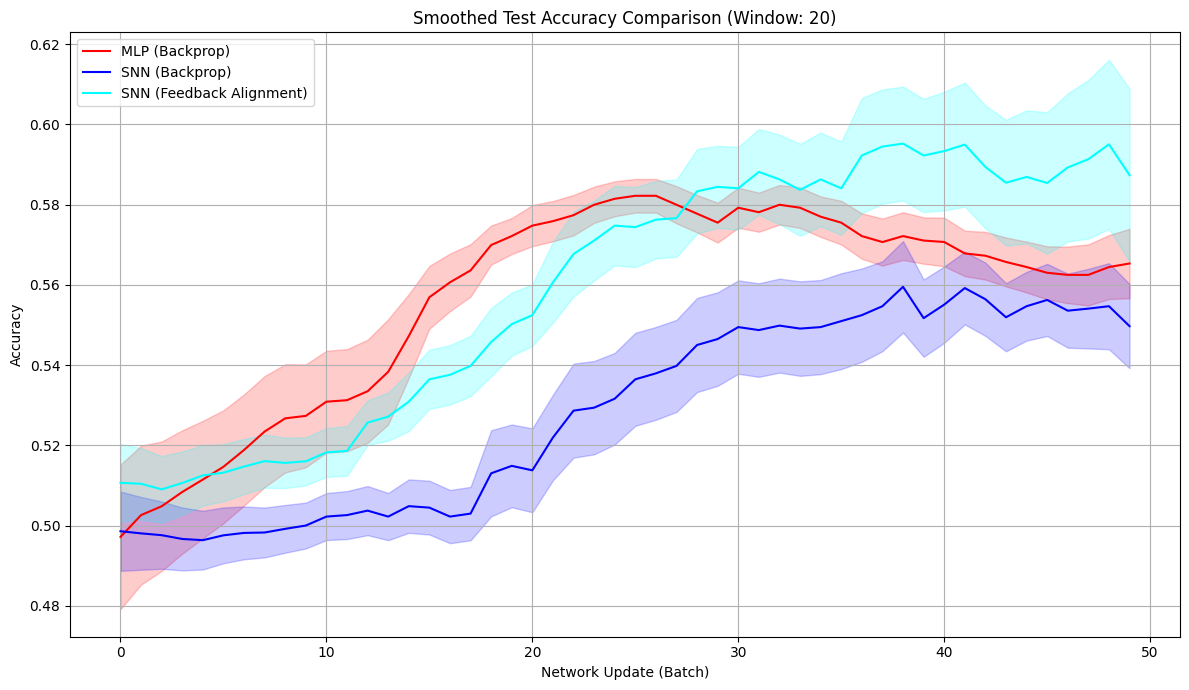

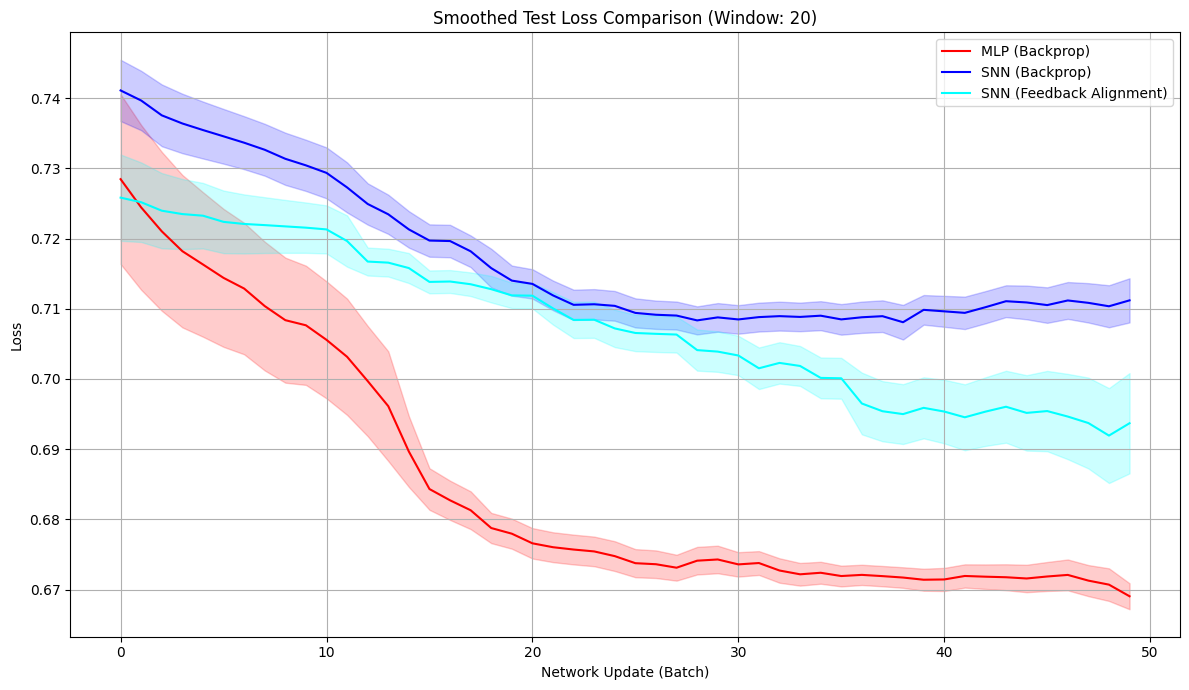

In [ ]:
#@markdown plot results
def smooth_curve_with_sem(data, window_size):
    """
    Computes a moving average and the Standard Error of the Mean (SEM)
    over a sliding window to generate smooth trendlines and shaded confidence regions.
    """
    if window_size <= 1:
        return np.array(data), np.zeros(len(data))
    if len(data) < window_size:
        return np.array([np.mean(data)] * len(data)), np.array([np.std(data)/np.sqrt(len(data))] * len(data))

    smoothed_data = []
    sem_data = []
    for i in range(len(data)):
        start_index = max(0, i - window_size // 2)
        end_index = min(len(data) - 1, i + window_size // 2)
        window = data[start_index:end_index + 1]

        smoothed_data.append(np.mean(window))
        sem_data.append(np.std(window) / np.sqrt(len(window)))

    return np.array(smoothed_data), np.array(sem_data)

SMOOTHING_WINDOW = 20

# Smoothing accuracies and computing SEM
sm_mlp_bp_tacc, sem_mlp_bp_tacc = smooth_curve_with_sem(mlp_bp_tacc, SMOOTHING_WINDOW)
sm_snn_bp_tacc, sem_snn_bp_tacc = smooth_curve_with_sem(snn_bp_tacc, SMOOTHING_WINDOW)
sm_rec_snn_bp_tacc, sem_rec_snn_bp_tacc = smooth_curve_with_sem(rec_snn_bp_tacc, SMOOTHING_WINDOW)


# Plot 1: Smoothed Test Accuracy Comparison Plot with SEM
plt.figure(figsize=(12, 7))
epochs_range = np.arange(len(sm_mlp_bp_tacc))

plt.plot(epochs_range, sm_mlp_bp_tacc, label='MLP (Backprop)', color='red')
plt.fill_between(epochs_range, sm_mlp_bp_tacc - sem_mlp_bp_tacc, sm_mlp_bp_tacc + sem_mlp_bp_tacc, color='red', alpha=0.2)

plt.plot(epochs_range, sm_snn_bp_tacc, label='SNN (Backprop)', color='blue')
plt.fill_between(epochs_range, sm_snn_bp_tacc - sem_snn_bp_tacc, sm_snn_bp_tacc + sem_snn_bp_tacc, color='blue', alpha=0.2)

plt.plot(epochs_range, sm_rec_snn_bp_tacc, label='SNN (Feedback Alignment)', color='cyan')
plt.fill_between(epochs_range, sm_rec_snn_bp_tacc - sem_rec_snn_bp_tacc, sm_rec_snn_bp_tacc + sem_rec_snn_bp_tacc, color='cyan', alpha=0.2)

plt.title(f'Smoothed Test Accuracy Comparison (Window: {SMOOTHING_WINDOW})')
plt.xlabel('Network Update (Batch)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Smoothing losses and computing SEM
sm_mlp_bp_tloss, sem_mlp_bp_tloss = smooth_curve_with_sem(mlp_bp_tloss, SMOOTHING_WINDOW)
sm_snn_bp_tloss, sem_snn_bp_tloss = smooth_curve_with_sem(snn_bp_tloss, SMOOTHING_WINDOW)
sm_rec_snn_bp_tloss, sem_rec_snn_bp_tloss = smooth_curve_with_sem(rec_snn_bp_tloss, SMOOTHING_WINDOW)

# Plot 2: Smoothed Test Loss Comparison Plot with SEM
plt.figure(figsize=(12, 7))

plt.plot(epochs_range, sm_mlp_bp_tloss, label='MLP (Backprop)', color='red')
plt.fill_between(epochs_range, sm_mlp_bp_tloss - sem_mlp_bp_tloss, sm_mlp_bp_tloss + sem_mlp_bp_tloss, color='red', alpha=0.2)

plt.plot(epochs_range, sm_snn_bp_tloss, label='SNN (Backprop)', color='blue')
plt.fill_between(epochs_range, sm_snn_bp_tloss - sem_snn_bp_tloss, sm_snn_bp_tloss + sem_snn_bp_tloss, color='blue', alpha=0.2)

plt.plot(epochs_range, sm_rec_snn_bp_tloss, label='SNN (Feedback Alignment)', color='cyan')
plt.fill_between(epochs_range, sm_rec_snn_bp_tloss - sem_rec_snn_bp_tloss, sm_rec_snn_bp_tloss + sem_rec_snn_bp_tloss, color='cyan', alpha=0.2)

plt.title(f'Smoothed Test Loss Comparison (Window: {SMOOTHING_WINDOW})')
plt.xlabel('Network Update (Batch)')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Number of examples retained:
  3900 (training)
  2100 (validation)
  1000 (test)
Common classes selected for all loaders: [0, 7, 9]
Dataset will be filtered to include *pre-selected* classes: [0, 7, 9]
If you are using models, you might need to update `config.NUM_OUTPUTS` to 3 accordingly.
Dataset will be filtered to include *pre-selected* classes: [0, 7, 9]
If you are using models, you might need to update `config.NUM_OUTPUTS` to 3 accordingly.
Dataset will be filtered to include *pre-selected* classes: [0, 7, 9]
If you are using models, you might need to update `config.NUM_OUTPUTS` to 3 accordingly.
--> Initializing Backprop Models...
Training Recurrent SNN (Backprop)...


/tmp/ipykernel_769/2673732432.py:282: UserWarning: Original DataLoader has a custom `batch_sampler`. For the filtered DataLoader, `batch_size`, `drop_last`, and `shuffle` from the original DataLoader will be used to create a standard internal sampler. The custom `batch_sampler` will not be directly re-used.
  warnings.warn("Original DataLoader has a custom `batch_sampler`. "


Training MLP (Backprop)...
Training SNN (Backprop)....


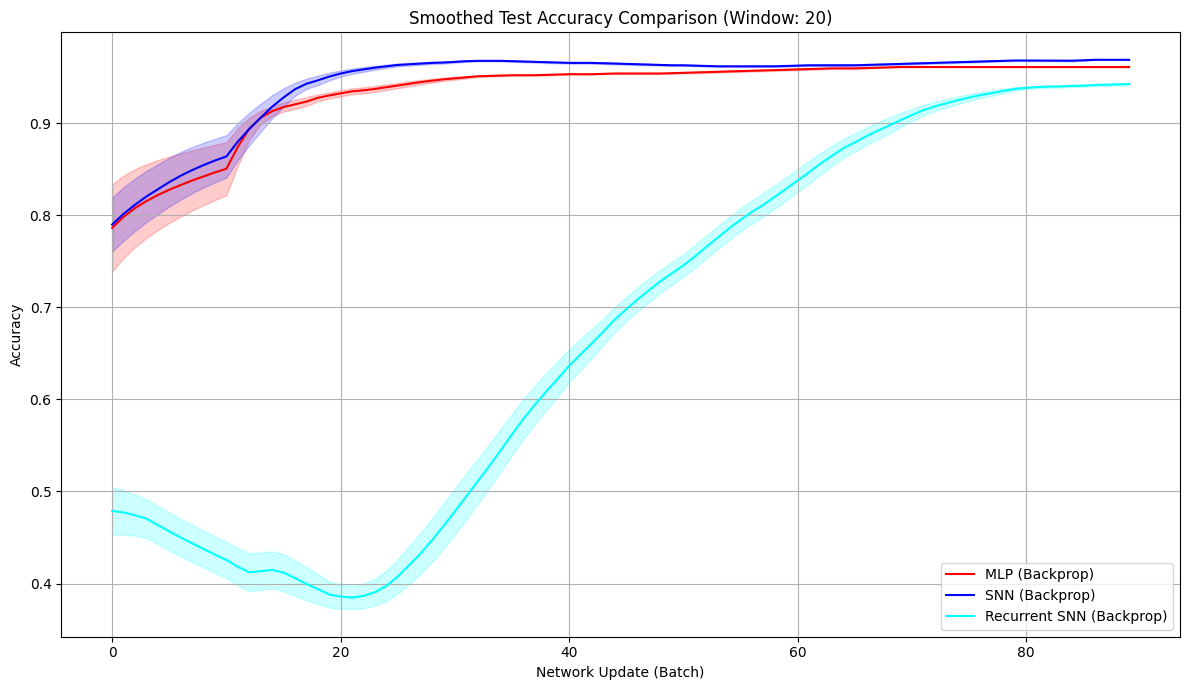

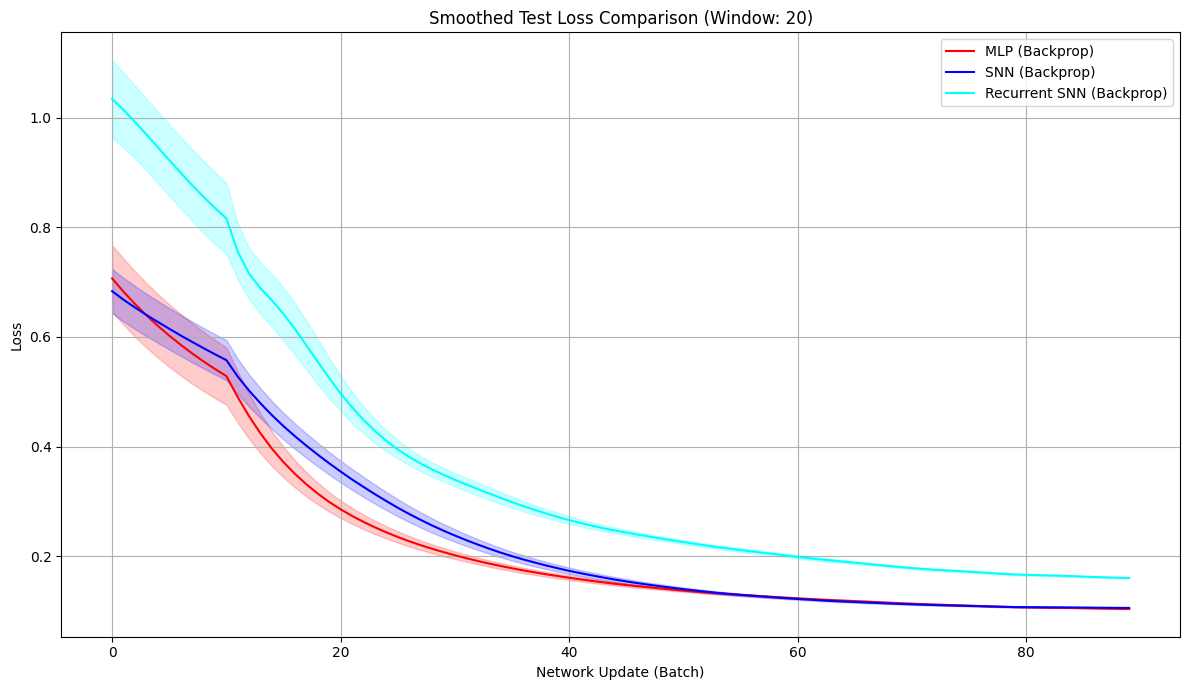

In [ ]:
#@title whole thing in one cell

import os
import io
import math
import random
import contextlib
import numpy as np
import scipy
import warnings
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

# IPython dependencies (if running in a notebook)
try:
    from IPython.display import Image, SVG, display
except ImportError:
    pass

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms

# snntorch dependencies
try:
    import snntorch as snn
    from snntorch import spikeplot as splt
    from snntorch import spikegen
except ImportError:
    print("snnTorch not found. Installing...")
    import subprocess
    subprocess.check_call(["pip", "install", "snntorch", "--quiet"])
    import snntorch as snn
    from snntorch import spikeplot as splt
    from snntorch import spikegen

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

class Config():
    def __init__(self):
        self.BATCH_SIZE = 128
        self.NUM_EPOCHS = 10 # Speed up training
        self.NUM_INPUTS = np.int64(28**2) # 28x28 images
        self.NUM_OUTPUTS = 2 # Will be dynamically set based on num_desired_labels_for_all
        self.NUM_HIDDEN = 100
        self.ACTIVATION = "leaky"
        self.BIAS = True

        self.BETA = 0.8 # Slope for leaky relu on SNN
        self.NUM_SNN_TIMESTEPS = 25

        self.ADAM_BETA = (0.9, 0.999)
        self.LEARNING_RULE = 3e-4
        self.DELAY_MEAN = 0.0 # Add DELAY_MEAN as a hyperparameter
        self.NUM_DESIRED_LABELS = 3 # Add NUM_DESIRED_LABELS as a hyperparameter

config = Config()

def download_mnist(train_prop=0.8, keep_prop=0.5, neuromatch_magic_normalize = 1):
    valid_prop = 1 - train_prop
    discard_prop = 1 - keep_prop

    if neuromatch_magic_normalize:
        norm_func = transforms.Normalize((0.1307,), (0.3081,))
    else:
        norm_func = transforms.Normalize((0,), (1,))

    transform = transforms.Compose([
              transforms.Resize((28, 28)),
              transforms.Grayscale(),
              transforms.ToTensor(),
              norm_func
              ])

    with contextlib.redirect_stdout(io.StringIO()):
        full_train_set = torchvision.datasets.MNIST(
            root="./data/", train=True, download=True, transform=transform,
        )
        full_test_set = torchvision.datasets.MNIST(
            root="./data/", train=False, download=True, transform=transform,
        )

    train_set, valid_set, _ = torch.utils.data.random_split(
        full_train_set,
        [train_prop * keep_prop, valid_prop * keep_prop, discard_prop]
    )
    test_set, _ = torch.utils.data.random_split(
        full_test_set,
        [keep_prop, discard_prop]
    )

    print("Number of examples retained:")
    print(f"  {len(train_set)} (training)")
    print(f"  {len(valid_set)} (validation)")
    print(f"  {len(test_set)} (test)")

    return train_set, valid_set, test_set

train_set, valid_set, test_set = download_mnist(train_prop=0.65,
                                                keep_prop=0.1,
                                                neuromatch_magic_normalize = 1)

BATCH_SIZE = config.BATCH_SIZE
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
valid_loader = torch.utils.data.DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

def apply_probabilistic_delayed_labels(original_labels, num_examples, delay_mean=1.0):
    """
    Applies a probabilistic forward shift to labels with conflict resolution.

    Args:
        original_labels (torch.Tensor): The original labels for the batch.
        num_examples (int): The number of examples in the batch (determines the size
                            of the delayed labels array).
        delay_mean (float): The mean (lambda) for the Poisson distribution to determine
                            the delay amount for each label.

    Returns:
        torch.Tensor: A tensor of the new, probabilistically delayed labels.
                      Labels that are pushed out of bounds or for unassigned slots are -1.
    """
    delayed_labels = torch.full((num_examples,), -1, dtype=torch.long)
    label_delay_info = []

    for i, label in enumerate(original_labels):
        delay_amount = np.random.poisson(delay_mean)
        label_delay_info.append((i, delay_amount, label.item()))

    label_delay_info.sort(key=lambda x: x[0])

    occupied_slots = [False] * num_examples

    for original_idx, delay_amount, label_value in label_delay_info:
        desired_target_idx = original_idx + delay_amount

        current_target_idx = desired_target_idx
        while current_target_idx < num_examples and occupied_slots[current_target_idx]:
            current_target_idx += 1

        if current_target_idx < num_examples:
            delayed_labels[current_target_idx] = label_value
            occupied_slots[current_target_idx] = True

    return delayed_labels

def restrict_classes(dataset, classes=[6], keep=True):
  """
  Removes or keeps specified classes in a dataset.

  Arguments:
  - dataset (torch dataset or subset): Dataset with class targets.
  - classes (list): List of classes to keep or remove.
  - keep (bool): If True, the classes specified are kept. If False, they are
  removed.

  Returns:
  - new_dataset (torch dataset or subset): Datset restricted as specified.
  """

  if hasattr(dataset, "dataset"):
    indices = np.asarray(dataset.indices)
    targets = dataset.dataset.targets[indices]
    dataset = dataset.dataset
  else:
    indices = np.arange(len(dataset))
    targets = dataset.targets

  specified_idxs = np.isin(targets, np.asarray(classes))
  if keep:
    retain_indices = indices[specified_idxs]
  else:
    retain_indices = indices[~specified_idxs]

  new_dataset = torch.utils.data.Subset(dataset, retain_indices)

  return new_dataset

def create_delayed_dataloader(original_dataloader, delay_mean, num_desired_labels=None, classes_to_filter=None):
    """
    Creates a new DataLoader that yields probabilistically delayed labels for each batch.
    Optionally, filters the dataset to include only a specified number of unique classes.

    Args:
        original_dataloader (torch.utils.data.DataLoader): The original DataLoader.
        delay_mean (float): The mean (lambda) for the Poisson distribution to determine
                            the delay amount for each label, used by
                            apply_probabilistic_delayed_labels.
        num_desired_labels (int, optional): If specified and `classes_to_filter` is None,
                                            the dataset will be filtered to include only
                                            this many randomly selected unique classes.
                                            Labels for these classes will be remapped to be 0-indexed.
                                            Defaults to None.
        classes_to_filter (list, optional): A specific list of class labels to filter the
                                            dataset by. If provided, this list overrides the
                                            random sampling based on `num_desired_labels`.
                                            Defaults to None.

    Returns:
        torch.utils.data.DataLoader: A new DataLoader yielding (images, delayed_labels).
    """

    dataset_for_loader = original_dataloader.dataset
    selected_classes_map = None # Initialize to None

    if num_desired_labels is not None or classes_to_filter is not None:
        if classes_to_filter is not None:
            selected_classes = classes_to_filter
            num_actual_output_classes = len(selected_classes)
            print(f"Dataset will be filtered to include *pre-selected* classes: {sorted(selected_classes)}")
        else:
            if isinstance(original_dataloader.dataset, torch.utils.data.Subset):
                base_dataset = original_dataloader.dataset.dataset
                current_subset_indices = original_dataloader.dataset.indices
                if hasattr(base_dataset, 'targets'):
                    all_labels_in_current_scope = [base_dataset.targets[i].item() for i in current_subset_indices]
                elif hasattr(base_dataset, 'labels'):
                    all_labels_in_current_scope = [base_dataset.labels[i].item() for i in current_subset_indices]
                else:
                    raise AttributeError("Underlying base dataset has no 'targets' or 'labels' attribute for filtering.")
            else:
                if hasattr(original_dataloader.dataset, 'targets'):
                    all_labels_in_current_scope = original_dataloader.dataset.targets.tolist()
                elif hasattr(original_dataloader.dataset, 'labels'):
                    all_labels_in_current_scope = original_dataloader.dataset.labels.tolist()
                else:
                    raise AttributeError("Dataset has no 'targets' or 'labels' attribute for filtering.")

            unique_classes_in_scope = torch.unique(torch.tensor(all_labels_in_current_scope)).tolist()

            if num_desired_labels > len(unique_classes_in_scope):
                print(f"Warning: num_desired_labels ({num_desired_labels}) is greater than available unique classes ({len(unique_classes_in_scope)}). Using all available classes.")
                selected_classes = unique_classes_in_scope
                num_actual_output_classes = len(unique_classes_in_scope)
            else:
                selected_classes = random.sample(unique_classes_in_scope, num_desired_labels)
                num_actual_output_classes = num_desired_labels

            print(f"Dataset will be filtered to include only classes: {sorted(selected_classes)}")

        print(f"If you are using models, you might need to update `config.NUM_OUTPUTS` to {num_actual_output_classes} accordingly.")

        selected_classes_map = {original_label: new_label for new_label, original_label in enumerate(sorted(selected_classes))}
        dataset_for_loader = restrict_classes(original_dataloader.dataset, classes=selected_classes, keep=True)


    def custom_collate_fn(batch):
        images = torch.stack([item[0] for item in batch])
        original_labels_raw = [item[1] for item in batch]

        if selected_classes_map:
            original_labels_tensor = torch.tensor([
                selected_classes_map[label.item() if isinstance(label, torch.Tensor) else label]
                for label in original_labels_raw
            ])
        else:
            original_labels_tensor = torch.tensor(original_labels_raw)

        num_examples_in_batch = len(batch)
        delayed_labels = apply_probabilistic_delayed_labels(
            original_labels_tensor, num_examples_in_batch, delay_mean=delay_mean
        )

        return images, delayed_labels

    dataloader_kwargs = {
        'dataset': dataset_for_loader,
        'num_workers': original_dataloader.num_workers,
        'collate_fn': custom_collate_fn,
        'pin_memory': original_dataloader.pin_memory,
        'timeout': original_dataloader.timeout,
        'worker_init_fn': original_dataloader.worker_init_fn
    }

    dataloader_kwargs['batch_size'] = original_dataloader.batch_size
    dataloader_kwargs['drop_last'] = original_dataloader.drop_last
    dataloader_kwargs['shuffle'] = original_dataloader.shuffle if hasattr(original_dataloader, 'shuffle') else False

    if original_dataloader.batch_sampler is not None:
        warnings.warn("Original DataLoader has a custom `batch_sampler`. "
                      "For the filtered DataLoader, `batch_size`, `drop_last`, "
                      "and `shuffle` from the original DataLoader will be used "
                      "to create a standard internal sampler. The custom `batch_sampler` "
                      "will not be directly re-used.")

    return torch.utils.data.DataLoader(**dataloader_kwargs)

class MultiLayerPerceptron(torch.nn.Module):
    def __init__(self, num_inputs=config.NUM_INPUTS, num_hidden=config.NUM_HIDDEN, num_outputs=config.NUM_OUTPUTS, activation_type="leaky", bias=False):
        super().__init__()
        self.num_inputs = num_inputs
        self.num_hidden = num_hidden
        self.num_outputs = num_outputs
        self.bias = bias

        self.lin1 = torch.nn.Linear(num_inputs, num_hidden, bias=bias)
        self.lin2 = torch.nn.Linear(num_hidden, num_outputs, bias=bias)
        self.activation = torch.nn.LeakyReLU(config.BETA)

    def forward(self, X, y=None):
        h = self.activation(self.lin1(X.reshape(-1, self.num_inputs)))
        y_pred = self.lin2(h)
        return y_pred

class SNN_MLP(nn.Module):
    def __init__(self, num_outputs = config.NUM_OUTPUTS):
        super().__init__()
        self.fc1 = nn.Linear(config.NUM_INPUTS, config.NUM_HIDDEN)
        self.lif1 = snn.Leaky(beta=config.BETA)
        self.fc2 = nn.Linear(config.NUM_HIDDEN, num_outputs)
        self.lif2 = snn.Leaky(beta=config.BETA)

    def forward(self, x):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        spk2_rec, mem2_rec = [], []

        for step in range(config.NUM_SNN_TIMESTEPS):
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            spk2_rec.append(spk2)
            mem2_rec.append(mem2)

        return torch.stack(spk2_rec, dim=0), torch.stack(mem2_rec, dim=0)

class SNN_rec(nn.Module):
    def __init__(self, num_outputs = config.NUM_OUTPUTS):
        super().__init__()
        self.fc1 = nn.Linear(config.NUM_INPUTS, config.NUM_HIDDEN)
        self.lif1 = snn.RLeaky(beta=config.BETA, linear_features=config.NUM_HIDDEN,
                                all_to_all=True
                               )
        self.fc2 = nn.Linear(config.NUM_HIDDEN, num_outputs)
        self.lif2 = snn.RLeaky(beta=config.BETA, linear_features=num_outputs,
                                all_to_all=True
                               )

    def forward(self, x):
        spk1,mem1 = self.lif1.init_rleaky()
        spk2,mem2 = self.lif1.init_rleaky()
        spk2_rec, mem2_rec = [], []

        for step in range(config.NUM_SNN_TIMESTEPS):
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, spk1, mem1)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, spk2, mem2)
            spk2_rec.append(spk2)
            mem2_rec.append(mem2)

        return torch.stack(spk2_rec, dim=0), torch.stack(mem2_rec, dim=0)

def train_snn_model(model, optimizer, train_loader, test_loader, num_epochs=config.NUM_EPOCHS):
    """
    Generic training loop for SNNs (works for both standard and Feedback Alignment).
    """
    model.to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=-1)
    loss_hist, test_loss_hist = [], []
    train_acc_hist, test_acc_hist = [], []
    num_steps = config.NUM_SNN_TIMESTEPS

    for epoch in range(num_epochs):
        for iter_counter, (data, targets) in enumerate(train_loader):
            data, targets = data.to(device), targets.to(device)

            # Forward pass
            model.train()
            spk_rec, mem_rec = model(data.view(config.BATCH_SIZE, -1))

            # Loss and updates
            loss_val = torch.zeros((1), dtype=torch.float, device=device)
            for step in range(num_steps):
                loss_val += criterion(mem_rec[step], targets)
            loss_val /= num_steps

            optimizer.zero_grad()
            loss_val.backward()
            optimizer.step()

            # Train Tracking
            loss_hist.append(loss_val.item())
            _, predicted_train_labels = spk_rec.sum(dim=0).max(1)
            train_acc = (predicted_train_labels == targets).float().mean().item()
            train_acc_hist.append(train_acc)

            # Test Tracking
            with torch.no_grad():
                model.eval()
                test_data, test_targets = next(iter(test_loader))
                test_data, test_targets = test_data.to(device), test_targets.to(device)

                test_spk, test_mem = model(test_data.view(config.BATCH_SIZE, -1))
                test_loss = torch.zeros((1), dtype=torch.float, device=device)
                for step in range(num_steps):
                     test_loss += criterion(test_mem[step], test_targets)
                test_loss /= num_steps
                test_loss_hist.append(test_loss.item())

                _, predicted_test_labels = test_spk.sum(dim=0).max(1)
                test_acc = (predicted_test_labels == test_targets).float().mean().item()
                test_acc_hist.append(test_acc)

    return loss_hist, test_loss_hist, train_acc_hist, test_acc_hist


def train_mlp_model(model, optimizer, train_loader, test_loader, num_epochs=config.NUM_EPOCHS):
    """
    Generic training loop for MLPs (works for both standard and Feedback Alignment).
    """
    model.to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=-1)
    loss_hist, test_loss_hist = [], []
    train_acc_hist, test_acc_hist = [], []

    for epoch in range(num_epochs):
        for iter_counter, (data, targets) in enumerate(train_loader):
            data, targets = data.to(device), targets.to(device)

            # Forward pass
            model.train()
            y_pred = model(data.view(config.BATCH_SIZE, -1))

            # Loss and Updates
            loss_val = criterion(y_pred, targets)
            optimizer.zero_grad()
            loss_val.backward()
            optimizer.step()

            # Train Tracking
            loss_hist.append(loss_val.item())
            predicted_train_labels = torch.argmax(y_pred, dim=1)
            train_acc = (predicted_train_labels == targets).float().mean().item()
            train_acc_hist.append(train_acc)

            # Test Tracking
            with torch.no_grad():
                model.eval()
                test_data, test_targets = next(iter(test_loader))
                test_data, test_targets = test_data.to(device), test_targets.to(device)

                test_y_pred = model(test_data.view(config.BATCH_SIZE, -1))
                test_loss = criterion(test_y_pred, test_targets)
                test_loss_hist.append(test_loss.item())

                predicted_test_labels = torch.argmax(test_y_pred, dim=1)
                test_acc = (predicted_test_labels == test_targets).float().mean().item()
                test_acc_hist.append(test_acc)

    return loss_hist, test_loss_hist, train_acc_hist, test_acc_hist

def smooth_curve_with_sem(data, window_size):
    """
    Computes a moving average and the Standard Error of the Mean (SEM)
    over a sliding window to generate smooth trendlines and shaded confidence regions.
    """
    if window_size <= 1:
        return np.array(data), np.zeros(len(data))
    if len(data) < window_size:
        return np.array([np.mean(data)] * len(data)), np.array([np.std(data)/np.sqrt(len(data))] * len(data))

    smoothed_data = []
    sem_data = []
    for i in range(len(data)):
        start_index = max(0, i - window_size // 2)
        end_index = min(len(data) - 1, i + window_size // 2)
        window = data[start_index:end_index + 1]

        smoothed_data.append(np.mean(window))
        sem_data.append(np.std(window) / np.sqrt(len(window)))

    return np.array(smoothed_data), np.array(sem_data)

# --- Training Execution ---

# Use DELAY_MEAN from config
delay_mean_param_2 = config.DELAY_MEAN # Adjust this value for different average delays
num_desired_labels_for_all = config.NUM_DESIRED_LABELS # Define the number of desired labels centrally

# --- Determine common selected classes from the train_loader's dataset ---
if isinstance(train_loader.dataset, torch.utils.data.Subset):
    base_train_dataset = train_loader.dataset.dataset
    if hasattr(base_train_dataset, 'targets'):
        all_labels_from_train_scope = [base_train_dataset.targets[i].item() for i in train_loader.dataset.indices]
    elif hasattr(base_train_dataset, 'labels'):
        all_labels_from_train_scope = [base_train_dataset.labels[i].item() for i in train_loader.dataset.indices]
    else:
        raise AttributeError("Train dataset has no 'targets' or 'labels' attribute for filtering.")
else:
    if hasattr(train_loader.dataset, 'targets'):
        all_labels_from_train_scope = train_loader.dataset.targets.tolist()
    elif hasattr(train_loader.dataset, 'labels'):
        all_labels_from_train_scope = train_loader.dataset.labels.tolist()
    else:
        raise AttributeError("Train dataset has no 'targets' or 'labels' attribute for filtering.")

unique_classes_from_train_set = torch.unique(torch.tensor(all_labels_from_train_scope)).tolist()

if num_desired_labels_for_all > len(unique_classes_from_train_set):
    common_selected_classes = unique_classes_from_train_set
    print(f"Warning: num_desired_labels ({num_desired_labels_for_all}) is greater than available unique classes in train set ({len(unique_classes_from_train_set)}). Using all available classes.")
else:
    common_selected_classes = random.sample(unique_classes_from_train_set, num_desired_labels_for_all)

print(f"Common classes selected for all loaders: {sorted(common_selected_classes)}")

# Dynamically set config.NUM_OUTPUTS based on the number of selected classes
config.NUM_OUTPUTS = len(common_selected_classes)
# Re-instantiate config here to ensure models use the updated NUM_OUTPUTS
config = Config()

# --- Create delayed dataloaders using the common selected classes ---
delayed_train_loader_2 = create_delayed_dataloader(
    train_loader, delay_mean=delay_mean_param_2, classes_to_filter=common_selected_classes
)
delayed_val_loader_2 = create_delayed_dataloader(
    valid_loader, delay_mean=delay_mean_param_2, classes_to_filter=common_selected_classes
)
delayed_test_loader_2 = create_delayed_dataloader(
    test_loader, delay_mean=delay_mean_param_2, classes_to_filter=common_selected_classes
)

# --- Instantiate models and optimizers ---
print("--> Initializing Backprop Models...")

mlp_bp = MultiLayerPerceptron(num_hidden=config.NUM_HIDDEN, bias=config.BIAS, num_outputs=config.NUM_DESIRED_LABELS).to(device)

snn_bp = SNN_MLP(num_outputs=config.NUM_DESIRED_LABELS).to(device)

rec_snn_bp = SNN_rec(num_outputs=config.NUM_DESIRED_LABELS).to(device)

mlp_bp_optimizer = torch.optim.Adam(mlp_bp.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)
snn_bp_optimizer = torch.optim.Adam(snn_bp.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)
rec_snn_bp_optimizer = torch.optim.Adam(rec_snn_bp.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)

# --- Train Models ---
print("Training Recurrent SNN (Backprop)...")
rec_snn_bp_loss, rec_snn_bp_tloss, rec_snn_bp_acc, rec_snn_bp_tacc = train_snn_model(
    rec_snn_bp, rec_snn_bp_optimizer, delayed_train_loader_2, delayed_test_loader_2
)

print("Training MLP (Backprop)...")
mlp_bp_loss, mlp_bp_tloss, mlp_bp_acc, mlp_bp_tacc = train_mlp_model(
    mlp_bp, mlp_bp_optimizer, delayed_train_loader_2, delayed_test_loader_2
)

print("Training SNN (Backprop)....")
snn_bp_loss, snn_bp_tloss, snn_bp_acc, snn_bp_tacc = train_snn_model(
    snn_bp, snn_bp_optimizer, delayed_train_loader_2, delayed_test_loader_2
)


# --- Plot Results ---
SMOOTHING_WINDOW = 20

# Smoothing accuracies and computing SEM
sm_mlp_bp_tacc, sem_mlp_bp_tacc = smooth_curve_with_sem(mlp_bp_tacc, SMOOTHING_WINDOW)
sm_snn_bp_tacc, sem_snn_bp_tacc = smooth_curve_with_sem(snn_bp_tacc, SMOOTHING_WINDOW)
sm_rec_snn_bp_tacc, sem_rec_snn_bp_tacc = smooth_curve_with_sem(rec_snn_bp_tacc, SMOOTHING_WINDOW)

# Plot 1: Smoothed Test Accuracy Comparison Plot with SEM
plt.figure(figsize=(12, 7))
epochs_range = np.arange(len(sm_mlp_bp_tacc))

plt.plot(epochs_range, sm_mlp_bp_tacc, label='MLP (Backprop)', color='red')
plt.fill_between(epochs_range, sm_mlp_bp_tacc - sem_mlp_bp_tacc, sm_mlp_bp_tacc + sem_mlp_bp_tacc, color='red', alpha=0.2)

plt.plot(epochs_range, sm_snn_bp_tacc, label='SNN (Backprop)', color='blue')
plt.fill_between(epochs_range, sm_snn_bp_tacc - sem_snn_bp_tacc, sm_snn_bp_tacc + sem_snn_bp_tacc, color='blue', alpha=0.2)

plt.plot(epochs_range, sm_rec_snn_bp_tacc, label='Recurrent SNN (Backprop)', color='cyan')
plt.fill_between(epochs_range, sm_rec_snn_bp_tacc - sem_rec_snn_bp_tacc, sm_rec_snn_bp_tacc + sem_rec_snn_bp_tacc, color='cyan', alpha=0.2)

plt.title(f'Smoothed Test Accuracy Comparison (Window: {SMOOTHING_WINDOW})')
plt.xlabel('Network Update (Batch)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Smoothing losses and computing SEM
sm_mlp_bp_tloss, sem_mlp_bp_tloss = smooth_curve_with_sem(mlp_bp_tloss, SMOOTHING_WINDOW)
sm_snn_bp_tloss, sem_snn_bp_tloss = smooth_curve_with_sem(snn_bp_tloss, SMOOTHING_WINDOW)
sm_rec_snn_bp_tloss, sem_rec_snn_bp_tloss = smooth_curve_with_sem(rec_snn_bp_tloss, SMOOTHING_WINDOW)

# Plot 2: Smoothed Test Loss Comparison Plot with SEM
plt.figure(figsize=(12, 7))

plt.plot(epochs_range, sm_mlp_bp_tloss, label='MLP (Backprop)', color='red')
plt.fill_between(epochs_range, sm_mlp_bp_tloss - sem_mlp_bp_tloss, sm_mlp_bp_tloss + sem_mlp_bp_tloss, color='red', alpha=0.2)

plt.plot(epochs_range, sm_snn_bp_tloss, label='SNN (Backprop)', color='blue')
plt.fill_between(epochs_range, sm_snn_bp_tloss - sem_snn_bp_tloss, sm_snn_bp_tloss + sem_snn_bp_tloss, color='blue', alpha=0.2)

plt.plot(epochs_range, sm_rec_snn_bp_tloss, label='Recurrent SNN (Backprop)', color='cyan')
plt.fill_between(epochs_range, sm_rec_snn_bp_tloss - sem_rec_snn_bp_tloss, sm_rec_snn_bp_tloss + sem_rec_snn_bp_tloss, color='cyan', alpha=0.2)

plt.title(f'Smoothed Test Loss Comparison (Window: {SMOOTHING_WINDOW})')
plt.xlabel('Network Update (Batch)')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Number of examples retained:
  21000 (training)
  9000 (validation)
  5000 (test)
Common classes selected for all loaders: [4, 6, 8]

--- Training with DELAY_MEAN: 0.0 ---
Dataset will be filtered to include *pre-selected* classes: [4, 6, 8]
If you are using models, you might need to update `config.NUM_OUTPUTS` to 3 accordingly.
Dataset will be filtered to include *pre-selected* classes: [4, 6, 8]
If you are using models, you might need to update `config.NUM_OUTPUTS` to 3 accordingly.
Training MLP (Backprop) for DELAY_MEAN=0.0...


/tmp/ipykernel_769/1147606135.py:286: UserWarning: Original DataLoader has a custom `batch_sampler`. For the filtered DataLoader, `batch_size`, `drop_last`, and `shuffle` from the original DataLoader will be used to create a standard internal sampler. The custom `batch_sampler` will not be directly re-used.
  warnings.warn("Original DataLoader has a custom `batch_sampler`. "


Training SNN (Backprop) for DELAY_MEAN=0.0...
Training Recurrent SNN (Backprop) for DELAY_MEAN=0.0...

--- Training with DELAY_MEAN: 0.001 ---
Dataset will be filtered to include *pre-selected* classes: [4, 6, 8]
If you are using models, you might need to update `config.NUM_OUTPUTS` to 3 accordingly.
Dataset will be filtered to include *pre-selected* classes: [4, 6, 8]
If you are using models, you might need to update `config.NUM_OUTPUTS` to 3 accordingly.
Training MLP (Backprop) for DELAY_MEAN=0.001...
Training SNN (Backprop) for DELAY_MEAN=0.001...
Training Recurrent SNN (Backprop) for DELAY_MEAN=0.001...

--- Training with DELAY_MEAN: 0.005 ---
Dataset will be filtered to include *pre-selected* classes: [4, 6, 8]
If you are using models, you might need to update `config.NUM_OUTPUTS` to 3 accordingly.
Dataset will be filtered to include *pre-selected* classes: [4, 6, 8]
If you are using models, you might need to update `config.NUM_OUTPUTS` to 3 accordingly.
Training MLP (Backprop) fo

/tmp/ipykernel_769/1147606135.py:582: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', len(delay_mean_param_values))


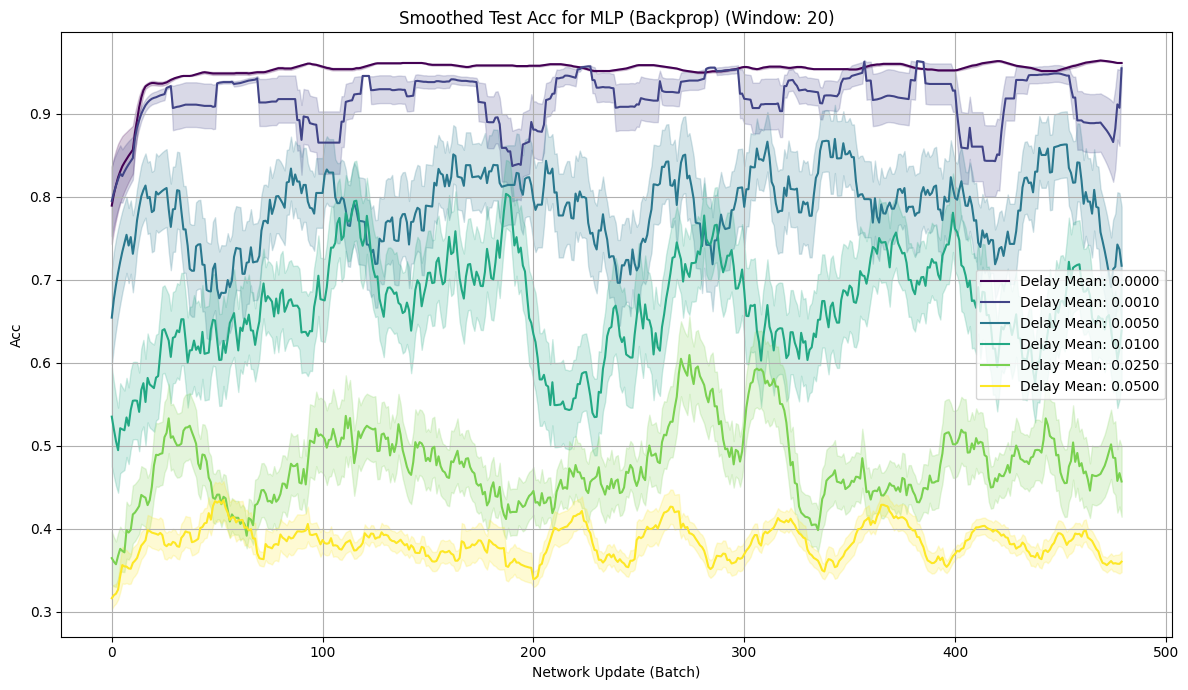

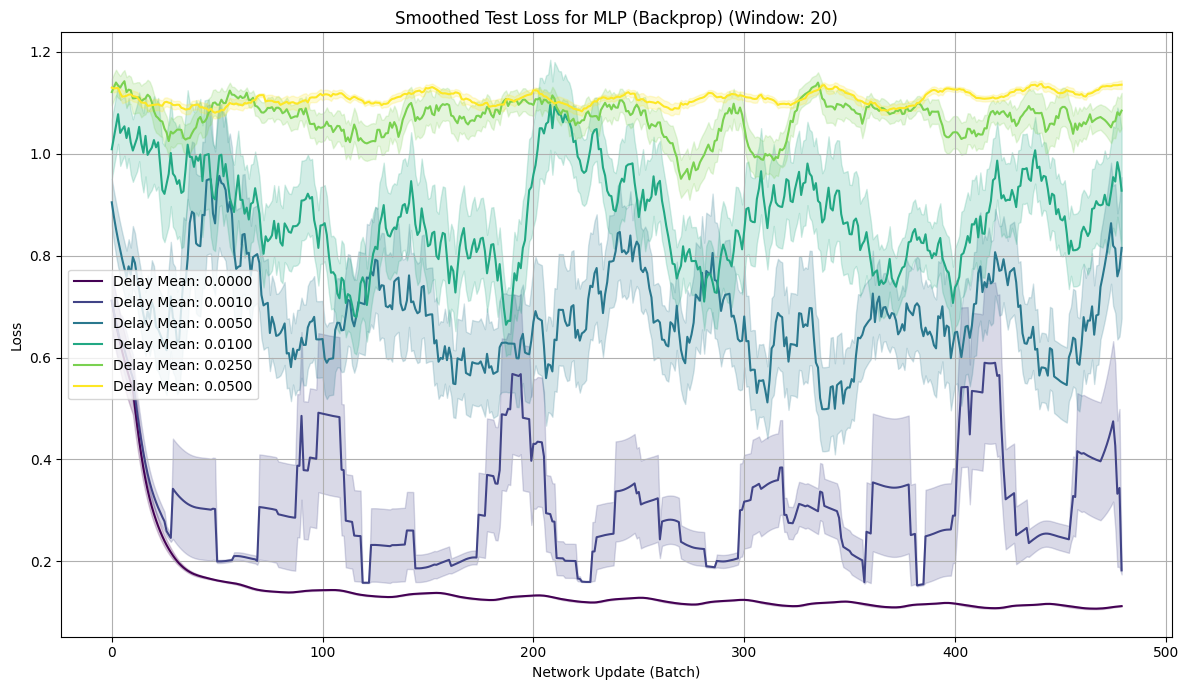

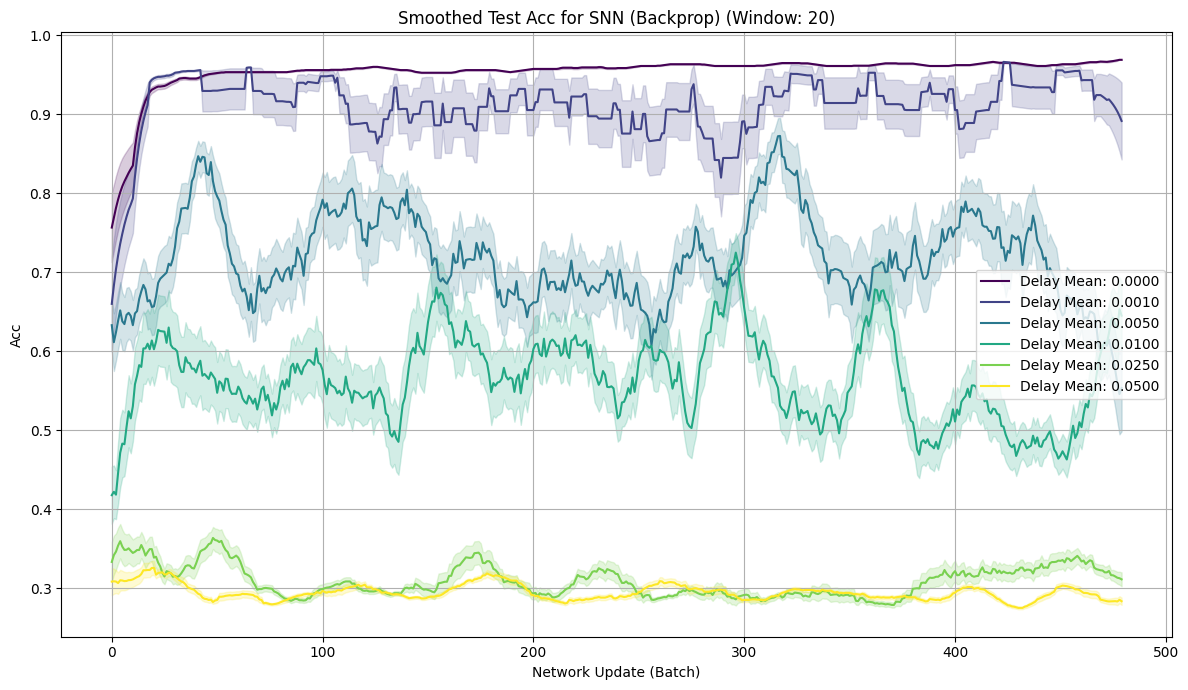

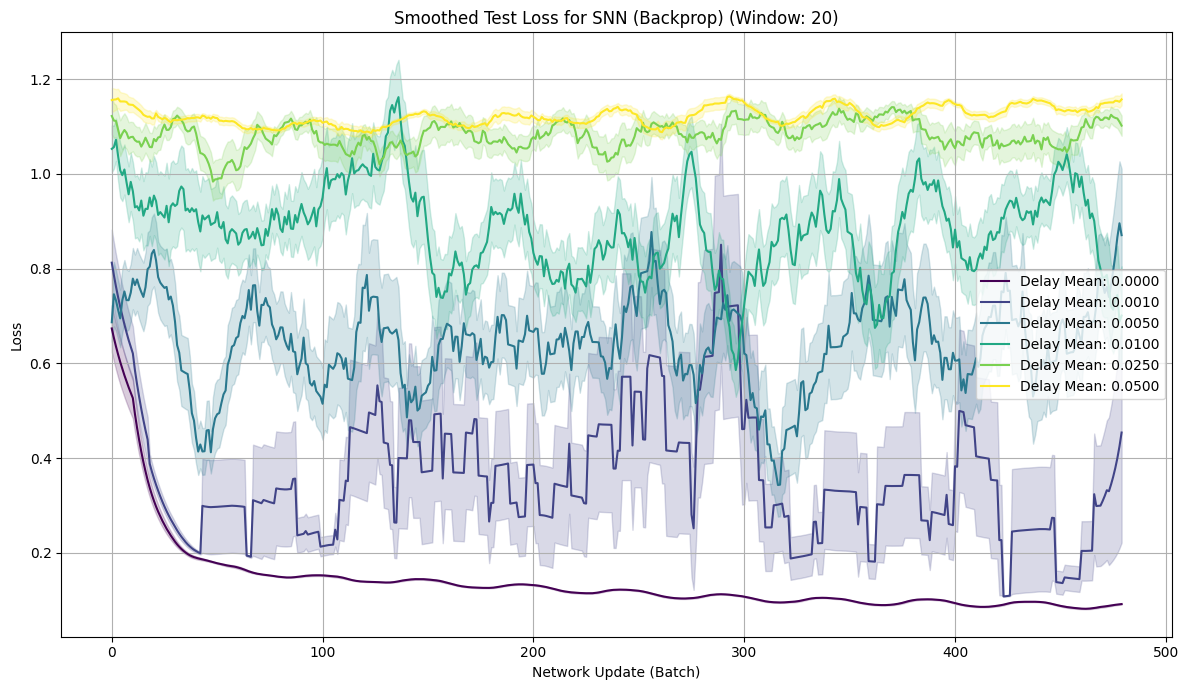

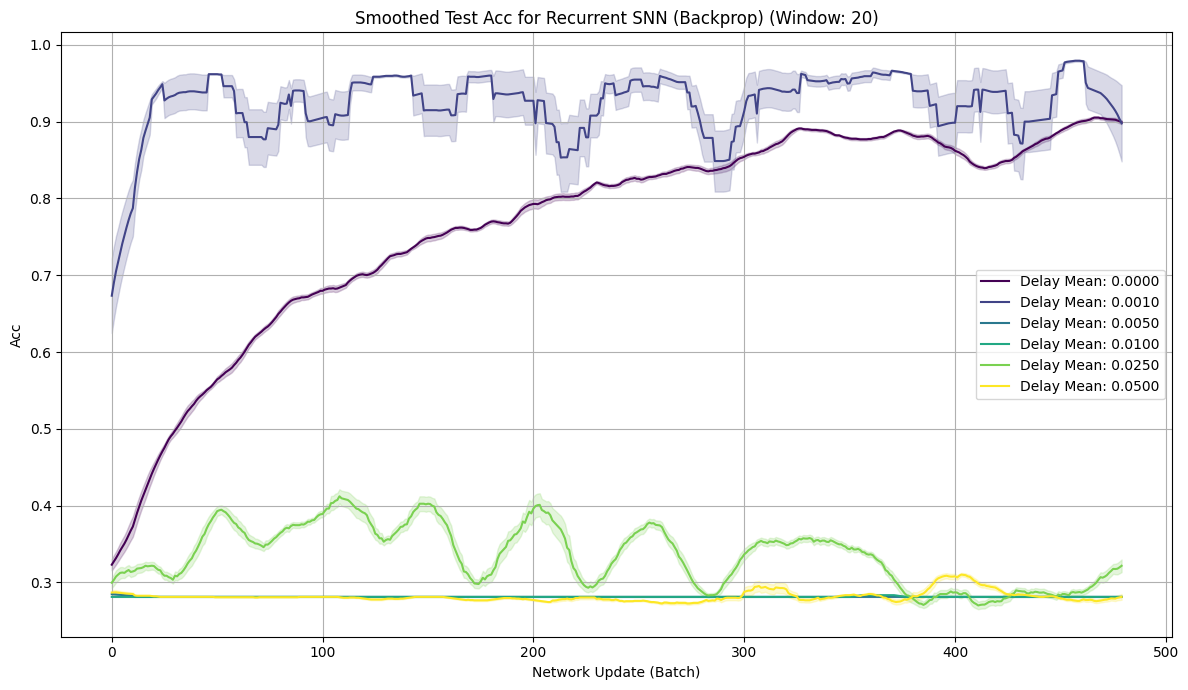

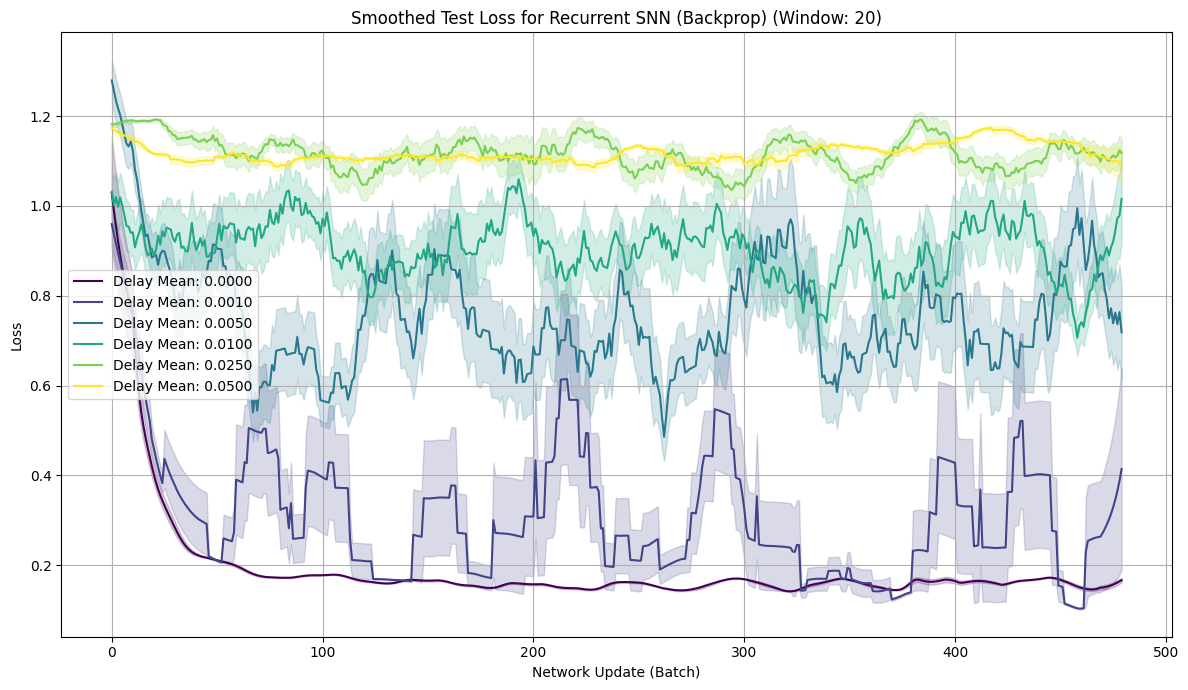

In [ ]:
#@title Same thing, but on a loop of Delay Probs
import os
import io
import math
import random
import contextlib
import numpy as np
import scipy
import warnings
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

# IPython dependencies (if running in a notebook)
try:
    from IPython.display import Image, SVG, display
except ImportError:
    pass

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms

# snntorch dependencies
try:
    import snntorch as snn
    from snntorch import spikeplot as splt
    from snntorch import spikegen
except ImportError:
    print("snnTorch not found. Installing...")
    import subprocess
    subprocess.check_call(["pip", "install", "snntorch", "--quiet"])
    import snntorch as snn
    from snntorch import spikeplot as splt
    from snntorch import spikegen

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

class Config():
    def __init__(self):
        self.BATCH_SIZE = 128
        self.NUM_EPOCHS = 10 # Speed up training
        self.NUM_INPUTS = np.int64(28**2) # 28x28 images
        self.NUM_OUTPUTS = 2 # Will be dynamically set based on num_desired_labels_for_all
        self.NUM_HIDDEN = 100
        self.ACTIVATION = "leaky"
        self.BIAS = True

        self.BETA = 0.8 # Slope for leaky relu on SNN
        self.NUM_SNN_TIMESTEPS = 25

        self.ADAM_BETA = (0.9, 0.999)
        self.LEARNING_RULE = 3e-4
        self.DELAY_MEAN = 0.0 # Add DELAY_MEAN as a hyperparameter
        self.NUM_DESIRED_LABELS = 3 # Add NUM_DESIRED_LABELS as a hyperparameter

        self.TRAIN_PROPORTION = 0.7
        self.KEEP_PROPORTION = 0.5

config = Config()

def download_mnist(train_prop=0.8, keep_prop=0.5, neuromatch_magic_normalize = 1):
    valid_prop = 1 - train_prop
    discard_prop = 1 - keep_prop

    if neuromatch_magic_normalize:
        norm_func = transforms.Normalize((0.1307,), (0.3081,))
    else:
        norm_func = transforms.Normalize((0,), (1,))

    transform = transforms.Compose([
              transforms.Resize((28, 28)),
              transforms.Grayscale(),
              transforms.ToTensor(),
              norm_func
              ])

    with contextlib.redirect_stdout(io.StringIO()):
        full_train_set = torchvision.datasets.MNIST(
            root="./data/", train=True, download=True, transform=transform,
        )
        full_test_set = torchvision.datasets.MNIST(
            root="./data/", train=False, download=True, transform=transform,
        )

    train_set, valid_set, _ = torch.utils.data.random_split(
        full_train_set,
        [train_prop * keep_prop, valid_prop * keep_prop, discard_prop]
    )
    test_set, _ = torch.utils.data.random_split(
        full_test_set,
        [keep_prop, discard_prop]
    )

    print("Number of examples retained:")
    print(f"  {len(train_set)} (training)")
    print(f"  {len(valid_set)} (validation)")
    print(f"  {len(test_set)} (test)")

    return train_set, valid_set, test_set

train_set, valid_set, test_set = download_mnist(train_prop=config.TRAIN_PROPORTION,
                                                keep_prop=config.KEEP_PROPORTION,
                                                neuromatch_magic_normalize = 1)

BATCH_SIZE = config.BATCH_SIZE
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
valid_loader = torch.utils.data.DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

def apply_probabilistic_delayed_labels(original_labels, num_examples, delay_mean=1.0):
    """
    Applies a probabilistic forward shift to labels with conflict resolution.

    Args:
        original_labels (torch.Tensor): The original labels for the batch.
        num_examples (int): The number of examples in the batch (determines the size
                            of the delayed labels array).
        delay_mean (float): The mean (lambda) for the Poisson distribution to determine
                            the delay amount for each label.

    Returns:
        torch.Tensor: A tensor of the new, probabilistically delayed labels.
                      Labels that are pushed out of bounds or for unassigned slots are -1.
    """
    delayed_labels = torch.full((num_examples,), -1, dtype=torch.long)
    label_delay_info = []

    for i, label in enumerate(original_labels):
        delay_amount = np.random.poisson(delay_mean)
        label_delay_info.append((i, delay_amount, label.item()))

    label_delay_info.sort(key=lambda x: x[0])

    occupied_slots = [False] * num_examples

    for original_idx, delay_amount, label_value in label_delay_info:
        desired_target_idx = original_idx + delay_amount

        current_target_idx = desired_target_idx
        while current_target_idx < num_examples and occupied_slots[current_target_idx]:
            current_target_idx += 1

        if current_target_idx < num_examples:
            delayed_labels[current_target_idx] = label_value
            occupied_slots[current_target_idx] = True

    return delayed_labels

def restrict_classes(dataset, classes=[6], keep=True):
  """
  Removes or keeps specified classes in a dataset.

  Arguments:
  - dataset (torch dataset or subset): Dataset with class targets.
  - classes (list): List of classes to keep or remove.
  - keep (bool): If True, the classes specified are kept. If False, they are
  removed.

  Returns:
  - new_dataset (torch dataset or subset): Datset restricted as specified.
  """

  if hasattr(dataset, "dataset"):
    indices = np.asarray(dataset.indices)
    targets = dataset.dataset.targets[indices]
    dataset = dataset.dataset
  else:
    indices = np.arange(len(dataset))
    targets = dataset.targets

  specified_idxs = np.isin(targets, np.asarray(classes))
  if keep:
    retain_indices = indices[specified_idxs]
  else:
    retain_indices = indices[~specified_idxs]

  new_dataset = torch.utils.data.Subset(dataset, retain_indices)

  return new_dataset

def create_delayed_dataloader(original_dataloader, delay_mean, num_desired_labels=None, classes_to_filter=None):
    """
    Creates a new DataLoader that yields probabilistically delayed labels for each batch.
    Optionally, filters the dataset to include only a specified number of unique classes.

    Args:
        original_dataloader (torch.utils.data.DataLoader): The original DataLoader.
        delay_mean (float): The mean (lambda) for the Poisson distribution to determine
                            the delay amount for each label, used by
                            apply_probabilistic_delayed_labels.
        num_desired_labels (int, optional): If specified and `classes_to_filter` is None,
                                            the dataset will be filtered to include only
                                            this many randomly selected unique classes.
                                            Labels for these classes will be remapped to be 0-indexed.
                                            Defaults to None.
        classes_to_filter (list, optional): A specific list of class labels to filter the
                                            dataset by. If provided, this list overrides the
                                            random sampling based on `num_desired_labels`.
                                            Defaults to None.

    Returns:
        torch.utils.data.DataLoader: A new DataLoader yielding (images, delayed_labels).
    """

    dataset_for_loader = original_dataloader.dataset
    selected_classes_map = None # Initialize to None

    if num_desired_labels is not None or classes_to_filter is not None:
        if classes_to_filter is not None:
            selected_classes = classes_to_filter
            num_actual_output_classes = len(selected_classes)
            print(f"Dataset will be filtered to include *pre-selected* classes: {sorted(selected_classes)}")
        else:
            if isinstance(original_dataloader.dataset, torch.utils.data.Subset):
                base_dataset = original_dataloader.dataset.dataset
                current_subset_indices = original_dataloader.dataset.indices
                if hasattr(base_dataset, 'targets'):
                    all_labels_in_current_scope = [base_dataset.targets[i].item() for i in current_subset_indices]
                elif hasattr(base_dataset, 'labels'):
                    all_labels_in_current_scope = [base_dataset.labels[i].item() for i in current_subset_indices]
                else:
                    raise AttributeError("Underlying base dataset has no 'targets' or 'labels' attribute for filtering.")
            else:
                if hasattr(original_dataloader.dataset, 'targets'):
                    all_labels_in_current_scope = original_dataloader.dataset.targets.tolist()
                elif hasattr(original_dataloader.dataset, 'labels'):
                    all_labels_in_current_scope = original_dataloader.dataset.labels.tolist()
                else:
                    raise AttributeError("Dataset has no 'targets' or 'labels' attribute for filtering.")

            unique_classes_in_scope = torch.unique(torch.tensor(all_labels_in_current_scope)).tolist()

            if num_desired_labels > len(unique_classes_in_scope):
                print(f"Warning: num_desired_labels ({num_desired_labels}) is greater than available unique classes ({len(unique_classes_in_scope)}). Using all available classes.")
                selected_classes = unique_classes_in_scope
                num_actual_output_classes = len(unique_classes_in_scope)
            else:
                selected_classes = random.sample(unique_classes_in_scope, num_desired_labels)
                num_actual_output_classes = num_desired_labels

            print(f"Dataset will be filtered to include only classes: {sorted(selected_classes)}")

        print(f"If you are using models, you might need to update `config.NUM_OUTPUTS` to {num_actual_output_classes} accordingly.")

        selected_classes_map = {original_label: new_label for new_label, original_label in enumerate(sorted(selected_classes))}
        dataset_for_loader = restrict_classes(original_dataloader.dataset, classes=selected_classes, keep=True)


    def custom_collate_fn(batch):
        images = torch.stack([item[0] for item in batch])
        original_labels_raw = [item[1] for item in batch]

        if selected_classes_map:
            original_labels_tensor = torch.tensor([
                selected_classes_map[label.item() if isinstance(label, torch.Tensor) else label]
                for label in original_labels_raw
            ])
        else:
            original_labels_tensor = torch.tensor(original_labels_raw)

        num_examples_in_batch = len(batch)
        delayed_labels = apply_probabilistic_delayed_labels(
            original_labels_tensor, num_examples_in_batch, delay_mean=delay_mean
        )

        return images, delayed_labels

    dataloader_kwargs = {
        'dataset': dataset_for_loader,
        'num_workers': original_dataloader.num_workers,
        'collate_fn': custom_collate_fn,
        'pin_memory': original_dataloader.pin_memory,
        'timeout': original_dataloader.timeout,
        'worker_init_fn': original_dataloader.worker_init_fn
    }

    dataloader_kwargs['batch_size'] = original_dataloader.batch_size
    dataloader_kwargs['drop_last'] = original_dataloader.drop_last
    dataloader_kwargs['shuffle'] = original_dataloader.shuffle if hasattr(original_dataloader, 'shuffle') else False

    if original_dataloader.batch_sampler is not None:
        warnings.warn("Original DataLoader has a custom `batch_sampler`. "
                      "For the filtered DataLoader, `batch_size`, `drop_last`, "
                      "and `shuffle` from the original DataLoader will be used "
                      "to create a standard internal sampler. The custom `batch_sampler` "
                      "will not be directly re-used.")

    return torch.utils.data.DataLoader(**dataloader_kwargs)

class MultiLayerPerceptron(torch.nn.Module):
    def __init__(self, num_inputs=config.NUM_INPUTS, num_hidden=config.NUM_HIDDEN, num_outputs=config.NUM_OUTPUTS, activation_type="leaky", bias=False):
        super().__init__()
        self.num_inputs = num_inputs
        self.num_hidden = num_hidden
        self.num_outputs = num_outputs
        self.bias = bias

        self.lin1 = torch.nn.Linear(num_inputs, num_hidden, bias=bias)
        self.lin2 = torch.nn.Linear(num_hidden, num_outputs, bias=bias)
        self.activation = torch.nn.LeakyReLU(config.BETA)

    def forward(self, X, y=None):
        h = self.activation(self.lin1(X.reshape(-1, self.num_inputs)))
        y_pred = self.lin2(h)
        return y_pred

class SNN_MLP(nn.Module):
    def __init__(self, num_outputs = config.NUM_OUTPUTS):
        super().__init__()
        self.fc1 = nn.Linear(config.NUM_INPUTS, config.NUM_HIDDEN)
        self.lif1 = snn.Leaky(beta=config.BETA)
        self.fc2 = nn.Linear(config.NUM_HIDDEN, num_outputs)
        self.lif2 = snn.Leaky(beta=config.BETA)

    def forward(self, x):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        spk2_rec, mem2_rec = [], []

        for step in range(config.NUM_SNN_TIMESTEPS):
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            spk2_rec.append(spk2)
            mem2_rec.append(mem2)

        return torch.stack(spk2_rec, dim=0), torch.stack(mem2_rec, dim=0)

class SNN_rec(nn.Module):
    def __init__(self, num_outputs = config.NUM_OUTPUTS):
        super().__init__()
        self.fc1 = nn.Linear(config.NUM_INPUTS, config.NUM_HIDDEN)
        self.lif1 = snn.RLeaky(beta=config.BETA, linear_features=config.NUM_HIDDEN,
                                all_to_all=True
                               )
        self.fc2 = nn.Linear(config.NUM_HIDDEN, num_outputs)
        self.lif2 = snn.RLeaky(beta=config.BETA, linear_features=num_outputs,
                                all_to_all=True
                               )

    def forward(self, x):
        spk1,mem1 = self.lif1.init_rleaky()
        spk2,mem2 = self.lif1.init_rleaky()
        spk2_rec, mem2_rec = [], []

        for step in range(config.NUM_SNN_TIMESTEPS):
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, spk1, mem1)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, spk2, mem2)
            spk2_rec.append(spk2)
            mem2_rec.append(mem2)

        return torch.stack(spk2_rec, dim=0), torch.stack(mem2_rec, dim=0)

def train_snn_model(model, optimizer, train_loader, test_loader, num_epochs=config.NUM_EPOCHS):
    """
    Generic training loop for SNNs (works for both standard and Feedback Alignment).
    """
    model.to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=-1)
    loss_hist, test_loss_hist = [], []
    train_acc_hist, test_acc_hist = [], []
    num_steps = config.NUM_SNN_TIMESTEPS

    for epoch in range(num_epochs):
        for iter_counter, (data, targets) in enumerate(train_loader):
            data, targets = data.to(device), targets.to(device)

            # Forward pass
            model.train()
            spk_rec, mem_rec = model(data.view(config.BATCH_SIZE, -1))

            # Loss and updates
            loss_val = torch.zeros((1), dtype=torch.float, device=device)
            for step in range(num_steps):
                loss_val += criterion(mem_rec[step], targets)
            loss_val /= num_steps

            optimizer.zero_grad()
            loss_val.backward()
            optimizer.step()

            # Train Tracking
            loss_hist.append(loss_val.item())
            _, predicted_train_labels = spk_rec.sum(dim=0).max(1)
            train_acc = (predicted_train_labels == targets).float().mean().item()
            train_acc_hist.append(train_acc)

            # Test Tracking
            with torch.no_grad():
                model.eval()
                test_data, test_targets = next(iter(test_loader))
                test_data, test_targets = test_data.to(device), test_targets.to(device)

                test_spk, test_mem = model(test_data.view(config.BATCH_SIZE, -1))
                test_loss = torch.zeros((1), dtype=torch.float, device=device)
                for step in range(num_steps):
                     test_loss += criterion(test_mem[step], test_targets)
                test_loss /= num_steps
                test_loss_hist.append(test_loss.item())

                _, predicted_test_labels = test_spk.sum(dim=0).max(1)
                test_acc = (predicted_test_labels == test_targets).float().mean().item()
                test_acc_hist.append(test_acc)

    return loss_hist, test_loss_hist, train_acc_hist, test_acc_hist


def train_mlp_model(model, optimizer, train_loader, test_loader, num_epochs=config.NUM_EPOCHS):
    """
    Generic training loop for MLPs (works for both standard and Feedback Alignment).
    """
    model.to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=-1)
    loss_hist, test_loss_hist = [], []
    train_acc_hist, test_acc_hist = [], []

    for epoch in range(num_epochs):
        for iter_counter, (data, targets) in enumerate(train_loader):
            data, targets = data.to(device), targets.to(device)

            # Forward pass
            model.train()
            y_pred = model(data.view(config.BATCH_SIZE, -1))

            # Loss and Updates
            loss_val = criterion(y_pred, targets)
            optimizer.zero_grad()
            loss_val.backward()
            optimizer.step()

            # Train Tracking
            loss_hist.append(loss_val.item())
            predicted_train_labels = torch.argmax(y_pred, dim=1)
            train_acc = (predicted_train_labels == targets).float().mean().item()
            train_acc_hist.append(train_acc)

            # Test Tracking
            with torch.no_grad():
                model.eval()
                test_data, test_targets = next(iter(test_loader))
                test_data, test_targets = test_data.to(device), test_targets.to(device)

                test_y_pred = model(test_data.view(config.BATCH_SIZE, -1))
                test_loss = criterion(test_y_pred, test_targets)
                test_loss_hist.append(test_loss.item())

                predicted_test_labels = torch.argmax(test_y_pred, dim=1)
                test_acc = (predicted_test_labels == test_targets).float().mean().item()
                test_acc_hist.append(test_acc)

    return loss_hist, test_loss_hist, train_acc_hist, test_acc_hist

def smooth_curve_with_sem(data, window_size):
    """
    Computes a moving average and the Standard Error of the Mean (SEM)
    over a sliding window to generate smooth trendlines and shaded confidence regions.
    """
    if window_size <= 1:
        return np.array(data), np.zeros(len(data))
    if len(data) < window_size:
        if not data: # Handle empty data list case
            return np.array([]), np.array([])
        return np.array([np.mean(data)] * len(data)), np.array([np.std(data)/np.sqrt(len(data))] * len(data))

    smoothed_data = []
    sem_data = []
    for i in range(len(data)):
        start_index = max(0, i - window_size // 2)
        end_index = min(len(data) - 1, i + window_size // 2)
        window = data[start_index:end_index + 1]
        if len(window) > 0: # Ensure window is not empty
            smoothed_data.append(np.mean(window))
            sem_data.append(np.std(window) / np.sqrt(len(window)) if len(window) > 1 else 0.0)
        else:
            smoothed_data.append(0.0) # Or NaN, depending on desired behavior for empty window
            sem_data.append(0.0)


    return np.array(smoothed_data), np.array(sem_data)

# --- Training Execution --- BEGIN MODIFICATION

# User-specified delay mean values
delay_mean_param_values = [0.0, 0.1/100, 0.5/100, 1/100, 2.5/100, 5/100]
num_desired_labels_for_all = config.NUM_DESIRED_LABELS # Define the number of desired labels centrally

# --- Determine common selected classes from the train_loader's dataset ---
if isinstance(train_loader.dataset, torch.utils.data.Subset):
    base_train_dataset = train_loader.dataset.dataset
    if hasattr(base_train_dataset, 'targets'):
        all_labels_from_train_scope = [base_train_dataset.targets[i].item() for i in train_loader.dataset.indices]
    elif hasattr(base_train_dataset, 'labels'):
        all_labels_from_train_scope = [base_train_dataset.labels[i].item() for i in train_loader.dataset.indices]
    else:
        raise AttributeError("Train dataset has no 'targets' or 'labels' attribute for filtering.")
else:
    if hasattr(train_loader.dataset, 'targets'):
        all_labels_from_train_scope = train_loader.dataset.targets.tolist()
    elif hasattr(train_loader.dataset, 'labels'):
        all_labels_from_train_scope = train_loader.dataset.labels.tolist()
    else:
        raise AttributeError("Train dataset has no 'targets' or 'labels' attribute for filtering.")

unique_classes_from_train_set = torch.unique(torch.tensor(all_labels_from_train_scope)).tolist()

if num_desired_labels_for_all > len(unique_classes_from_train_set):
    common_selected_classes = unique_classes_from_train_set
    print(f"Warning: num_desired_labels ({num_desired_labels_for_all}) is greater than available unique classes in train set ({len(unique_classes_from_train_set)}). Using all available classes.")
else:
    common_selected_classes = random.sample(unique_classes_from_train_set, num_desired_labels_for_all)

print(f"Common classes selected for all loaders: {sorted(common_selected_classes)}")

# Dynamically set config.NUM_OUTPUTS based on the number of selected classes
config.NUM_OUTPUTS = len(common_selected_classes)
# IMPORTANT: Do NOT re-instantiate config here as it would reset NUM_OUTPUTS to default.

# Initialize results storage for each model type
all_mlp_results = {'acc': {}, 'loss': {}}
all_snn_results = {'acc': {}, 'loss': {}}
all_rec_snn_results = {'acc': {}, 'loss': {}}

for current_delay_mean in delay_mean_param_values:
    print(f"\n--- Training with DELAY_MEAN: {current_delay_mean} ---")

    # Re-create delayed dataloaders for the current delay_mean
    delayed_train_loader_current = create_delayed_dataloader(
        train_loader, delay_mean=current_delay_mean, classes_to_filter=common_selected_classes
    )
    delayed_test_loader_current = create_delayed_dataloader(
        test_loader, delay_mean=current_delay_mean, classes_to_filter=common_selected_classes
    )

    # Instantiate fresh models and optimizers for each delay_mean run
    mlp_bp = MultiLayerPerceptron(num_hidden=config.NUM_HIDDEN, bias=config.BIAS, num_outputs=config.NUM_OUTPUTS).to(device)
    snn_bp = SNN_MLP(num_outputs=config.NUM_OUTPUTS).to(device)
    rec_snn_bp = SNN_rec(num_outputs=config.NUM_OUTPUTS).to(device)

    mlp_bp_optimizer = torch.optim.Adam(mlp_bp.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)
    snn_bp_optimizer = torch.optim.Adam(snn_bp.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)
    rec_snn_bp_optimizer = torch.optim.Adam(rec_snn_bp.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)

    # Train MLP
    print(f"Training MLP (Backprop) for DELAY_MEAN={current_delay_mean}...")
    _, mlp_bp_tloss, _, mlp_bp_tacc = train_mlp_model(
        mlp_bp, mlp_bp_optimizer, delayed_train_loader_current, delayed_test_loader_current
    )
    all_mlp_results['acc'][str(current_delay_mean)] = mlp_bp_tacc
    all_mlp_results['loss'][str(current_delay_mean)] = mlp_bp_tloss

    # Train SNN
    print(f"Training SNN (Backprop) for DELAY_MEAN={current_delay_mean}...")
    _, snn_bp_tloss, _, snn_bp_tacc = train_snn_model(
        snn_bp, snn_bp_optimizer, delayed_train_loader_current, delayed_test_loader_current
    )
    all_snn_results['acc'][str(current_delay_mean)] = snn_bp_tacc
    all_snn_results['loss'][str(current_delay_mean)] = snn_bp_tloss

    # Train Recurrent SNN
    print(f"Training Recurrent SNN (Backprop) for DELAY_MEAN={current_delay_mean}...")
    _, rec_snn_bp_tloss, _, rec_snn_bp_tacc = train_snn_model(
        rec_snn_bp, rec_snn_bp_optimizer, delayed_train_loader_current, delayed_test_loader_current
    )
    all_rec_snn_results['acc'][str(current_delay_mean)] = rec_snn_bp_tacc
    all_rec_snn_results['loss'][str(current_delay_mean)] = rec_snn_bp_tloss


# --- Plot Results --- BEGIN MODIFICATION
SMOOTHING_WINDOW = 20

def plot_model_results(model_name, results_dict, metric_type):
    plt.figure(figsize=(12, 7))

    # Generate a colormap to distinguish delay means
    colors = plt.cm.get_cmap('viridis', len(delay_mean_param_values))

    for i, (delay_mean_str, data) in enumerate(results_dict[metric_type].items()):
        sm_data, sem_data = smooth_curve_with_sem(data, SMOOTHING_WINDOW)
        epochs_range = np.arange(len(sm_data))

        plt.plot(epochs_range, sm_data, label=f'Delay Mean: {float(delay_mean_str):.4f}', color=colors(i))
        plt.fill_between(epochs_range, sm_data - sem_data, sm_data + sem_data, color=colors(i), alpha=0.2)

    plt.title(f'Smoothed Test {metric_type.capitalize()} for {model_name} (Window: {SMOOTHING_WINDOW})')
    plt.xlabel('Network Update (Batch)')
    plt.ylabel(metric_type.capitalize())
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Plotting for MLP
plot_model_results('MLP (Backprop)', all_mlp_results, 'acc')
plot_model_results('MLP (Backprop)', all_mlp_results, 'loss')

# Plotting for SNN
plot_model_results('SNN (Backprop)', all_snn_results, 'acc')
plot_model_results('SNN (Backprop)', all_snn_results, 'loss')

# Plotting for Recurrent SNN
plot_model_results('Recurrent SNN (Backprop)', all_rec_snn_results, 'acc')
plot_model_results('Recurrent SNN (Backprop)', all_rec_snn_results, 'loss')


Generating Sequential Data Loaders...
Selected classes for sequence generation: [3, 6]

--- Testing with Temporal Sequence Delay Mean: 0.0 ---
Training Baseline Sequence MLP (No Memory)...
Training Recurrent SNN (Temporal Memory across sequence)...

--- Testing with Temporal Sequence Delay Mean: 1.0 ---
Training Baseline Sequence MLP (No Memory)...
Training Recurrent SNN (Temporal Memory across sequence)...

--- Testing with Temporal Sequence Delay Mean: 3.0 ---
Training Baseline Sequence MLP (No Memory)...
Training Recurrent SNN (Temporal Memory across sequence)...


/tmp/ipykernel_769/389605071.py:358: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', len(config.DELAY_MEANS))


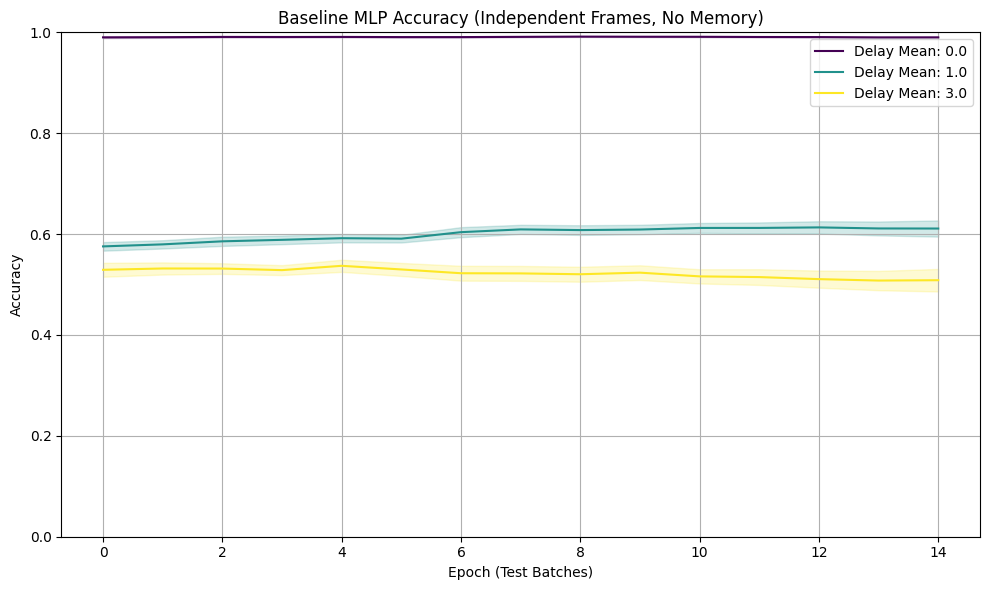

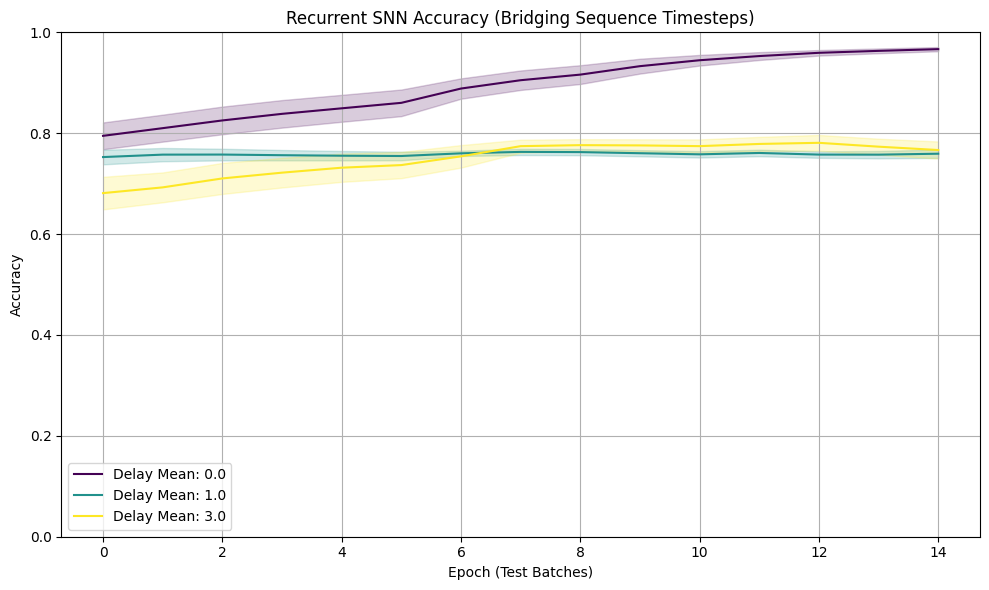

In [ ]:
import os
import io
import math
import random
import contextlib
import numpy as np
import warnings
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision import datasets, transforms

# snntorch dependencies
try:
    import snntorch as snn
    from snntorch import spikegen
except ImportError:
    print("snnTorch not found. Installing...")
    import subprocess
    subprocess.check_call(["pip", "install", "snntorch", "--quiet"])
    import snntorch as snn
    from snntorch import spikegen

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

class Config():
    def __init__(self):
        self.BATCH_SIZE = 128
        self.NUM_EPOCHS = 15
        self.NUM_INPUTS = np.int64(28**2) # 28x28 images
        self.NUM_OUTPUTS = 2 # Will dynamically adjust based on filtered classes
        self.NUM_HIDDEN = 500
        self.ACTIVATION = "leaky"
        self.BIAS = True

        self.BETA = 0.85 # Decay rate for leaky integrate-and-fire
        self.SEQ_LEN = 5 # The explicit temporal dimension length

        self.ADAM_BETA = (0.9, 0.999)
        self.LEARNING_RULE = 1e-3

        # Delay means to iterate over
        self.DELAY_MEANS = [0.0, 1.0, 3.0] #, 5.0]
        self.NUM_DESIRED_LABELS = 2

        self.TRAIN_PROPORTION = 0.8
        self.KEEP_PROPORTION = 0.25

config = Config()

class SequenceDataset(Dataset):
    """
    Wraps a standard image dataset to group independent images into temporal sequences.
    This creates an explicit time dimension [SEQ_LEN, C, H, W] for sequence modeling.
    """
    def __init__(self, base_dataset, seq_len):
        self.base_dataset = base_dataset
        self.seq_len = seq_len
        # We floor the length to ensure complete sequences
        self.num_sequences = len(self.base_dataset) // self.seq_len

    def __len__(self):
        return self.num_sequences

    def __getitem__(self, idx):
        start_idx = idx * self.seq_len
        images = []
        labels = []
        for i in range(self.seq_len):
            img, label = self.base_dataset[start_idx + i]
            images.append(img)
            labels.append(label)

        # Stack into [SEQ_LEN, C, H, W] and [SEQ_LEN]
        return torch.stack(images), torch.tensor(labels, dtype=torch.long)

def restrict_classes(dataset, classes=[0, 1, 2], keep=True):
    """Filters dataset to only contain specified classes."""
    if hasattr(dataset, "dataset"):
        indices = np.asarray(dataset.indices)
        targets = dataset.dataset.targets[indices]
        dataset = dataset.dataset
    else:
        indices = np.arange(len(dataset))
        targets = dataset.targets

    specified_idxs = np.isin(targets, np.asarray(classes))
    if keep:
        retain_indices = indices[specified_idxs]
    else:
        retain_indices = indices[~specified_idxs]

    return torch.utils.data.Subset(dataset, retain_indices)

def download_mnist(train_prop=0.8, keep_prop=0.5):
    valid_prop = 1 - train_prop
    discard_prop = 1 - keep_prop

    transform = transforms.Compose([
              transforms.Resize((28, 28)),
              transforms.Grayscale(),
              transforms.ToTensor(),
              transforms.Normalize((0.1307,), (0.3081,))
              ])

    with contextlib.redirect_stdout(io.StringIO()):
        full_train_set = torchvision.datasets.MNIST(
            root="./data/", train=True, download=True, transform=transform,
        )
        full_test_set = torchvision.datasets.MNIST(
            root="./data/", train=False, download=True, transform=transform,
        )

    train_set, valid_set, _ = torch.utils.data.random_split(
        full_train_set,
        [train_prop * keep_prop, valid_prop * keep_prop, discard_prop]
    )
    test_set, _ = torch.utils.data.random_split(
        full_test_set,
        [keep_prop, discard_prop]
    )
    return train_set, valid_set, test_set

def apply_sequence_delay(labels, delay_mean):
    """
    Applies a probabilistic forward shift to labels strictly along the sequence dimension.
    Args:
        labels (torch.Tensor): [Batch, Sequence_Length]
        delay_mean (float): Mean of Poisson distribution.
    Returns:
        torch.Tensor: [Batch, Sequence_Length] with shifted labels.
                      Empty/dropped slots are marked with -1.
    """
    B, seq_len = labels.shape
    delayed_labels = torch.full((B, seq_len), -1, dtype=torch.long)

    for b in range(B):
        # Sample a delay for every time step in the sequence
        delays = np.random.poisson(delay_mean, size=seq_len)
        occupied = [False] * seq_len

        for t in range(seq_len):
            desired_target_idx = t + delays[t]
            current_target_idx = desired_target_idx

            # Resolve collisions by pushing the label forward in time
            while current_target_idx < seq_len and occupied[current_target_idx]:
                current_target_idx += 1

            # Assign if it hasn't fallen off the end of the sequence window
            if current_target_idx < seq_len:
                delayed_labels[b, current_target_idx] = labels[b, t].item()
                occupied[current_target_idx] = True

    return delayed_labels

def get_dataloaders():
    train_base, _, test_base = download_mnist(
        train_prop=config.TRAIN_PROPORTION,
        keep_prop=config.KEEP_PROPORTION
    )

    # Determine subset of classes
    all_train_labels = [train_base.dataset.targets[i].item() for i in train_base.indices]
    unique_classes = torch.unique(torch.tensor(all_train_labels)).tolist()
    selected_classes = random.sample(unique_classes, config.NUM_DESIRED_LABELS)
    print(f"Selected classes for sequence generation: {sorted(selected_classes)}")

    train_filtered = restrict_classes(train_base, classes=selected_classes)
    test_filtered = restrict_classes(test_base, classes=selected_classes)

    # Wrap in sequence datasets
    train_seq_data = SequenceDataset(train_filtered, config.SEQ_LEN)
    test_seq_data = SequenceDataset(test_filtered, config.SEQ_LEN)

    # Map original labels (e.g., [2, 5, 8]) to contiguous range [0, 1, 2]
    class_map = {orig: new for new, orig in enumerate(sorted(selected_classes))}

    def sequence_collate(batch):
        images = torch.stack([item[0] for item in batch])
        raw_labels = torch.stack([item[1] for item in batch])

        # Apply class mapping
        mapped_labels = torch.empty_like(raw_labels)
        for orig, new in class_map.items():
            mapped_labels[raw_labels == orig] = new

        return images, mapped_labels

    train_loader = DataLoader(train_seq_data, batch_size=config.BATCH_SIZE, shuffle=True, collate_fn=sequence_collate, drop_last=False)
    test_loader = DataLoader(test_seq_data, batch_size=config.BATCH_SIZE, shuffle=False, collate_fn=sequence_collate, drop_last=False)

    return train_loader, test_loader

class SequenceMLP(nn.Module):
    """
    Baseline: Processes each frame in the sequence completely independently.
    Has zero temporal memory.
    """
    def __init__(self, num_inputs=config.NUM_INPUTS, num_hidden=config.NUM_HIDDEN, num_outputs=config.NUM_OUTPUTS):
        super().__init__()
        self.lin1 = nn.Linear(num_inputs, num_hidden, bias=config.BIAS)
        self.lin2 = nn.Linear(num_hidden, num_outputs, bias=config.BIAS)
        self.activation = nn.LeakyReLU(0.1)

    def forward(self, x):
        # x shape: [B, SEQ_LEN, C, H, W]
        B, SEQ_LEN = x.shape[0], x.shape[1]
        x_flat = x.view(B * SEQ_LEN, -1)
        h = self.activation(self.lin1(x_flat))
        y_pred = self.lin2(h)
        # Reshape back to sequence [B, SEQ_LEN, NUM_OUTPUTS]
        return y_pred.view(B, SEQ_LEN, -1)


class SequenceRecurrentSNN(nn.Module):
    """
    Recurrent architecture: Maintains membrane potential and spikes across
    the sequence dimension, allowing it to bridge temporal gaps.
    """
    def __init__(self, num_inputs=config.NUM_INPUTS, num_hidden=config.NUM_HIDDEN, num_outputs=config.NUM_OUTPUTS):
        super().__init__()
        self.fc1 = nn.Linear(num_inputs, num_hidden)
        # RLeaky includes recurrent all-to-all connections
        self.lif1 = snn.RLeaky(beta=config.BETA, linear_features=num_hidden, all_to_all=True)

        self.fc2 = nn.Linear(num_hidden, num_outputs)
        self.lif2 = snn.RLeaky(beta=config.BETA, linear_features=num_outputs, all_to_all=True)

    def forward(self, x):
        # x shape: [B, SEQ_LEN, C, H, W]
        B, SEQ_LEN = x.shape[0], x.shape[1]

        # Initialize hidden states at t=0
        spk1, mem1 = self.lif1.init_rleaky()
        spk2, mem2 = self.lif2.init_rleaky()

        mem2_rec = []

        # Iterate explicitly over the sequence dimension
        for t in range(SEQ_LEN):
            x_t = x[:, t, :].view(B, -1)

            cur1 = self.fc1(x_t)
            spk1, mem1 = self.lif1(cur1, spk1, mem1)

            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, spk2, mem2)

            # Record the membrane potential as the logits for this timestep
            mem2_rec.append(mem2)

        # Stack over time dimension: [B, SEQ_LEN, NUM_OUTPUTS]
        return torch.stack(mem2_rec, dim=1)

def train_sequence_model(model, train_loader, test_loader, delay_mean):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)
    # Ignore -1 which represents unassigned/shifted-out labels
    criterion = nn.CrossEntropyLoss(ignore_index=-1)

    train_acc_hist, test_acc_hist = [], []

    for epoch in range(config.NUM_EPOCHS):
        model.train()
        for data, targets in train_loader:
            # Apply temporal delay to the sequence targets
            delayed_targets = apply_sequence_delay(targets, delay_mean)

            data = data.to(device)
            delayed_targets = delayed_targets.to(device)

            # Forward pass: predictions shape [B, SEQ_LEN, NUM_CLASSES]
            preds = model(data)

            # Flatten for CrossEntropyLoss which expects [N, C] and [N]
            loss = criterion(preds.view(-1, config.NUM_OUTPUTS), delayed_targets.view(-1))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Train Accuracy calculation (ignoring -1 targets)
            valid_mask = (delayed_targets != -1)
            if valid_mask.sum() > 0:
                predicted_classes = torch.argmax(preds, dim=-1)
                correct = (predicted_classes == delayed_targets) & valid_mask
                acc = correct.sum().float() / valid_mask.sum().float()
                train_acc_hist.append(acc.item())

        # Evaluation
        model.eval()
        with torch.no_grad():
            test_acc_epoch = []
            for test_data, test_targets in test_loader:
                delayed_test_targets = apply_sequence_delay(test_targets, delay_mean)

                test_data = test_data.to(device)
                delayed_test_targets = delayed_test_targets.to(device)

                test_preds = model(test_data)

                valid_mask = (delayed_test_targets != -1)
                if valid_mask.sum() > 0:
                    predicted_test_classes = torch.argmax(test_preds, dim=-1)
                    correct = (predicted_test_classes == delayed_test_targets) & valid_mask
                    test_acc = correct.sum().float() / valid_mask.sum().float()
                    test_acc_epoch.append(test_acc.item())

            # Safely append the average accuracy or 0.0 if the loader was completely empty
            if test_acc_epoch:
                test_acc_hist.append(sum(test_acc_epoch) / len(test_acc_epoch))
            else:
                test_acc_hist.append(0.0)

    return test_acc_hist

def smooth_curve_with_sem(data, window_size):
    if len(data) < window_size:
        return np.array(data), np.zeros(len(data))
    smoothed, sem = [], []
    for i in range(len(data)):
        start = max(0, i - window_size // 2)
        end = min(len(data) - 1, i + window_size // 2)
        window = data[start:end + 1]
        smoothed.append(np.mean(window))
        sem.append(np.std(window) / np.sqrt(len(window)) if len(window) > 1 else 0.0)
    return np.array(smoothed), np.array(sem)

if __name__ == "__main__":
    print("Generating Sequential Data Loaders...")
    train_loader, test_loader = get_dataloaders()

    mlp_results = {}
    rsnn_results = {}

    for delay in config.DELAY_MEANS:
        print(f"\n--- Testing with Temporal Sequence Delay Mean: {delay} ---")

        # Test baseline MLP (No memory)
        print("Training Baseline Sequence MLP (No Memory)...")
        mlp = SequenceMLP()
        mlp_acc = train_sequence_model(mlp, train_loader, test_loader, delay)
        mlp_results[str(delay)] = mlp_acc

        # Test Recurrent SNN (Has memory)
        print("Training Recurrent SNN (Temporal Memory across sequence)...")
        rsnn = SequenceRecurrentSNN()
        rsnn_acc = train_sequence_model(rsnn, train_loader, test_loader, delay)
        rsnn_results[str(delay)] = rsnn_acc

    def plot_results(results_dict, title):
        plt.figure(figsize=(10, 6))
        colors = plt.cm.get_cmap('viridis', len(config.DELAY_MEANS))

        for i, (delay_str, data) in enumerate(results_dict.items()):
            sm_data, sem_data = smooth_curve_with_sem(data, 10)
            epochs = np.arange(len(sm_data))
            plt.plot(epochs, sm_data, label=f'Delay Mean: {float(delay_str):.1f}', color=colors(i))
            plt.fill_between(epochs, sm_data - sem_data, sm_data + sem_data, color=colors(i), alpha=0.2)

        plt.title(title)
        plt.xlabel('Epoch (Test Batches)')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(True)
        plt.ylim([0, 1.0])
        plt.tight_layout()
        plt.show()

    plot_results(mlp_results, "Baseline MLP Accuracy (Independent Frames, No Memory)")
    plot_results(rsnn_results, "Recurrent SNN Accuracy (Bridging Sequence Timesteps)")

Generating Sequential Data Loaders...
Selected classes for sequence generation: [6, 8]

--- Testing with Temporal Sequence Delay Mean: 0.0 ---
Training Baseline Sequence MLP (No Memory)...
Training Recurrent SNN (Temporal Memory across sequence)...

--- Testing with Temporal Sequence Delay Mean: 1.0 ---
Training Baseline Sequence MLP (No Memory)...
Training Recurrent SNN (Temporal Memory across sequence)...

--- Testing with Temporal Sequence Delay Mean: 3.0 ---
Training Baseline Sequence MLP (No Memory)...
Training Recurrent SNN (Temporal Memory across sequence)...


/tmp/ipykernel_769/2329564814.py:358: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', len(config.DELAY_MEANS))


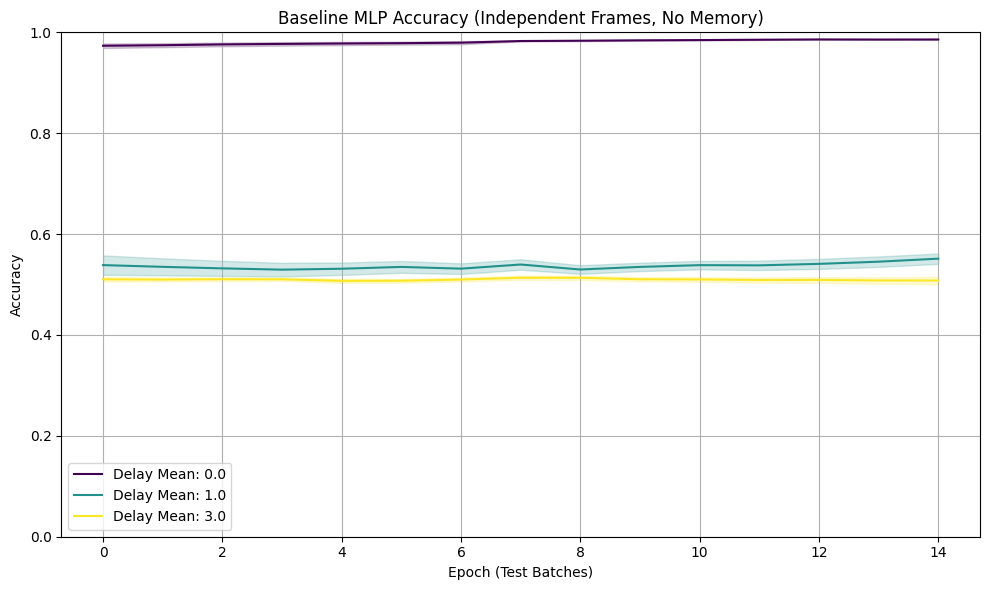

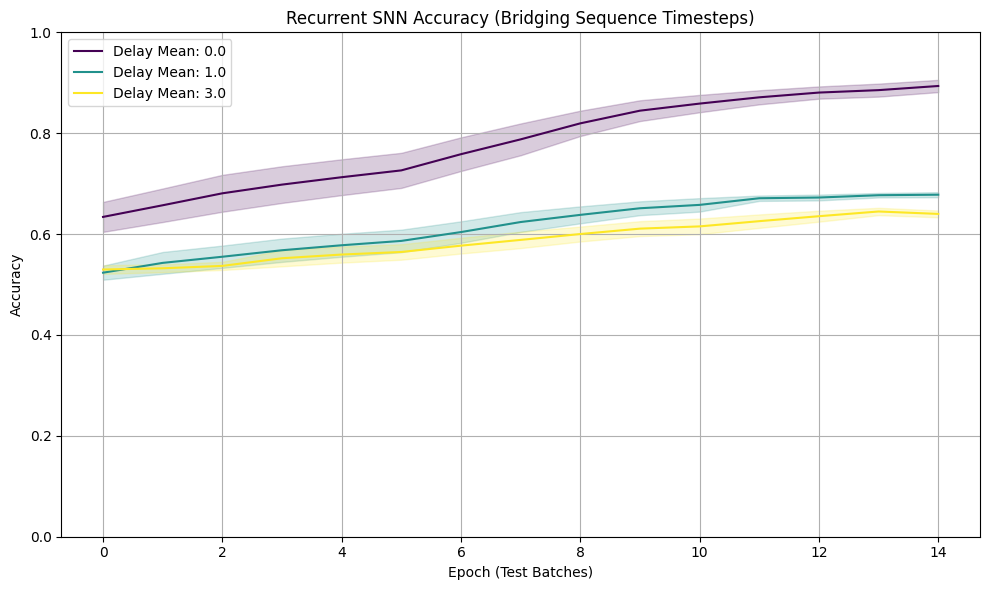

In [ ]:
import os
import io
import math
import random
import contextlib
import numpy as np
import warnings
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision import datasets, transforms

# snntorch dependencies
try:
    import snntorch as snn
    from snntorch import spikegen
except ImportError:
    print("snnTorch not found. Installing...")
    import subprocess
    subprocess.check_call(["pip", "install", "snntorch", "--quiet"])
    import snntorch as snn
    from snntorch import spikegen

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

class Config():
    def __init__(self):
        self.BATCH_SIZE = 128
        self.NUM_EPOCHS = 15
        self.NUM_INPUTS = np.int64(28**2) # 28x28 images
        self.NUM_OUTPUTS = 2 # Will dynamically adjust based on filtered classes
        self.NUM_HIDDEN = 500
        self.ACTIVATION = "leaky"
        self.BIAS = True

        self.BETA = 0.85 # Decay rate for leaky integrate-and-fire
        self.SEQ_LEN = 10 # The explicit temporal dimension length

        self.ADAM_BETA = (0.9, 0.999)
        self.LEARNING_RULE = 1e-3

        # Delay means to iterate over
        self.DELAY_MEANS = [0.0, 1.0, 3.0] #, 5.0]
        self.NUM_DESIRED_LABELS = 2

        self.TRAIN_PROPORTION = 0.8
        self.KEEP_PROPORTION = 0.25

config = Config()

class SequenceDataset(Dataset):
    """
    Wraps a standard image dataset to group independent images into temporal sequences.
    This creates an explicit time dimension [SEQ_LEN, C, H, W] for sequence modeling.
    """
    def __init__(self, base_dataset, seq_len):
        self.base_dataset = base_dataset
        self.seq_len = seq_len
        # We floor the length to ensure complete sequences
        self.num_sequences = len(self.base_dataset) // self.seq_len

    def __len__(self):
        return self.num_sequences

    def __getitem__(self, idx):
        start_idx = idx * self.seq_len
        images = []
        labels = []
        for i in range(self.seq_len):
            img, label = self.base_dataset[start_idx + i]
            images.append(img)
            labels.append(label)

        # Stack into [SEQ_LEN, C, H, W] and [SEQ_LEN]
        return torch.stack(images), torch.tensor(labels, dtype=torch.long)

def restrict_classes(dataset, classes=[0, 1, 2], keep=True):
    """Filters dataset to only contain specified classes."""
    if hasattr(dataset, "dataset"):
        indices = np.asarray(dataset.indices)
        targets = dataset.dataset.targets[indices]
        dataset = dataset.dataset
    else:
        indices = np.arange(len(dataset))
        targets = dataset.targets

    specified_idxs = np.isin(targets, np.asarray(classes))
    if keep:
        retain_indices = indices[specified_idxs]
    else:
        retain_indices = indices[~specified_idxs]

    return torch.utils.data.Subset(dataset, retain_indices)

def download_mnist(train_prop=0.8, keep_prop=0.5):
    valid_prop = 1 - train_prop
    discard_prop = 1 - keep_prop

    transform = transforms.Compose([
              transforms.Resize((28, 28)),
              transforms.Grayscale(),
              transforms.ToTensor(),
              transforms.Normalize((0.1307,), (0.3081,))
              ])

    with contextlib.redirect_stdout(io.StringIO()):
        full_train_set = torchvision.datasets.MNIST(
            root="./data/", train=True, download=True, transform=transform,
        )
        full_test_set = torchvision.datasets.MNIST(
            root="./data/", train=False, download=True, transform=transform,
        )

    train_set, valid_set, _ = torch.utils.data.random_split(
        full_train_set,
        [train_prop * keep_prop, valid_prop * keep_prop, discard_prop]
    )
    test_set, _ = torch.utils.data.random_split(
        full_test_set,
        [keep_prop, discard_prop]
    )
    return train_set, valid_set, test_set

def apply_sequence_delay(labels, delay_mean):
    """
    Applies a probabilistic forward shift to labels strictly along the sequence dimension.
    Args:
        labels (torch.Tensor): [Batch, Sequence_Length]
        delay_mean (float): Mean of Poisson distribution.
    Returns:
        torch.Tensor: [Batch, Sequence_Length] with shifted labels.
                      Empty/dropped slots are marked with -1.
    """
    B, seq_len = labels.shape
    delayed_labels = torch.full((B, seq_len), -1, dtype=torch.long)

    for b in range(B):
        # Sample a delay for every time step in the sequence
        delays = np.random.poisson(delay_mean, size=seq_len)
        occupied = [False] * seq_len

        for t in range(seq_len):
            desired_target_idx = t + delays[t]
            current_target_idx = desired_target_idx

            # Resolve collisions by pushing the label forward in time
            while current_target_idx < seq_len and occupied[current_target_idx]:
                current_target_idx += 1

            # Assign if it hasn't fallen off the end of the sequence window
            if current_target_idx < seq_len:
                delayed_labels[b, current_target_idx] = labels[b, t].item()
                occupied[current_target_idx] = True

    return delayed_labels

def get_dataloaders():
    train_base, _, test_base = download_mnist(
        train_prop=config.TRAIN_PROPORTION,
        keep_prop=config.KEEP_PROPORTION
    )

    # Determine subset of classes
    all_train_labels = [train_base.dataset.targets[i].item() for i in train_base.indices]
    unique_classes = torch.unique(torch.tensor(all_train_labels)).tolist()
    selected_classes = random.sample(unique_classes, config.NUM_DESIRED_LABELS)
    print(f"Selected classes for sequence generation: {sorted(selected_classes)}")

    train_filtered = restrict_classes(train_base, classes=selected_classes)
    test_filtered = restrict_classes(test_base, classes=selected_classes)

    # Wrap in sequence datasets
    train_seq_data = SequenceDataset(train_filtered, config.SEQ_LEN)
    test_seq_data = SequenceDataset(test_filtered, config.SEQ_LEN)

    # Map original labels (e.g., [2, 5, 8]) to contiguous range [0, 1, 2]
    class_map = {orig: new for new, orig in enumerate(sorted(selected_classes))}

    def sequence_collate(batch):
        images = torch.stack([item[0] for item in batch])
        raw_labels = torch.stack([item[1] for item in batch])

        # Apply class mapping
        mapped_labels = torch.empty_like(raw_labels)
        for orig, new in class_map.items():
            mapped_labels[raw_labels == orig] = new

        return images, mapped_labels

    train_loader = DataLoader(train_seq_data, batch_size=config.BATCH_SIZE, shuffle=True, collate_fn=sequence_collate, drop_last=False)
    test_loader = DataLoader(test_seq_data, batch_size=config.BATCH_SIZE, shuffle=False, collate_fn=sequence_collate, drop_last=False)

    return train_loader, test_loader

class SequenceMLP(nn.Module):
    """
    Baseline: Processes each frame in the sequence completely independently.
    Has zero temporal memory.
    """
    def __init__(self, num_inputs=config.NUM_INPUTS, num_hidden=config.NUM_HIDDEN, num_outputs=config.NUM_OUTPUTS):
        super().__init__()
        self.lin1 = nn.Linear(num_inputs, num_hidden, bias=config.BIAS)
        self.lin2 = nn.Linear(num_hidden, num_outputs, bias=config.BIAS)
        self.activation = nn.LeakyReLU(0.1)

    def forward(self, x):
        # x shape: [B, SEQ_LEN, C, H, W]
        B, SEQ_LEN = x.shape[0], x.shape[1]
        x_flat = x.view(B * SEQ_LEN, -1)
        h = self.activation(self.lin1(x_flat))
        y_pred = self.lin2(h)
        # Reshape back to sequence [B, SEQ_LEN, NUM_OUTPUTS]
        return y_pred.view(B, SEQ_LEN, -1)


class SequenceRecurrentSNN(nn.Module):
    """
    Recurrent architecture: Maintains membrane potential and spikes across
    the sequence dimension, allowing it to bridge temporal gaps.
    """
    def __init__(self, num_inputs=config.NUM_INPUTS, num_hidden=config.NUM_HIDDEN, num_outputs=config.NUM_OUTPUTS):
        super().__init__()
        self.fc1 = nn.Linear(num_inputs, num_hidden)
        # RLeaky includes recurrent all-to-all connections
        self.lif1 = snn.RLeaky(beta=config.BETA, linear_features=num_hidden, all_to_all=True)

        self.fc2 = nn.Linear(num_hidden, num_outputs)
        self.lif2 = snn.RLeaky(beta=config.BETA, linear_features=num_outputs, all_to_all=True)

    def forward(self, x):
        # x shape: [B, SEQ_LEN, C, H, W]
        B, SEQ_LEN = x.shape[0], x.shape[1]

        # Initialize hidden states at t=0
        spk1, mem1 = self.lif1.init_rleaky()
        spk2, mem2 = self.lif2.init_rleaky()

        mem2_rec = []

        # Iterate explicitly over the sequence dimension
        for t in range(SEQ_LEN):
            x_t = x[:, t, :].view(B, -1)

            cur1 = self.fc1(x_t)
            spk1, mem1 = self.lif1(cur1, spk1, mem1)

            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, spk2, mem2)

            # Record the membrane potential as the logits for this timestep
            mem2_rec.append(mem2)

        # Stack over time dimension: [B, SEQ_LEN, NUM_OUTPUTS]
        return torch.stack(mem2_rec, dim=1)

def train_sequence_model(model, train_loader, test_loader, delay_mean):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)
    # Ignore -1 which represents unassigned/shifted-out labels
    criterion = nn.CrossEntropyLoss(ignore_index=-1)

    train_acc_hist, test_acc_hist = [], []

    for epoch in range(config.NUM_EPOCHS):
        model.train()
        for data, targets in train_loader:
            # Apply temporal delay to the sequence targets
            delayed_targets = apply_sequence_delay(targets, delay_mean)

            data = data.to(device)
            delayed_targets = delayed_targets.to(device)

            # Forward pass: predictions shape [B, SEQ_LEN, NUM_CLASSES]
            preds = model(data)

            # Flatten for CrossEntropyLoss which expects [N, C] and [N]
            loss = criterion(preds.view(-1, config.NUM_OUTPUTS), delayed_targets.view(-1))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Train Accuracy calculation (ignoring -1 targets)
            valid_mask = (delayed_targets != -1)
            if valid_mask.sum() > 0:
                predicted_classes = torch.argmax(preds, dim=-1)
                correct = (predicted_classes == delayed_targets) & valid_mask
                acc = correct.sum().float() / valid_mask.sum().float()
                train_acc_hist.append(acc.item())

        # Evaluation
        model.eval()
        with torch.no_grad():
            test_acc_epoch = []
            for test_data, test_targets in test_loader:
                delayed_test_targets = apply_sequence_delay(test_targets, delay_mean)

                test_data = test_data.to(device)
                delayed_test_targets = delayed_test_targets.to(device)

                test_preds = model(test_data)

                valid_mask = (delayed_test_targets != -1)
                if valid_mask.sum() > 0:
                    predicted_test_classes = torch.argmax(test_preds, dim=-1)
                    correct = (predicted_test_classes == delayed_test_targets) & valid_mask
                    test_acc = correct.sum().float() / valid_mask.sum().float()
                    test_acc_epoch.append(test_acc.item())

            # Safely append the average accuracy or 0.0 if the loader was completely empty
            if test_acc_epoch:
                test_acc_hist.append(sum(test_acc_epoch) / len(test_acc_epoch))
            else:
                test_acc_hist.append(0.0)

    return test_acc_hist

def smooth_curve_with_sem(data, window_size):
    if len(data) < window_size:
        return np.array(data), np.zeros(len(data))
    smoothed, sem = [], []
    for i in range(len(data)):
        start = max(0, i - window_size // 2)
        end = min(len(data) - 1, i + window_size // 2)
        window = data[start:end + 1]
        smoothed.append(np.mean(window))
        sem.append(np.std(window) / np.sqrt(len(window)) if len(window) > 1 else 0.0)
    return np.array(smoothed), np.array(sem)

if __name__ == "__main__":
    print("Generating Sequential Data Loaders...")
    train_loader, test_loader = get_dataloaders()

    mlp_results = {}
    rsnn_results = {}

    for delay in config.DELAY_MEANS:
        print(f"\n--- Testing with Temporal Sequence Delay Mean: {delay} ---")

        # Test baseline MLP (No memory)
        print("Training Baseline Sequence MLP (No Memory)...")
        mlp = SequenceMLP()
        mlp_acc = train_sequence_model(mlp, train_loader, test_loader, delay)
        mlp_results[str(delay)] = mlp_acc

        # Test Recurrent SNN (Has memory)
        print("Training Recurrent SNN (Temporal Memory across sequence)...")
        rsnn = SequenceRecurrentSNN()
        rsnn_acc = train_sequence_model(rsnn, train_loader, test_loader, delay)
        rsnn_results[str(delay)] = rsnn_acc

    def plot_results(results_dict, title):
        plt.figure(figsize=(10, 6))
        colors = plt.cm.get_cmap('viridis', len(config.DELAY_MEANS))

        for i, (delay_str, data) in enumerate(results_dict.items()):
            sm_data, sem_data = smooth_curve_with_sem(data, 10)
            epochs = np.arange(len(sm_data))
            plt.plot(epochs, sm_data, label=f'Delay Mean: {float(delay_str):.1f}', color=colors(i))
            plt.fill_between(epochs, sm_data - sem_data, sm_data + sem_data, color=colors(i), alpha=0.2)

        plt.title(title)
        plt.xlabel('Epoch (Test Batches)')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(True)
        plt.ylim([0, 1.0])
        plt.tight_layout()
        plt.show()

    plot_results(mlp_results, "Baseline MLP Accuracy (Independent Frames, No Memory)")
    plot_results(rsnn_results, "Recurrent SNN Accuracy (Bridging Sequence Timesteps)")

Generating Sequential Data Loaders...
Selected classes for sequence generation: [4, 6]

--- Testing with Temporal Sequence Delay Mean: 0.0 ---
Training Baseline Sequence MLP (No Memory)...
Training Recurrent SNN (Temporal Memory across sequence)...

--- Testing with Temporal Sequence Delay Mean: 2.0 ---
Training Baseline Sequence MLP (No Memory)...
Training Recurrent SNN (Temporal Memory across sequence)...

--- Testing with Temporal Sequence Delay Mean: 4.0 ---
Training Baseline Sequence MLP (No Memory)...
Training Recurrent SNN (Temporal Memory across sequence)...

--- Testing with Temporal Sequence Delay Mean: 5.0 ---
Training Baseline Sequence MLP (No Memory)...
Training Recurrent SNN (Temporal Memory across sequence)...


/tmp/ipykernel_769/4184866325.py:358: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', len(config.DELAY_MEANS))


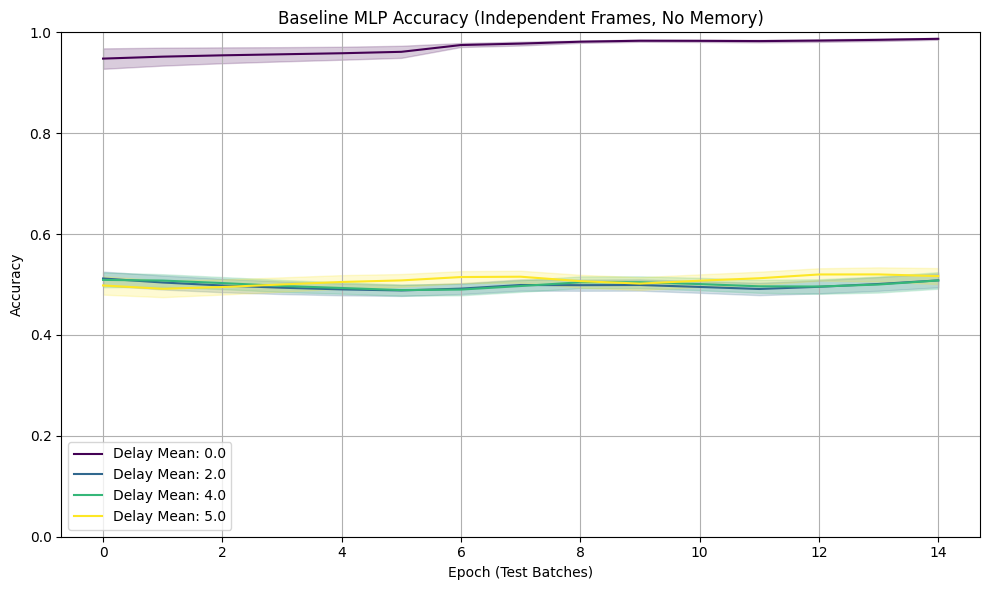

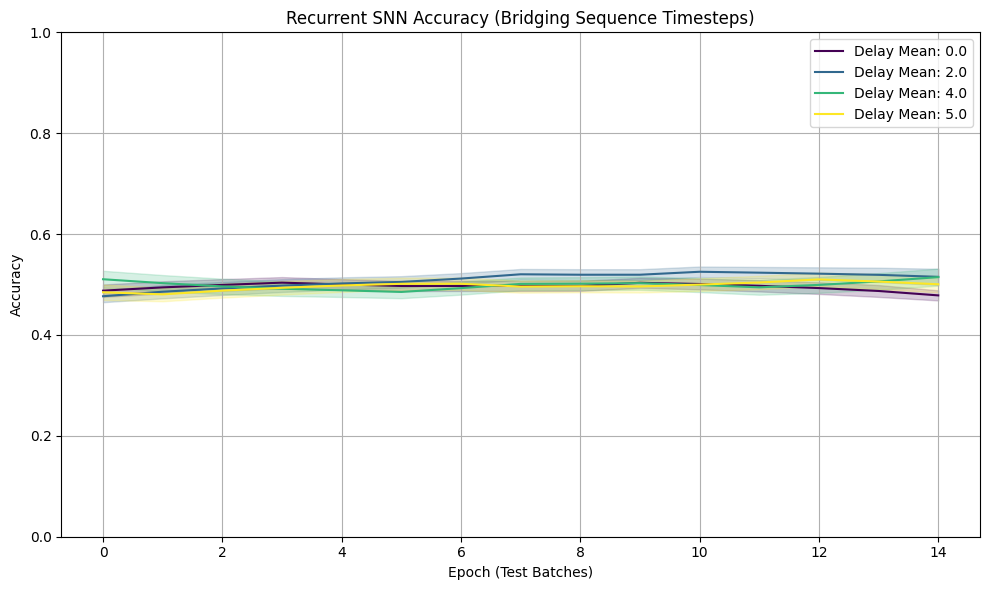

In [ ]:
import os
import io
import math
import random
import contextlib
import numpy as np
import warnings
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision import datasets, transforms

# snntorch dependencies
try:
    import snntorch as snn
    from snntorch import spikegen
except ImportError:
    print("snnTorch not found. Installing...")
    import subprocess
    subprocess.check_call(["pip", "install", "snntorch", "--quiet"])
    import snntorch as snn
    from snntorch import spikegen

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

class Config():
    def __init__(self):
        self.BATCH_SIZE = 128
        self.NUM_EPOCHS = 15
        self.NUM_INPUTS = np.int64(28**2) # 28x28 images
        self.NUM_OUTPUTS = 2 # Will dynamically adjust based on filtered classes
        self.NUM_HIDDEN = 5000
        self.ACTIVATION = "leaky"
        self.BIAS = True

        self.BETA = 0.85 # Decay rate for leaky integrate-and-fire
        self.SEQ_LEN = 30 # The explicit temporal dimension length

        self.ADAM_BETA = (0.9, 0.999)
        self.LEARNING_RULE = 1e-3

        # Delay means to iterate over
        self.DELAY_MEANS = [0.0, 2.0, 4.0, 5.0]
        self.NUM_DESIRED_LABELS = 2

        self.TRAIN_PROPORTION = 0.8
        self.KEEP_PROPORTION = 0.25

config = Config()

class SequenceDataset(Dataset):
    """
    Wraps a standard image dataset to group independent images into temporal sequences.
    This creates an explicit time dimension [SEQ_LEN, C, H, W] for sequence modeling.
    """
    def __init__(self, base_dataset, seq_len):
        self.base_dataset = base_dataset
        self.seq_len = seq_len
        # We floor the length to ensure complete sequences
        self.num_sequences = len(self.base_dataset) // self.seq_len

    def __len__(self):
        return self.num_sequences

    def __getitem__(self, idx):
        start_idx = idx * self.seq_len
        images = []
        labels = []
        for i in range(self.seq_len):
            img, label = self.base_dataset[start_idx + i]
            images.append(img)
            labels.append(label)

        # Stack into [SEQ_LEN, C, H, W] and [SEQ_LEN]
        return torch.stack(images), torch.tensor(labels, dtype=torch.long)

def restrict_classes(dataset, classes=[0, 1, 2], keep=True):
    """Filters dataset to only contain specified classes."""
    if hasattr(dataset, "dataset"):
        indices = np.asarray(dataset.indices)
        targets = dataset.dataset.targets[indices]
        dataset = dataset.dataset
    else:
        indices = np.arange(len(dataset))
        targets = dataset.targets

    specified_idxs = np.isin(targets, np.asarray(classes))
    if keep:
        retain_indices = indices[specified_idxs]
    else:
        retain_indices = indices[~specified_idxs]

    return torch.utils.data.Subset(dataset, retain_indices)

def download_mnist(train_prop=0.8, keep_prop=0.5):
    valid_prop = 1 - train_prop
    discard_prop = 1 - keep_prop

    transform = transforms.Compose([
              transforms.Resize((28, 28)),
              transforms.Grayscale(),
              transforms.ToTensor(),
              transforms.Normalize((0.1307,), (0.3081,))
              ])

    with contextlib.redirect_stdout(io.StringIO()):
        full_train_set = torchvision.datasets.MNIST(
            root="./data/", train=True, download=True, transform=transform,
        )
        full_test_set = torchvision.datasets.MNIST(
            root="./data/", train=False, download=True, transform=transform,
        )

    train_set, valid_set, _ = torch.utils.data.random_split(
        full_train_set,
        [train_prop * keep_prop, valid_prop * keep_prop, discard_prop]
    )
    test_set, _ = torch.utils.data.random_split(
        full_test_set,
        [keep_prop, discard_prop]
    )
    return train_set, valid_set, test_set

def apply_sequence_delay(labels, delay_mean):
    """
    Applies a probabilistic forward shift to labels strictly along the sequence dimension.
    Args:
        labels (torch.Tensor): [Batch, Sequence_Length]
        delay_mean (float): Mean of Poisson distribution.
    Returns:
        torch.Tensor: [Batch, Sequence_Length] with shifted labels.
                      Empty/dropped slots are marked with -1.
    """
    B, seq_len = labels.shape
    delayed_labels = torch.full((B, seq_len), -1, dtype=torch.long)

    for b in range(B):
        # Sample a delay for every time step in the sequence
        delays = np.random.poisson(delay_mean, size=seq_len)
        occupied = [False] * seq_len

        for t in range(seq_len):
            desired_target_idx = t + delays[t]
            current_target_idx = desired_target_idx

            # Resolve collisions by pushing the label forward in time
            while current_target_idx < seq_len and occupied[current_target_idx]:
                current_target_idx += 1

            # Assign if it hasn't fallen off the end of the sequence window
            if current_target_idx < seq_len:
                delayed_labels[b, current_target_idx] = labels[b, t].item()
                occupied[current_target_idx] = True

    return delayed_labels

def get_dataloaders():
    train_base, _, test_base = download_mnist(
        train_prop=config.TRAIN_PROPORTION,
        keep_prop=config.KEEP_PROPORTION
    )

    # Determine subset of classes
    all_train_labels = [train_base.dataset.targets[i].item() for i in train_base.indices]
    unique_classes = torch.unique(torch.tensor(all_train_labels)).tolist()
    selected_classes = random.sample(unique_classes, config.NUM_DESIRED_LABELS)
    print(f"Selected classes for sequence generation: {sorted(selected_classes)}")

    train_filtered = restrict_classes(train_base, classes=selected_classes)
    test_filtered = restrict_classes(test_base, classes=selected_classes)

    # Wrap in sequence datasets
    train_seq_data = SequenceDataset(train_filtered, config.SEQ_LEN)
    test_seq_data = SequenceDataset(test_filtered, config.SEQ_LEN)

    # Map original labels (e.g., [2, 5, 8]) to contiguous range [0, 1, 2]
    class_map = {orig: new for new, orig in enumerate(sorted(selected_classes))}

    def sequence_collate(batch):
        images = torch.stack([item[0] for item in batch])
        raw_labels = torch.stack([item[1] for item in batch])

        # Apply class mapping
        mapped_labels = torch.empty_like(raw_labels)
        for orig, new in class_map.items():
            mapped_labels[raw_labels == orig] = new

        return images, mapped_labels

    train_loader = DataLoader(train_seq_data, batch_size=config.BATCH_SIZE, shuffle=True, collate_fn=sequence_collate, drop_last=False)
    test_loader = DataLoader(test_seq_data, batch_size=config.BATCH_SIZE, shuffle=False, collate_fn=sequence_collate, drop_last=False)

    return train_loader, test_loader

class SequenceMLP(nn.Module):
    """
    Baseline: Processes each frame in the sequence completely independently.
    Has zero temporal memory.
    """
    def __init__(self, num_inputs=config.NUM_INPUTS, num_hidden=config.NUM_HIDDEN, num_outputs=config.NUM_OUTPUTS):
        super().__init__()
        self.lin1 = nn.Linear(num_inputs, num_hidden, bias=config.BIAS)
        self.lin2 = nn.Linear(num_hidden, num_outputs, bias=config.BIAS)
        self.activation = nn.LeakyReLU(0.1)

    def forward(self, x):
        # x shape: [B, SEQ_LEN, C, H, W]
        B, SEQ_LEN = x.shape[0], x.shape[1]
        x_flat = x.view(B * SEQ_LEN, -1)
        h = self.activation(self.lin1(x_flat))
        y_pred = self.lin2(h)
        # Reshape back to sequence [B, SEQ_LEN, NUM_OUTPUTS]
        return y_pred.view(B, SEQ_LEN, -1)


class SequenceRecurrentSNN(nn.Module):
    """
    Recurrent architecture: Maintains membrane potential and spikes across
    the sequence dimension, allowing it to bridge temporal gaps.
    """
    def __init__(self, num_inputs=config.NUM_INPUTS, num_hidden=config.NUM_HIDDEN, num_outputs=config.NUM_OUTPUTS):
        super().__init__()
        self.fc1 = nn.Linear(num_inputs, num_hidden)
        # RLeaky includes recurrent all-to-all connections
        self.lif1 = snn.RLeaky(beta=config.BETA, linear_features=num_hidden, all_to_all=True)

        self.fc2 = nn.Linear(num_hidden, num_outputs)
        self.lif2 = snn.RLeaky(beta=config.BETA, linear_features=num_outputs, all_to_all=True)

    def forward(self, x):
        # x shape: [B, SEQ_LEN, C, H, W]
        B, SEQ_LEN = x.shape[0], x.shape[1]

        # Initialize hidden states at t=0
        spk1, mem1 = self.lif1.init_rleaky()
        spk2, mem2 = self.lif2.init_rleaky()

        mem2_rec = []

        # Iterate explicitly over the sequence dimension
        for t in range(SEQ_LEN):
            x_t = x[:, t, :].view(B, -1)

            cur1 = self.fc1(x_t)
            spk1, mem1 = self.lif1(cur1, spk1, mem1)

            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, spk2, mem2)

            # Record the membrane potential as the logits for this timestep
            mem2_rec.append(mem2)

        # Stack over time dimension: [B, SEQ_LEN, NUM_OUTPUTS]
        return torch.stack(mem2_rec, dim=1)

def train_sequence_model(model, train_loader, test_loader, delay_mean):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)
    # Ignore -1 which represents unassigned/shifted-out labels
    criterion = nn.CrossEntropyLoss(ignore_index=-1)

    train_acc_hist, test_acc_hist = [], []

    for epoch in range(config.NUM_EPOCHS):
        model.train()
        for data, targets in train_loader:
            # Apply temporal delay to the sequence targets
            delayed_targets = apply_sequence_delay(targets, delay_mean)

            data = data.to(device)
            delayed_targets = delayed_targets.to(device)

            # Forward pass: predictions shape [B, SEQ_LEN, NUM_CLASSES]
            preds = model(data)

            # Flatten for CrossEntropyLoss which expects [N, C] and [N]
            loss = criterion(preds.view(-1, config.NUM_OUTPUTS), delayed_targets.view(-1))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Train Accuracy calculation (ignoring -1 targets)
            valid_mask = (delayed_targets != -1)
            if valid_mask.sum() > 0:
                predicted_classes = torch.argmax(preds, dim=-1)
                correct = (predicted_classes == delayed_targets) & valid_mask
                acc = correct.sum().float() / valid_mask.sum().float()
                train_acc_hist.append(acc.item())

        # Evaluation
        model.eval()
        with torch.no_grad():
            test_acc_epoch = []
            for test_data, test_targets in test_loader:
                delayed_test_targets = apply_sequence_delay(test_targets, delay_mean)

                test_data = test_data.to(device)
                delayed_test_targets = delayed_test_targets.to(device)

                test_preds = model(test_data)

                valid_mask = (delayed_test_targets != -1)
                if valid_mask.sum() > 0:
                    predicted_test_classes = torch.argmax(test_preds, dim=-1)
                    correct = (predicted_test_classes == delayed_test_targets) & valid_mask
                    test_acc = correct.sum().float() / valid_mask.sum().float()
                    test_acc_epoch.append(test_acc.item())

            # Safely append the average accuracy or 0.0 if the loader was completely empty
            if test_acc_epoch:
                test_acc_hist.append(sum(test_acc_epoch) / len(test_acc_epoch))
            else:
                test_acc_hist.append(0.0)

    return test_acc_hist

def smooth_curve_with_sem(data, window_size):
    if len(data) < window_size:
        return np.array(data), np.zeros(len(data))
    smoothed, sem = [], []
    for i in range(len(data)):
        start = max(0, i - window_size // 2)
        end = min(len(data) - 1, i + window_size // 2)
        window = data[start:end + 1]
        smoothed.append(np.mean(window))
        sem.append(np.std(window) / np.sqrt(len(window)) if len(window) > 1 else 0.0)
    return np.array(smoothed), np.array(sem)

if __name__ == "__main__":
    print("Generating Sequential Data Loaders...")
    train_loader, test_loader = get_dataloaders()

    mlp_results = {}
    rsnn_results = {}

    for delay in config.DELAY_MEANS:
        print(f"\n--- Testing with Temporal Sequence Delay Mean: {delay} ---")

        # Test baseline MLP (No memory)
        print("Training Baseline Sequence MLP (No Memory)...")
        mlp = SequenceMLP()
        mlp_acc = train_sequence_model(mlp, train_loader, test_loader, delay)
        mlp_results[str(delay)] = mlp_acc

        # Test Recurrent SNN (Has memory)
        print("Training Recurrent SNN (Temporal Memory across sequence)...")
        rsnn = SequenceRecurrentSNN()
        rsnn_acc = train_sequence_model(rsnn, train_loader, test_loader, delay)
        rsnn_results[str(delay)] = rsnn_acc

    def plot_results(results_dict, title):
        plt.figure(figsize=(10, 6))
        colors = plt.cm.get_cmap('viridis', len(config.DELAY_MEANS))

        for i, (delay_str, data) in enumerate(results_dict.items()):
            sm_data, sem_data = smooth_curve_with_sem(data, 10)
            epochs = np.arange(len(sm_data))
            plt.plot(epochs, sm_data, label=f'Delay Mean: {float(delay_str):.1f}', color=colors(i))
            plt.fill_between(epochs, sm_data - sem_data, sm_data + sem_data, color=colors(i), alpha=0.2)

        plt.title(title)
        plt.xlabel('Epoch (Test Batches)')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(True)
        plt.ylim([0, 1.0])
        plt.tight_layout()
        plt.show()

    plot_results(mlp_results, "Baseline MLP Accuracy (Independent Frames, No Memory)")
    plot_results(rsnn_results, "Recurrent SNN Accuracy (Bridging Sequence Timesteps)")

Generating Sequential Data Loaders...
Selected classes for sequence generation: [3, 8]

--- Testing with Temporal Sequence Delay Mean: 0.0 (DETERMINISTIC) ---
Training Recurrent SNN (Temporal Memory across sequence)...
Training Baseline Sequence MLP (No Memory)...

--- Testing with Temporal Sequence Delay Mean: 2.0 (DETERMINISTIC) ---
Training Recurrent SNN (Temporal Memory across sequence)...
Training Baseline Sequence MLP (No Memory)...

--- Testing with Temporal Sequence Delay Mean: 5.0 (DETERMINISTIC) ---
Training Recurrent SNN (Temporal Memory across sequence)...
Training Baseline Sequence MLP (No Memory)...

--- Testing with Temporal Sequence Delay Mean: 10.0 (DETERMINISTIC) ---
Training Recurrent SNN (Temporal Memory across sequence)...
Training Baseline Sequence MLP (No Memory)...

--- Testing with Temporal Sequence Delay Mean: 30.0 (DETERMINISTIC) ---
Training Recurrent SNN (Temporal Memory across sequence)...
Training Baseline Sequence MLP (No Memory)...

--- Generating Evalu

/tmp/ipykernel_769/2165718914.py:389: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', len(config.DELAY_MEANS))


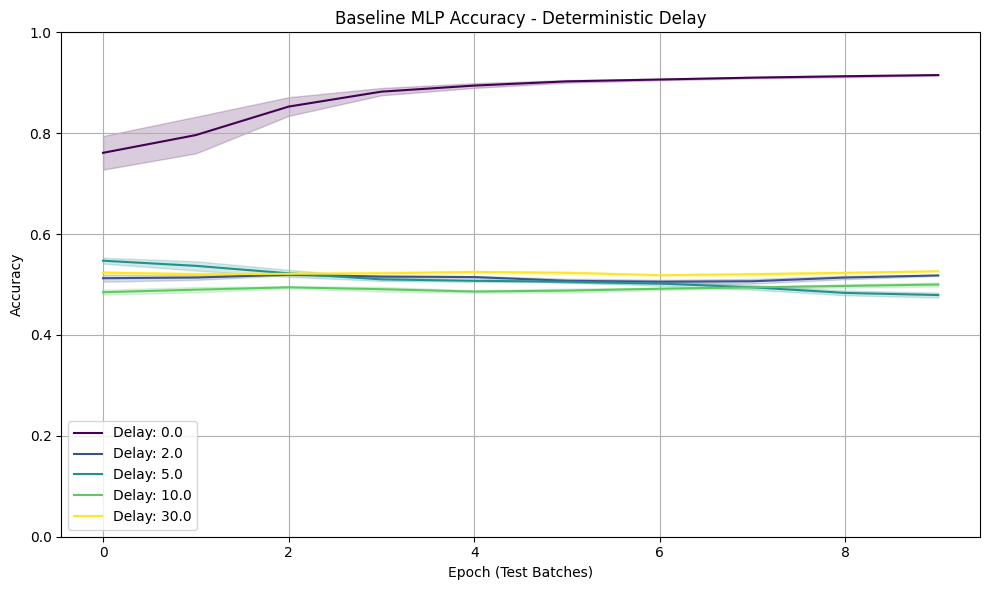

/tmp/ipykernel_769/2165718914.py:400: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


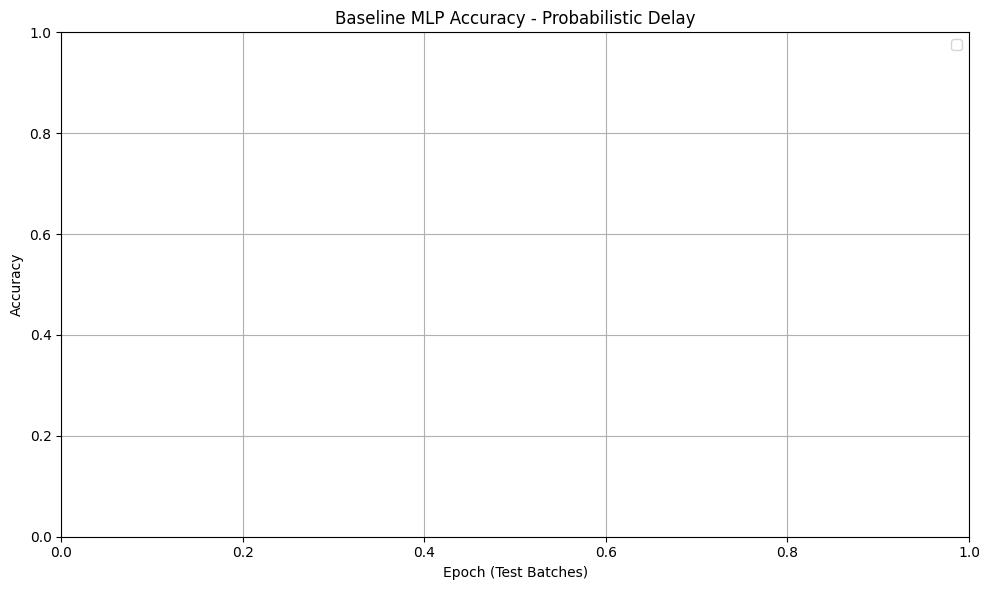

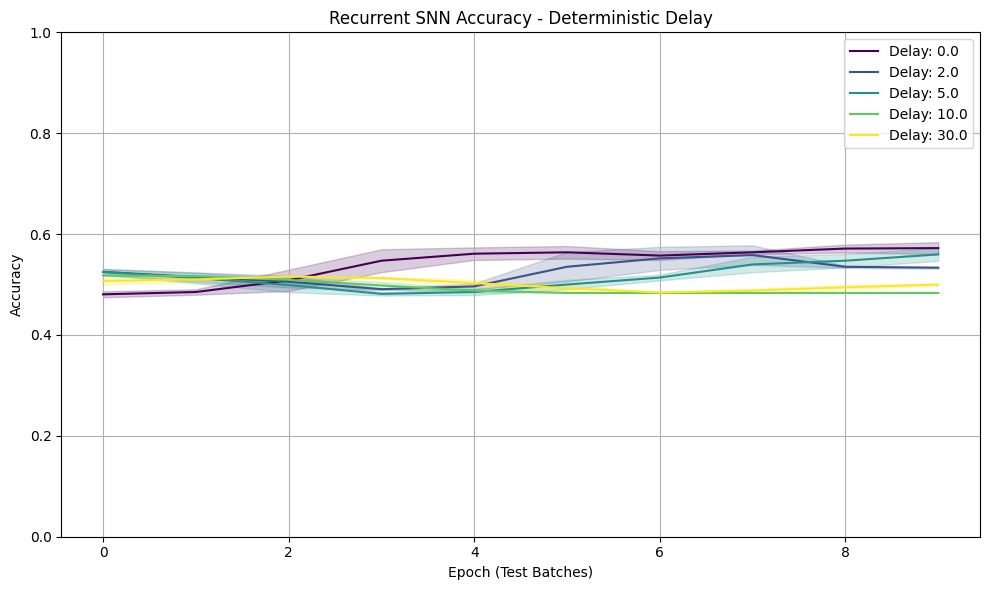

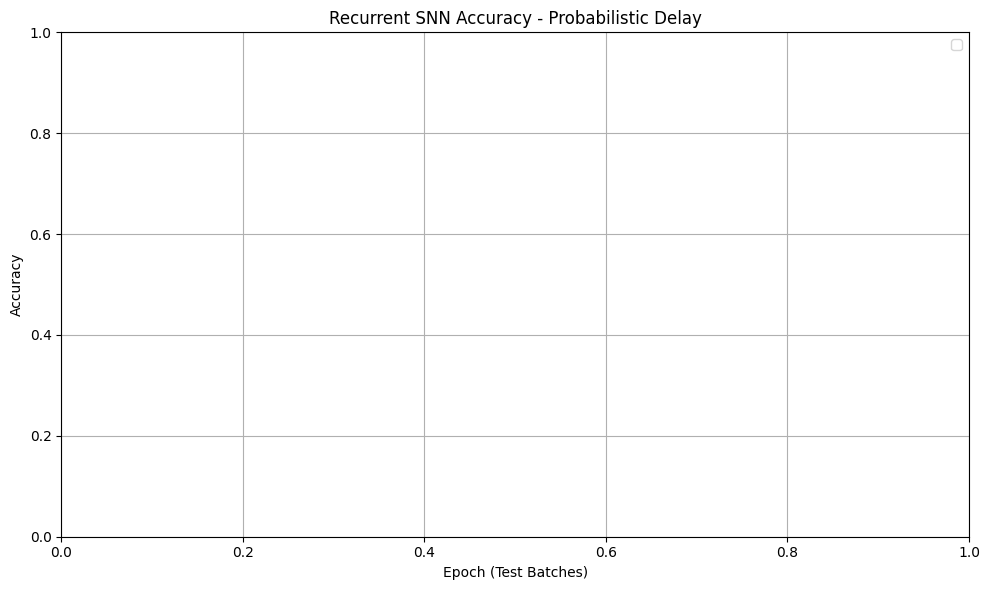

In [ ]:
#@title what if deterministic delay
import os
import io
import math
import random
import contextlib
import numpy as np
import warnings
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision import datasets, transforms

# snntorch dependencies
try:
    import snntorch as snn
    from snntorch import spikegen
except ImportError:
    print("snnTorch not found. Installing...")
    import subprocess
    subprocess.check_call(["pip", "install", "snntorch", "--quiet"])
    import snntorch as snn
    from snntorch import spikegen

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

class Config():
    def __init__(self):
        self.BATCH_SIZE = 128
        self.NUM_EPOCHS = 10
        self.NUM_INPUTS = np.int64(28**2) # 28x28 images
        self.NUM_OUTPUTS = 2 # Will dynamically adjust based on filtered classes
        self.NUM_HIDDEN = 200
        self.ACTIVATION = "leaky"
        self.BIAS = True

        self.BETA = 0.85 # Decay rate for leaky integrate-and-fire

        # --- PERFECT DELAY ISOLATION PARAMS ---
        self.NUM_LABELED_INPUTS = 30 # Number of actual stimuli to memorize (Active Window)
        self.MAX_DELAY = 50          # Padding to catch massively delayed labels without loss

        # Total Sequence Length = 80 timesteps
        self.SEQ_LEN = self.NUM_LABELED_INPUTS + self.MAX_DELAY

        self.ADAM_BETA = (0.9, 0.999)
        self.LEARNING_RULE = 1e-4

        # Massive delay sweep for titration
        self.DELAY_MEANS = [0.0, 2.0, 5.0, 10.0, 30.0]

        # Create a combined list to run both studies back-to-back
        self.STUDY_CONFIGS = [("deterministic", d) for d in self.DELAY_MEANS]
        self.CURRENT_DELAY_TYPE = "probabilistic" # Global tracker toggled in main loop

        self.NUM_DESIRED_LABELS = 2 # Change this integer to titrate classes (e.g. 2, 5, 10)

        self.TRAIN_PROPORTION = 0.7
        self.KEEP_PROPORTION = 0.5

config = Config()

class SequenceDataset(Dataset):
    """
    Wraps a standard image dataset to group independent images into temporal sequences.
    Implements a Constant Label Count architecture (Active Window + Padding Window)
    to perfectly isolate the delay variable from sequence edge truncation.
    """
    def __init__(self, base_dataset, num_labeled_inputs, max_delay):
        self.base_dataset = base_dataset
        self.num_labeled_inputs = num_labeled_inputs
        self.max_delay = int(max_delay)
        self.seq_len = num_labeled_inputs + self.max_delay
        # We floor the length to ensure complete sequences
        self.num_sequences = len(self.base_dataset) // self.seq_len

    def __len__(self):
        return self.num_sequences

    def __getitem__(self, idx):
        start_idx = idx * self.seq_len
        images = []
        labels = []
        for i in range(self.seq_len):
            img, label = self.base_dataset[start_idx + i]
            images.append(img)

            # Only assign the true label to the Active Window
            # The Padding Window gets -1 to catch delayed labels later
            if i < self.num_labeled_inputs:
                labels.append(label)
            else:
                labels.append(-1)

        # Stack into [SEQ_LEN, C, H, W] and [SEQ_LEN]
        return torch.stack(images), torch.tensor(labels, dtype=torch.long)

def restrict_classes(dataset, classes=[0, 1, 2], keep=True):
    """Filters dataset to only contain specified classes."""
    if hasattr(dataset, "dataset"):
        indices = np.asarray(dataset.indices)
        targets = dataset.dataset.targets[indices]
        dataset = dataset.dataset
    else:
        indices = np.arange(len(dataset))
        targets = dataset.targets

    specified_idxs = np.isin(targets, np.asarray(classes))
    if keep:
        retain_indices = indices[specified_idxs]
    else:
        retain_indices = indices[~specified_idxs]

    return torch.utils.data.Subset(dataset, retain_indices)

def download_mnist(train_prop=0.8, keep_prop=0.5):
    valid_prop = 1 - train_prop
    discard_prop = 1 - keep_prop

    transform = transforms.Compose([
              transforms.Resize((28, 28)),
              transforms.Grayscale(),
              transforms.ToTensor(),
              transforms.Normalize((0.1307,), (0.3081,))
              ])

    with contextlib.redirect_stdout(io.StringIO()):
        full_train_set = torchvision.datasets.MNIST(
            root="./data/", train=True, download=True, transform=transform,
        )
        full_test_set = torchvision.datasets.MNIST(
            root="./data/", train=False, download=True, transform=transform,
        )

    train_set, valid_set, _ = torch.utils.data.random_split(
        full_train_set,
        [train_prop * keep_prop, valid_prop * keep_prop, discard_prop]
    )
    test_set, _ = torch.utils.data.random_split(
        full_test_set,
        [keep_prop, discard_prop]
    )
    return train_set, valid_set, test_set

def apply_sequence_delay(labels, delay_mean):
    """
    Applies either a deterministic or probabilistic forward shift strictly along the sequence length.
    Reads config.CURRENT_DELAY_TYPE to toggle the behavior dynamically.
    """
    B, seq_len = labels.shape
    delayed_labels = torch.full((B, seq_len), -1, dtype=torch.long)

    for b in range(B):
        occupied = [False] * seq_len

        for t in range(seq_len):
            val = labels[b, t].item()
            if val == -1:
                continue # Do not shift the empty padding placeholders

            # Determine the delay amount based on current study type
            if config.CURRENT_DELAY_TYPE == "deterministic":
                delay_amount = int(delay_mean)
            else:
                delay_amount = np.random.poisson(delay_mean)

            desired_target_idx = t + delay_amount
            current_target_idx = desired_target_idx

            # Resolve sequence collisions by pushing forward in time
            while current_target_idx < seq_len and occupied[current_target_idx]:
                current_target_idx += 1

            if current_target_idx < seq_len:
                delayed_labels[b, current_target_idx] = val
                occupied[current_target_idx] = True

    return delayed_labels

def get_dataloaders():
    train_base, _, test_base = download_mnist(
        train_prop=config.TRAIN_PROPORTION,
        keep_prop=config.KEEP_PROPORTION
    )

    # Determine subset of classes
    all_train_labels = [train_base.dataset.targets[i].item() for i in train_base.indices]
    unique_classes = torch.unique(torch.tensor(all_train_labels)).tolist()
    selected_classes = random.sample(unique_classes, config.NUM_DESIRED_LABELS)
    print(f"Selected classes for sequence generation: {sorted(selected_classes)}")

    train_filtered = restrict_classes(train_base, classes=selected_classes)
    test_filtered = restrict_classes(test_base, classes=selected_classes)

    # Wrap in sequence datasets (Active Window + Padding Window)
    train_seq_data = SequenceDataset(train_filtered, config.NUM_LABELED_INPUTS, config.MAX_DELAY)
    test_seq_data = SequenceDataset(test_filtered, config.NUM_LABELED_INPUTS, config.MAX_DELAY)

    # Map original labels (e.g., [2, 5, 8]) to contiguous range [0, 1, 2]
    class_map = {orig: new for new, orig in enumerate(sorted(selected_classes))}

    def sequence_collate(batch):
        images = torch.stack([item[0] for item in batch])
        raw_labels = torch.stack([item[1] for item in batch])

        # Apply class mapping (ignoring -1)
        mapped_labels = torch.full_like(raw_labels, -1)
        for orig, new in class_map.items():
            mapped_labels[raw_labels == orig] = new

        return images, mapped_labels

    # Safely yield incomplete batches (drop_last=False) to fix StopIteration errors
    train_loader = DataLoader(train_seq_data, batch_size=config.BATCH_SIZE, shuffle=True, collate_fn=sequence_collate, drop_last=False)
    test_loader = DataLoader(test_seq_data, batch_size=config.BATCH_SIZE, shuffle=False, collate_fn=sequence_collate, drop_last=False)

    return train_loader, test_loader

class SequenceMLP(nn.Module):
    """
    Baseline: Processes each frame in the sequence completely independently.
    Has zero temporal memory. Serves as a performance control.
    """
    def __init__(self, num_inputs=config.NUM_INPUTS, num_hidden=config.NUM_HIDDEN, num_outputs=config.NUM_OUTPUTS):
        super().__init__()
        self.lin1 = nn.Linear(num_inputs, num_hidden, bias=config.BIAS)
        self.lin2 = nn.Linear(num_hidden, num_outputs, bias=config.BIAS)
        self.activation = nn.LeakyReLU(0.1)

    def forward(self, x):
        # x shape: [B, SEQ_LEN, C, H, W]
        B, SEQ_LEN = x.shape[0], x.shape[1]
        x_flat = x.view(B * SEQ_LEN, -1)
        h = self.activation(self.lin1(x_flat))
        y_pred = self.lin2(h)
        # Reshape back to sequence [B, SEQ_LEN, NUM_OUTPUTS]
        return y_pred.view(B, SEQ_LEN, -1)


class SequenceRecurrentSNN(nn.Module):
    """
    Recurrent architecture: Maintains membrane potential and spikes across
    the sequence dimension, explicitly bridging the temporal gap.
    """
    def __init__(self, num_inputs=config.NUM_INPUTS, num_hidden=config.NUM_HIDDEN, num_outputs=config.NUM_OUTPUTS):
        super().__init__()
        self.fc1 = nn.Linear(num_inputs, num_hidden)
        # RLeaky includes recurrent all-to-all connections
        self.lif1 = snn.RLeaky(beta=config.BETA, linear_features=num_hidden, all_to_all=True)

        self.fc2 = nn.Linear(num_hidden, num_outputs)
        self.lif2 = snn.RLeaky(beta=config.BETA, linear_features=num_outputs, all_to_all=True)

    def forward(self, x):
        # x shape: [B, SEQ_LEN, C, H, W]
        B, SEQ_LEN = x.shape[0], x.shape[1]

        # Initialize hidden states at t=0
        spk1, mem1 = self.lif1.init_rleaky()
        spk2, mem2 = self.lif2.init_rleaky()

        mem2_rec = []

        # Iterate explicitly over the sequence dimension
        for t in range(SEQ_LEN):
            x_t = x[:, t, :].view(B, -1)

            cur1 = self.fc1(x_t)
            spk1, mem1 = self.lif1(cur1, spk1, mem1)

            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, spk2, mem2)

            # Record the membrane potential as the logits for this timestep
            mem2_rec.append(mem2)

        # Stack over time dimension: [B, SEQ_LEN, NUM_OUTPUTS]
        return torch.stack(mem2_rec, dim=1)

def train_sequence_model(model, train_loader, test_loader, delay_mean):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)
    # Ignore -1 which represents unassigned/shifted-out labels and the padding window
    criterion = nn.CrossEntropyLoss(ignore_index=-1)

    train_acc_hist, test_acc_hist = [], []

    for epoch in range(config.NUM_EPOCHS):
        model.train()
        for data, targets in train_loader:
            # Apply temporal delay to the sequence targets dynamically
            delayed_targets = apply_sequence_delay(targets, delay_mean)

            data = data.to(device)
            delayed_targets = delayed_targets.to(device)

            # Forward pass: predictions shape [B, SEQ_LEN, NUM_CLASSES]
            preds = model(data)

            # Flatten for CrossEntropyLoss which expects [N, C] and [N]
            loss = criterion(preds.view(-1, config.NUM_OUTPUTS), delayed_targets.view(-1))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Train Accuracy calculation (ignoring -1 targets)
            valid_mask = (delayed_targets != -1)
            if valid_mask.sum() > 0:
                predicted_classes = torch.argmax(preds, dim=-1)
                correct = (predicted_classes == delayed_targets) & valid_mask
                acc = correct.sum().float() / valid_mask.sum().float()
                train_acc_hist.append(acc.item())

        # Safely Evaluate without next(iter()) which triggers StopIteration if empty
        model.eval()
        with torch.no_grad():
            test_acc_epoch = []
            for test_data, test_targets in test_loader:
                delayed_test_targets = apply_sequence_delay(test_targets, delay_mean)

                test_data = test_data.to(device)
                delayed_test_targets = delayed_test_targets.to(device)

                test_preds = model(test_data)

                valid_mask = (delayed_test_targets != -1)
                if valid_mask.sum() > 0:
                    predicted_test_classes = torch.argmax(test_preds, dim=-1)
                    correct = (predicted_test_classes == delayed_test_targets) & valid_mask
                    test_acc = correct.sum().float() / valid_mask.sum().float()
                    test_acc_epoch.append(test_acc.item())

            # Safely append the average accuracy or 0.0 if the loader was completely empty
            if test_acc_epoch:
                test_acc_hist.append(sum(test_acc_epoch) / len(test_acc_epoch))
            else:
                test_acc_hist.append(0.0)

    return test_acc_hist

def smooth_curve_with_sem(data, window_size):
    if len(data) < window_size:
        return np.array(data), np.zeros(len(data))
    smoothed, sem = [], []
    for i in range(len(data)):
        start = max(0, i - window_size // 2)
        end = min(len(data) - 1, i + window_size // 2)
        window = data[start:end + 1]
        smoothed.append(np.mean(window))
        sem.append(np.std(window) / np.sqrt(len(window)) if len(window) > 1 else 0.0)
    return np.array(smoothed), np.array(sem)

if __name__ == "__main__":
    print("Generating Sequential Data Loaders...")
    train_loader, test_loader = get_dataloaders()

    # Initialize nested dictionaries for both studies
    mlp_results = {"deterministic": {}, "probabilistic": {}}
    rsnn_results = {"deterministic": {}, "probabilistic": {}}

    for delay_type, delay in config.STUDY_CONFIGS:
        # Toggle the global state to switch delay generation math
        config.CURRENT_DELAY_TYPE = delay_type
        print(f"\n--- Testing with Temporal Sequence Delay Mean: {delay} ({delay_type.upper()}) ---")

        # Test Recurrent SNN (Has memory)
        print("Training Recurrent SNN (Temporal Memory across sequence)...")
        rsnn = SequenceRecurrentSNN(num_hidden=10*config.NUM_HIDDEN)
        rsnn_acc = train_sequence_model(rsnn, train_loader, test_loader, delay)
        rsnn_results[delay_type][str(delay)] = rsnn_acc

        # Test baseline MLP (No memory)
        print("Training Baseline Sequence MLP (No Memory)...")
        mlp = SequenceMLP()
        mlp_acc = train_sequence_model(mlp, train_loader, test_loader, delay)
        mlp_results[delay_type][str(delay)] = mlp_acc



    # Plotting Function to support the nested Dictionary structure
    def plot_study_results(results_dict, model_title):
        for delay_type, delays_data in results_dict.items():
            plt.figure(figsize=(10, 6))
            colors = plt.cm.get_cmap('viridis', len(config.DELAY_MEANS))

            for i, (delay_str, data) in enumerate(delays_data.items()):
                sm_data, sem_data = smooth_curve_with_sem(data, 3)
                epochs = np.arange(len(sm_data))
                plt.plot(epochs, sm_data, label=f'Delay: {float(delay_str):.1f}', color=colors(i))
                plt.fill_between(epochs, sm_data - sem_data, sm_data + sem_data, color=colors(i), alpha=0.2)

            plt.title(f"{model_title} - {delay_type.capitalize()} Delay")
            plt.xlabel('Epoch (Test Batches)')
            plt.ylabel('Accuracy')
            plt.legend()
            plt.grid(True)
            plt.ylim([0, 1.0])
            plt.tight_layout()
            plt.show()

    print("\n--- Generating Evaluation Plots ---")
    plot_study_results(mlp_results, "Baseline MLP Accuracy")
    plot_study_results(rsnn_results, "Recurrent SNN Accuracy")

Generating Sequential Data Loaders...
Selected classes for sequence generation: [4, 8]

--- Testing with Temporal Sequence Delay Mean: 0.0 (DETERMINISTIC) ---
Training Baseline Sequence MLP (No Memory)...
Training Recurrent SNN (Temporal Memory across sequence)...

--- Testing with Temporal Sequence Delay Mean: 2.0 (DETERMINISTIC) ---
Training Baseline Sequence MLP (No Memory)...
Training Recurrent SNN (Temporal Memory across sequence)...

--- Testing with Temporal Sequence Delay Mean: 0.0 (PROBABILISTIC) ---
Training Baseline Sequence MLP (No Memory)...
Training Recurrent SNN (Temporal Memory across sequence)...

--- Testing with Temporal Sequence Delay Mean: 2.0 (PROBABILISTIC) ---
Training Baseline Sequence MLP (No Memory)...
Training Recurrent SNN (Temporal Memory across sequence)...

--- Generating Evaluation Plots ---


/tmp/ipykernel_6677/3359444326.py:396: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', len(config.DELAY_MEANS))


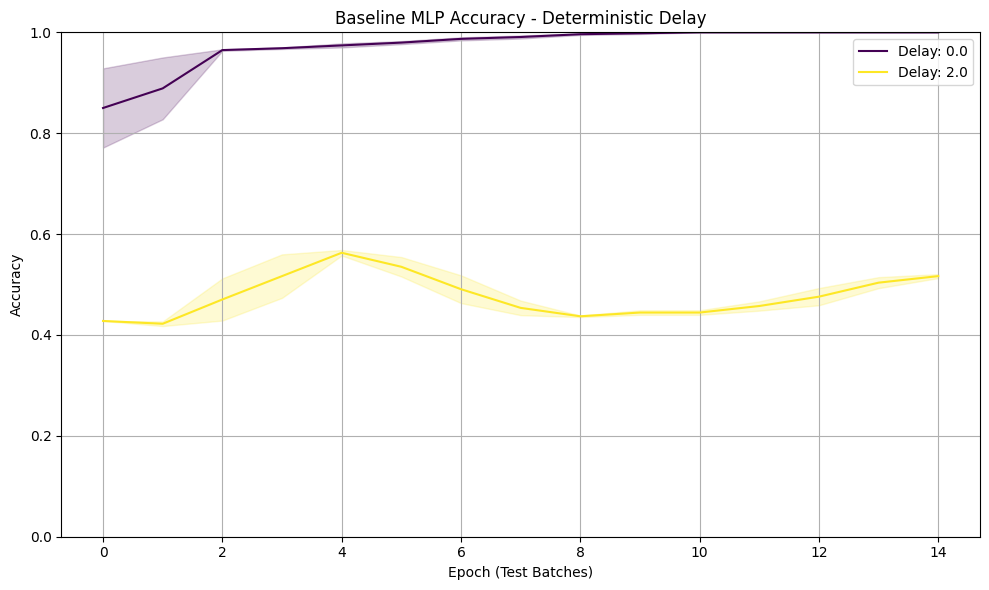

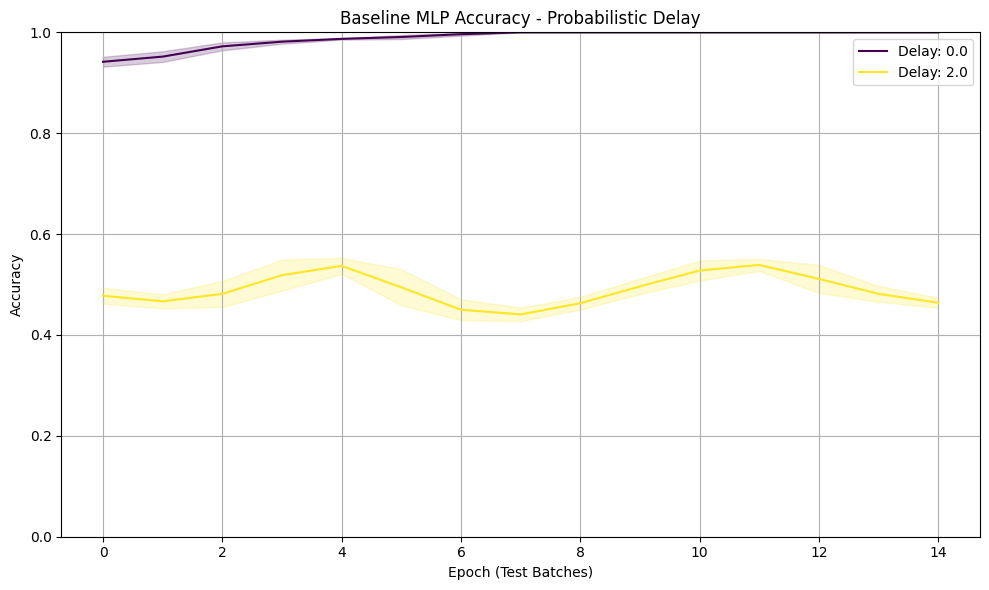

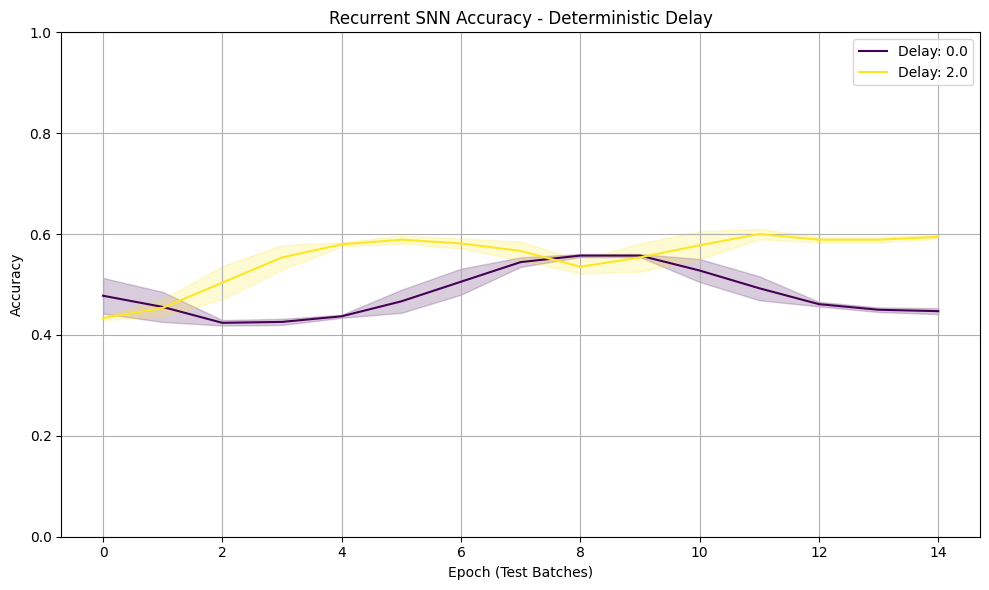

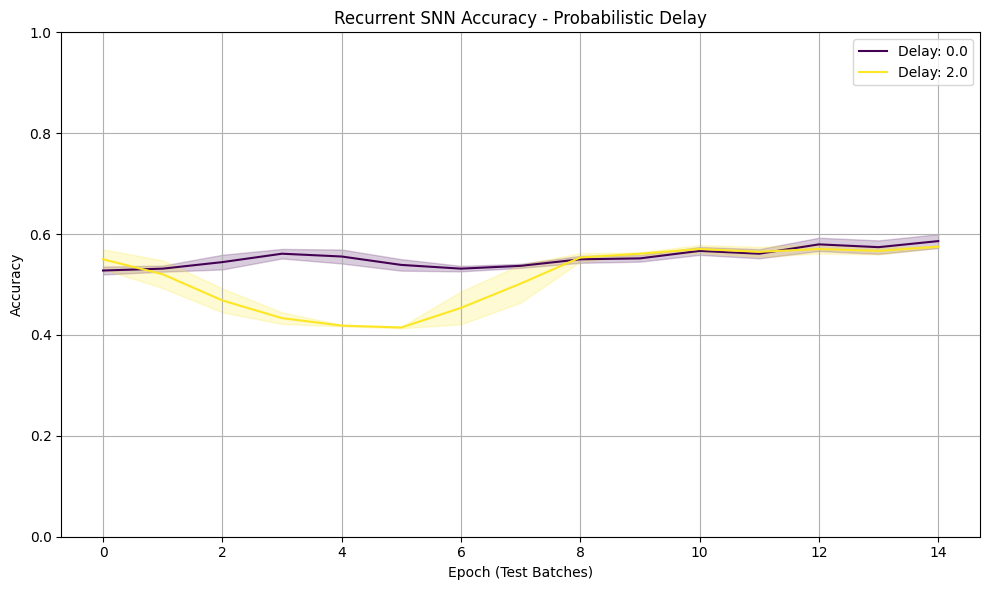

In [ ]:
import os
import io
import math
import random
import contextlib
import numpy as np
import warnings
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision import datasets, transforms

# snntorch dependencies
try:
    import snntorch as snn
    from snntorch import spikegen
except ImportError:
    print("snnTorch not found. Installing...")
    import subprocess
    subprocess.check_call(["pip", "install", "snntorch", "--quiet"])
    import snntorch as snn
    from snntorch import spikegen

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

class Config():
    def __init__(self):
        self.BATCH_SIZE = 128
        self.NUM_EPOCHS = 15
        self.NUM_INPUTS = np.int64(28**2) # 28x28 images
        self.NUM_OUTPUTS = 2 # Will dynamically adjust based on filtered classes
        self.NUM_HIDDEN = 100 # FIXED: Reduced from 5000 to prevent BPTT gradient explosion
        self.ACTIVATION = "leaky"
        self.BIAS = True

        self.BETA = 0.85 # Decay rate for leaky integrate-and-fire

        # --- PERFECT DELAY ISOLATION PARAMS ---
        self.NUM_LABELED_INPUTS = 30 # Number of actual stimuli to memorize (Active Window)
        self.MAX_DELAY = 50          # Padding to catch massively delayed labels without loss
        # Total Sequence Length = 80 timesteps
        self.SEQ_LEN = self.NUM_LABELED_INPUTS + self.MAX_DELAY

        self.ADAM_BETA = (0.9, 0.999)
        self.LEARNING_RULE = 1e-3

        # Massive delay sweep for titration
        self.DELAY_MEANS = [0.0, 2.0] #, 5.0, 10.0, 20.0, 30.0, 45.0]

        # Create a combined list to run both studies back-to-back
        self.STUDY_CONFIGS = [("deterministic", d) for d in self.DELAY_MEANS] + \
                             [("probabilistic", d) for d in self.DELAY_MEANS]
        self.CURRENT_DELAY_TYPE = "probabilistic" # Global tracker toggled in main loop

        self.NUM_DESIRED_LABELS = 2 # Change this integer to titrate classes (e.g. 2, 5, 10)

        self.TRAIN_PROPORTION = 0.8
        self.KEEP_PROPORTION = 0.25

config = Config()

class SequenceDataset(Dataset):
    """
    Wraps a standard image dataset to group independent images into temporal sequences.
    Implements a Constant Label Count architecture (Active Window + Padding Window)
    to perfectly isolate the delay variable from sequence edge truncation.
    """
    def __init__(self, base_dataset, num_labeled_inputs, max_delay):
        self.base_dataset = base_dataset
        self.num_labeled_inputs = num_labeled_inputs
        self.max_delay = int(max_delay)
        self.seq_len = num_labeled_inputs + self.max_delay
        # We floor the length to ensure complete sequences
        self.num_sequences = len(self.base_dataset) // self.seq_len

    def __len__(self):
        return self.num_sequences

    def __getitem__(self, idx):
        start_idx = idx * self.seq_len
        images = []
        labels = []
        for i in range(self.seq_len):
            img, label = self.base_dataset[start_idx + i]
            images.append(img)

            # Only assign the true label to the Active Window
            # The Padding Window gets -1 to catch delayed labels later
            if i < self.num_labeled_inputs:
                labels.append(label)
            else:
                labels.append(-1)

        # Stack into [SEQ_LEN, C, H, W] and [SEQ_LEN]
        return torch.stack(images), torch.tensor(labels, dtype=torch.long)

def restrict_classes(dataset, classes=[0, 1, 2], keep=True):
    """Filters dataset to only contain specified classes."""
    if hasattr(dataset, "dataset"):
        indices = np.asarray(dataset.indices)
        targets = dataset.dataset.targets[indices]
        dataset = dataset.dataset
    else:
        indices = np.arange(len(dataset))
        targets = dataset.targets

    specified_idxs = np.isin(targets, np.asarray(classes))
    if keep:
        retain_indices = indices[specified_idxs]
    else:
        retain_indices = indices[~specified_idxs]

    return torch.utils.data.Subset(dataset, retain_indices)

def download_mnist(train_prop=0.8, keep_prop=0.5):
    valid_prop = 1 - train_prop
    discard_prop = 1 - keep_prop

    transform = transforms.Compose([
              transforms.Resize((28, 28)),
              transforms.Grayscale(),
              transforms.ToTensor(),
              transforms.Normalize((0.1307,), (0.3081,))
              ])

    with contextlib.redirect_stdout(io.StringIO()):
        full_train_set = torchvision.datasets.MNIST(
            root="./data/", train=True, download=True, transform=transform,
        )
        full_test_set = torchvision.datasets.MNIST(
            root="./data/", train=False, download=True, transform=transform,
        )

    train_set, valid_set, _ = torch.utils.data.random_split(
        full_train_set,
        [train_prop * keep_prop, valid_prop * keep_prop, discard_prop]
    )
    test_set, _ = torch.utils.data.random_split(
        full_test_set,
        [keep_prop, discard_prop]
    )
    return train_set, valid_set, test_set

def apply_sequence_delay(labels, delay_mean):
    """
    Applies either a deterministic or probabilistic forward shift strictly along the sequence length.
    Reads config.CURRENT_DELAY_TYPE to toggle the behavior dynamically.
    """
    B, seq_len = labels.shape
    delayed_labels = torch.full((B, seq_len), -1, dtype=torch.long)

    for b in range(B):
        occupied = [False] * seq_len

        for t in range(seq_len):
            val = labels[b, t].item()
            if val == -1:
                continue # Do not shift the empty padding placeholders

            # Determine the delay amount based on current study type
            if config.CURRENT_DELAY_TYPE == "deterministic":
                delay_amount = int(delay_mean)
            else:
                delay_amount = np.random.poisson(delay_mean)

            desired_target_idx = t + delay_amount
            current_target_idx = desired_target_idx

            # Resolve sequence collisions by pushing forward in time
            while current_target_idx < seq_len and occupied[current_target_idx]:
                current_target_idx += 1

            if current_target_idx < seq_len:
                delayed_labels[b, current_target_idx] = val
                occupied[current_target_idx] = True

    return delayed_labels

def get_dataloaders():
    train_base, _, test_base = download_mnist(
        train_prop=config.TRAIN_PROPORTION,
        keep_prop=config.KEEP_PROPORTION
    )

    # Determine subset of classes
    all_train_labels = [train_base.dataset.targets[i].item() for i in train_base.indices]
    unique_classes = torch.unique(torch.tensor(all_train_labels)).tolist()
    selected_classes = random.sample(unique_classes, config.NUM_DESIRED_LABELS)
    print(f"Selected classes for sequence generation: {sorted(selected_classes)}")

    train_filtered = restrict_classes(train_base, classes=selected_classes)
    test_filtered = restrict_classes(test_base, classes=selected_classes)

    # Wrap in sequence datasets (Active Window + Padding Window)
    train_seq_data = SequenceDataset(train_filtered, config.NUM_LABELED_INPUTS, config.MAX_DELAY)
    test_seq_data = SequenceDataset(test_filtered, config.NUM_LABELED_INPUTS, config.MAX_DELAY)

    # Map original labels (e.g., [2, 5, 8]) to contiguous range [0, 1, 2]
    class_map = {orig: new for new, orig in enumerate(sorted(selected_classes))}

    def sequence_collate(batch):
        images = torch.stack([item[0] for item in batch])
        raw_labels = torch.stack([item[1] for item in batch])

        # Apply class mapping (ignoring -1)
        mapped_labels = torch.full_like(raw_labels, -1)
        for orig, new in class_map.items():
            mapped_labels[raw_labels == orig] = new

        return images, mapped_labels

    # Safely yield incomplete batches (drop_last=False) to fix StopIteration errors
    train_loader = DataLoader(train_seq_data, batch_size=config.BATCH_SIZE, shuffle=True, collate_fn=sequence_collate, drop_last=False)
    test_loader = DataLoader(test_seq_data, batch_size=config.BATCH_SIZE, shuffle=False, collate_fn=sequence_collate, drop_last=False)

    return train_loader, test_loader

class SequenceMLP(nn.Module):
    """
    Baseline: Processes each frame in the sequence completely independently.
    Has zero temporal memory. Serves as a performance control.
    """
    def __init__(self, num_inputs=config.NUM_INPUTS, num_hidden=config.NUM_HIDDEN, num_outputs=config.NUM_OUTPUTS):
        super().__init__()
        self.lin1 = nn.Linear(num_inputs, num_hidden, bias=config.BIAS)
        self.lin2 = nn.Linear(num_hidden, num_outputs, bias=config.BIAS)
        self.activation = nn.LeakyReLU(0.1)

    def forward(self, x):
        # x shape: [B, SEQ_LEN, C, H, W]
        B, SEQ_LEN = x.shape[0], x.shape[1]
        x_flat = x.view(B * SEQ_LEN, -1)
        h = self.activation(self.lin1(x_flat))
        y_pred = self.lin2(h)
        # Reshape back to sequence [B, SEQ_LEN, NUM_OUTPUTS]
        return y_pred.view(B, SEQ_LEN, -1)

class SequenceRecurrentSNN(nn.Module):
    """
    Stabilized Recurrent SNN with scaled inputs, gradient clipping compatibility,
    and non-resetting output logits.
    """
    def __init__(self, num_inputs=config.NUM_INPUTS, num_hidden=config.NUM_HIDDEN, num_outputs=config.NUM_OUTPUTS):
        super().__init__()
        self.fc1 = nn.Linear(num_inputs, num_hidden)

        # Explicitly scale up weights so single-timestep inputs have a robust initial response.
        # This helps overcome the fact that each frame is only presented for 1 timestep.
        nn.init.normal_(self.fc1.weight, mean=0.0, std=0.2)

        # RLeaky includes recurrent all-to-all connections
        self.lif1 = snn.RLeaky(beta=config.BETA, linear_features=num_hidden, all_to_all=True)

        self.fc2 = nn.Linear(num_hidden, num_outputs)

        # FIXED: Disable reset mechanism so membrane potential (logits) doesn't collapse to 0 on spike
        self.lif2 = snn.RLeaky(beta=config.BETA, linear_features=num_outputs, all_to_all=True, reset_mechanism="none")

    def forward(self, x):
        # x shape: [B, SEQ_LEN, C, H, W]
        B, SEQ_LEN = x.shape[0], x.shape[1]

        # Initialize hidden states at t=0
        spk1, mem1 = self.lif1.init_rleaky()
        spk2, mem2 = self.lif2.init_rleaky()

        mem2_rec = []

        # Iterate explicitly over the sequence dimension
        for t in range(SEQ_LEN):
            x_t = x[:, t, :].view(B, -1)

            cur1 = self.fc1(x_t)
            spk1, mem1 = self.lif1(cur1, spk1, mem1)

            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, spk2, mem2)

            # Record the membrane potential as the logits for this timestep
            mem2_rec.append(mem2)

        # Stack over time dimension: [B, SEQ_LEN, NUM_OUTPUTS]
        return torch.stack(mem2_rec, dim=1)

def train_sequence_model(model, train_loader, test_loader, delay_mean):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)
    # Ignore -1 which represents unassigned/shifted-out labels and the padding window
    criterion = nn.CrossEntropyLoss(ignore_index=-1)

    train_acc_hist, test_acc_hist = [], []

    for epoch in range(config.NUM_EPOCHS):
        model.train()
        for data, targets in train_loader:
            # Apply temporal delay to the sequence targets dynamically
            delayed_targets = apply_sequence_delay(targets, delay_mean)

            data = data.to(device)
            delayed_targets = delayed_targets.to(device)

            # Forward pass: predictions shape [B, SEQ_LEN, NUM_CLASSES]
            preds = model(data)

            # Flatten for CrossEntropyLoss which expects [N, C] and [N]
            loss = criterion(preds.view(-1, config.NUM_OUTPUTS), delayed_targets.view(-1))

            optimizer.zero_grad()
            loss.backward()

            # FIXED: Gradient clipping to stabilize Backpropagation Through Time (BPTT)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            # Train Accuracy calculation (ignoring -1 targets)
            valid_mask = (delayed_targets != -1)
            if valid_mask.sum() > 0:
                predicted_classes = torch.argmax(preds, dim=-1)
                correct = (predicted_classes == delayed_targets) & valid_mask
                acc = correct.sum().float() / valid_mask.sum().float()
                train_acc_hist.append(acc.item())

        # Safely Evaluate
        model.eval()
        with torch.no_grad():
            test_acc_epoch = []
            for test_data, test_targets in test_loader:
                delayed_test_targets = apply_sequence_delay(test_targets, delay_mean)

                test_data = test_data.to(device)
                delayed_test_targets = delayed_test_targets.to(device)

                test_preds = model(test_data)

                valid_mask = (delayed_test_targets != -1)
                if valid_mask.sum() > 0:
                    predicted_test_classes = torch.argmax(test_preds, dim=-1)
                    correct = (predicted_test_classes == delayed_test_targets) & valid_mask
                    test_acc = correct.sum().float() / valid_mask.sum().float()
                    test_acc_epoch.append(test_acc.item())

            # Safely append the average accuracy or 0.0 if the loader was completely empty
            if test_acc_epoch:
                test_acc_hist.append(sum(test_acc_epoch) / len(test_acc_epoch))
            else:
                test_acc_hist.append(0.0)

    return test_acc_hist

def smooth_curve_with_sem(data, window_size):
    if len(data) < window_size:
        return np.array(data), np.zeros(len(data))
    smoothed, sem = [], []
    for i in range(len(data)):
        start = max(0, i - window_size // 2)
        end = min(len(data) - 1, i + window_size // 2)
        window = data[start:end + 1]
        smoothed.append(np.mean(window))
        sem.append(np.std(window) / np.sqrt(len(window)) if len(window) > 1 else 0.0)
    return np.array(smoothed), np.array(sem)

if __name__ == "__main__":
    print("Generating Sequential Data Loaders...")
    train_loader, test_loader = get_dataloaders()

    # Initialize nested dictionaries for both studies
    mlp_results = {"deterministic": {}, "probabilistic": {}}
    rsnn_results = {"deterministic": {}, "probabilistic": {}}

    for delay_type, delay in config.STUDY_CONFIGS:
        # Toggle the global state to switch delay generation math
        config.CURRENT_DELAY_TYPE = delay_type
        print(f"\n--- Testing with Temporal Sequence Delay Mean: {delay} ({delay_type.upper()}) ---")

        # Test baseline MLP (No memory)
        print("Training Baseline Sequence MLP (No Memory)...")
        mlp = SequenceMLP()
        mlp_acc = train_sequence_model(mlp, train_loader, test_loader, delay)
        mlp_results[delay_type][str(delay)] = mlp_acc

        # Test Recurrent SNN (Has memory)
        print("Training Recurrent SNN (Temporal Memory across sequence)...")
        rsnn = SequenceRecurrentSNN()
        rsnn_acc = train_sequence_model(rsnn, train_loader, test_loader, delay)
        rsnn_results[delay_type][str(delay)] = rsnn_acc

    # Plotting Function to support the nested Dictionary structure
    def plot_study_results(results_dict, model_title):
        for delay_type, delays_data in results_dict.items():
            plt.figure(figsize=(10, 6))
            colors = plt.cm.get_cmap('viridis', len(config.DELAY_MEANS))

            for i, (delay_str, data) in enumerate(delays_data.items()):
                sm_data, sem_data = smooth_curve_with_sem(data, 3)
                epochs = np.arange(len(sm_data))
                plt.plot(epochs, sm_data, label=f'Delay: {float(delay_str):.1f}', color=colors(i))
                plt.fill_between(epochs, sm_data - sem_data, sm_data + sem_data, color=colors(i), alpha=0.2)

            plt.title(f"{model_title} - {delay_type.capitalize()} Delay")
            plt.xlabel('Epoch (Test Batches)')
            plt.ylabel('Accuracy')
            plt.legend()
            plt.grid(True)
            plt.ylim([0, 1.0])
            plt.tight_layout()
            plt.show()

    print("\n--- Generating Evaluation Plots ---")
    plot_study_results(mlp_results, "Baseline MLP Accuracy")
    plot_study_results(rsnn_results, "Recurrent SNN Accuracy")

Generating Sequential Data Loaders...
Selected classes for sequence generation: [1, 7]

--- Testing with Temporal Sequence Delay Mean: 0.0 (DETERMINISTIC) ---
Training Baseline Sequence MLP (No Memory)...
Training Standard RNN (Classical Temporal Memory)...
Training Recurrent SNN (Temporal Memory across sequence)...

--- Testing with Temporal Sequence Delay Mean: 2.0 (DETERMINISTIC) ---
Training Baseline Sequence MLP (No Memory)...
Training Standard RNN (Classical Temporal Memory)...
Training Recurrent SNN (Temporal Memory across sequence)...

--- Testing with Temporal Sequence Delay Mean: 5.0 (DETERMINISTIC) ---
Training Baseline Sequence MLP (No Memory)...
Training Standard RNN (Classical Temporal Memory)...
Training Recurrent SNN (Temporal Memory across sequence)...

--- Testing with Temporal Sequence Delay Mean: 0.0 (PROBABILISTIC) ---
Training Baseline Sequence MLP (No Memory)...
Training Standard RNN (Classical Temporal Memory)...
Training Recurrent SNN (Temporal Memory across se

/tmp/ipykernel_6677/3762128889.py:427: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', len(config.DELAY_MEANS))


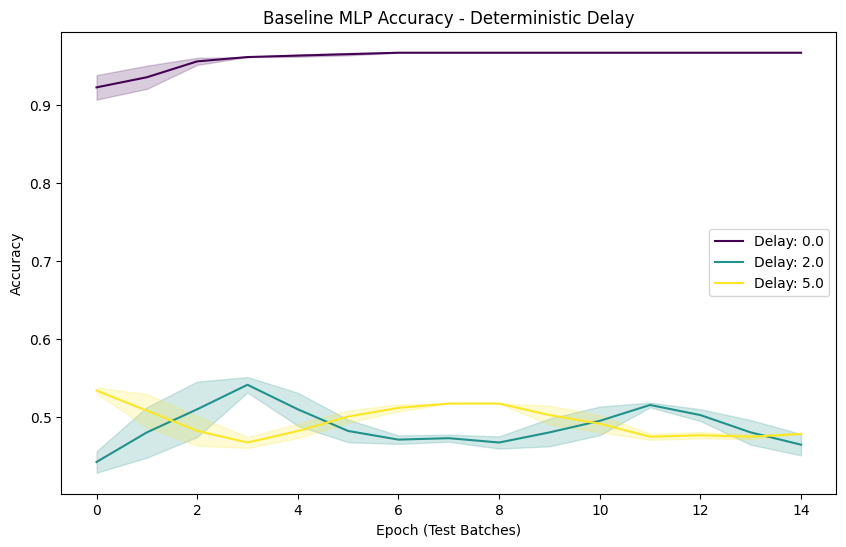

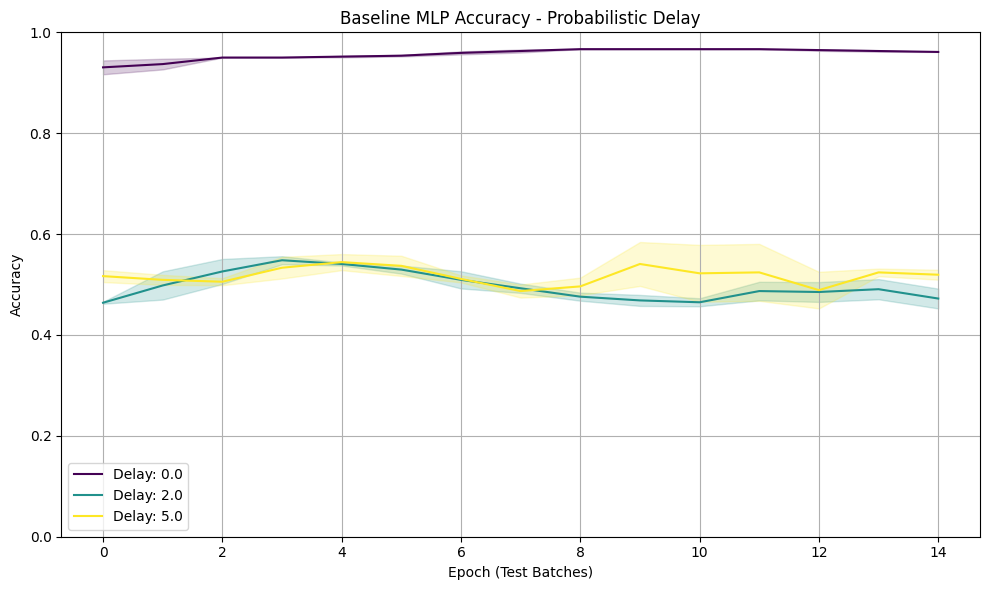

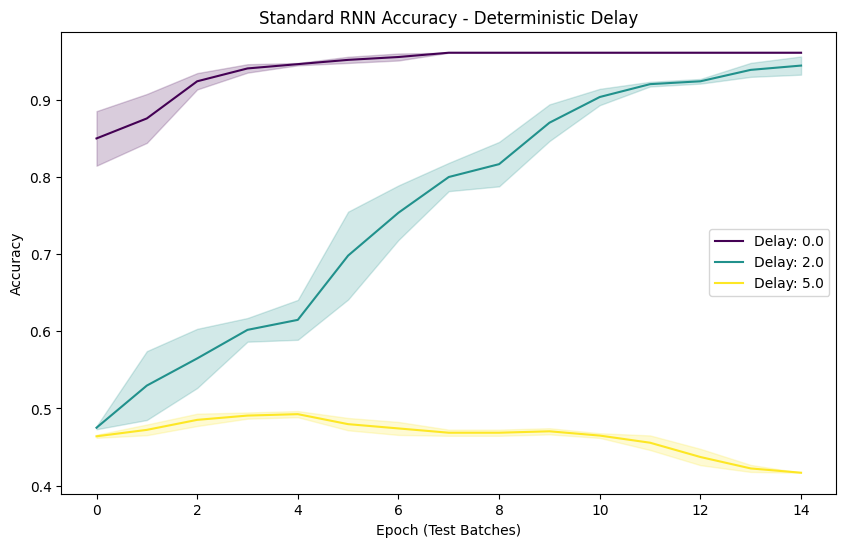

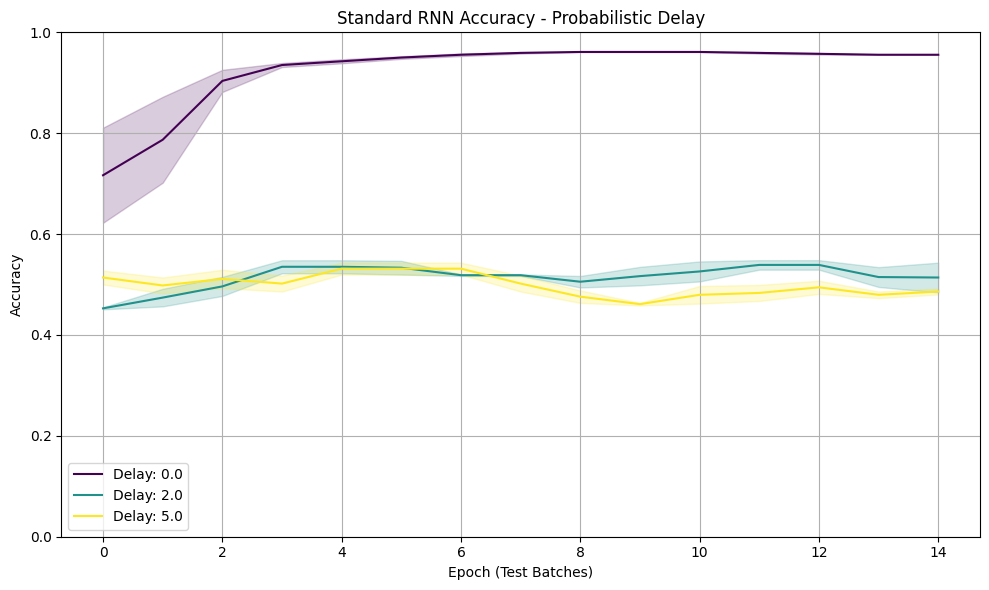

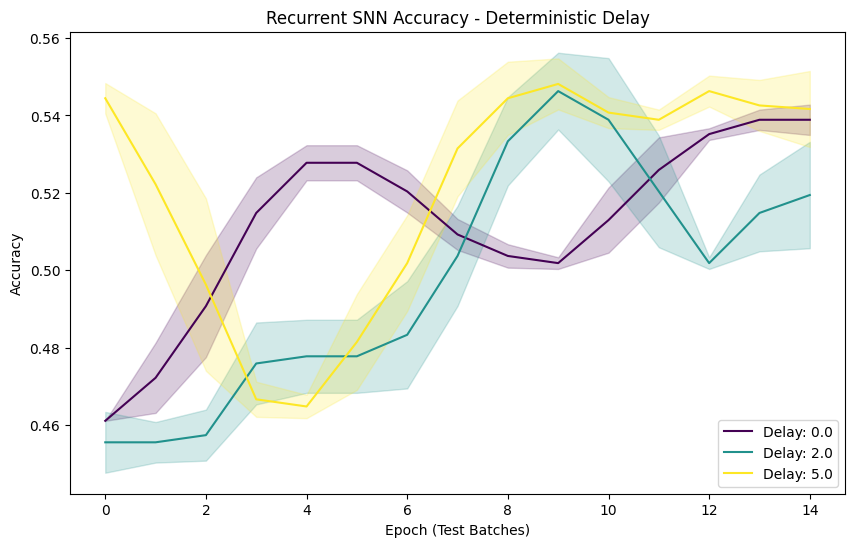

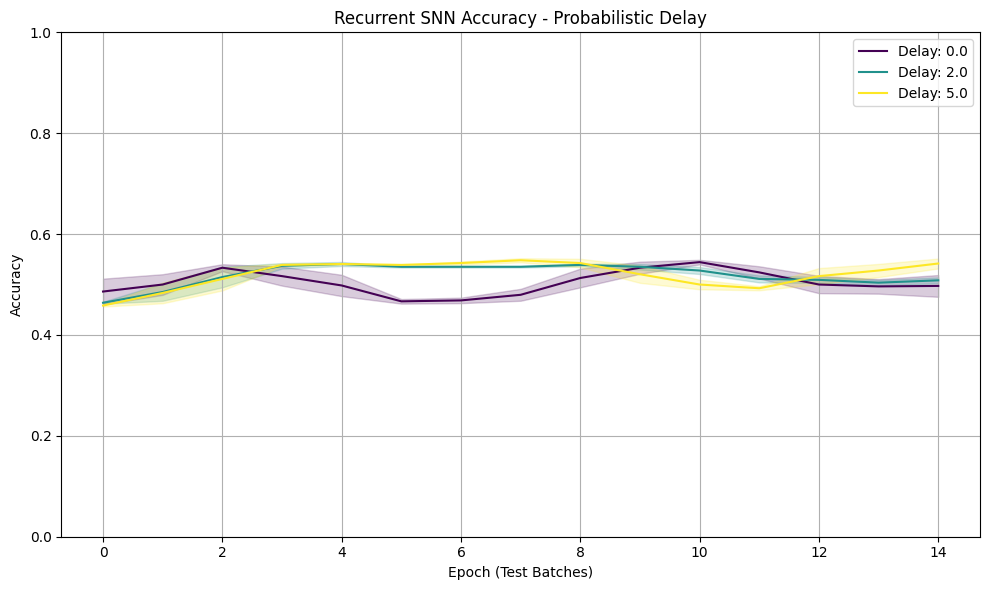

In [ ]:
import os
import io
import math
import random
import contextlib
import numpy as np
import warnings
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision import datasets, transforms

# snntorch dependencies
try:
    import snntorch as snn
    from snntorch import spikegen
except ImportError:
    print("snnTorch not found. Installing...")
    import subprocess
    subprocess.check_call(["pip", "install", "snntorch", "--quiet"])
    import snntorch as snn
    from snntorch import spikegen

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

class Config():
    def __init__(self):
        self.BATCH_SIZE = 128
        self.NUM_EPOCHS = 15
        self.NUM_INPUTS = int(28**2) # 28x28 images
        self.NUM_OUTPUTS = 2 # Will dynamically adjust based on filtered classes
        self.NUM_HIDDEN = 100 # FIXED: Reduced from 5000 to prevent BPTT gradient explosion
        self.ACTIVATION = "leaky"
        self.BIAS = True

        self.BETA = 0.85 # Decay rate for leaky integrate-and-fire

        # --- PERFECT DELAY ISOLATION PARAMS ---
        self.NUM_LABELED_INPUTS = 30 # Number of actual stimuli to memorize (Active Window)
        self.MAX_DELAY = 50          # Padding to catch massively delayed labels without loss
        # Total Sequence Length = 80 timesteps
        self.SEQ_LEN = self.NUM_LABELED_INPUTS + self.MAX_DELAY

        self.ADAM_BETA = (0.9, 0.999)
        self.LEARNING_RULE = 1e-3

        # Massive delay sweep for titration
        self.DELAY_MEANS = [0.0, 2.0, 5.0] #, 10.0, 20.0, 30.0, 45.0]

        # Create a combined list to run both studies back-to-back
        self.STUDY_CONFIGS = [("deterministic", d) for d in self.DELAY_MEANS] + \
                             [("probabilistic", d) for d in self.DELAY_MEANS]
        self.CURRENT_DELAY_TYPE = "probabilistic" # Global tracker toggled in main loop

        self.NUM_DESIRED_LABELS = 2 # Change this integer to titrate classes (e.g. 2, 5, 10)

        self.TRAIN_PROPORTION = 0.8
        self.KEEP_PROPORTION = 0.25

config = Config()

class SequenceDataset(Dataset):
    """
    Wraps a standard image dataset to group independent images into temporal sequences.
    Implements a Constant Label Count architecture (Active Window + Padding Window)
    to perfectly isolate the delay variable from sequence edge truncation.
    """
    def __init__(self, base_dataset, num_labeled_inputs, max_delay):
        self.base_dataset = base_dataset
        self.num_labeled_inputs = num_labeled_inputs
        self.max_delay = int(max_delay)
        self.seq_len = num_labeled_inputs + self.max_delay
        # We floor the length to ensure complete sequences
        self.num_sequences = len(self.base_dataset) // self.seq_len

    def __len__(self):
        return self.num_sequences

    def __getitem__(self, idx):
        start_idx = idx * self.seq_len
        images = []
        labels = []
        for i in range(self.seq_len):
            img, label = self.base_dataset[start_idx + i]
            images.append(img)

            # Only assign the true label to the Active Window
            # The Padding Window gets -1 to catch delayed labels later
            if i < self.num_labeled_inputs:
                labels.append(label)
            else:
                labels.append(-1)

        # Stack into [SEQ_LEN, C, H, W] and [SEQ_LEN]
        return torch.stack(images), torch.tensor(labels, dtype=torch.long)

def restrict_classes(dataset, classes=[0, 1, 2], keep=True):
    """Filters dataset to only contain specified classes."""
    if hasattr(dataset, "dataset"):
        indices = np.asarray(dataset.indices)
        targets = dataset.dataset.targets[indices]
        dataset = dataset.dataset
    else:
        indices = np.arange(len(dataset))
        targets = dataset.targets

    specified_idxs = np.isin(targets, np.asarray(classes))
    if keep:
        retain_indices = indices[specified_idxs]
    else:
        retain_indices = indices[~specified_idxs]

    return torch.utils.data.Subset(dataset, retain_indices)

def download_mnist(train_prop=0.8, keep_prop=0.5):
    valid_prop = 1 - train_prop
    discard_prop = 1 - keep_prop

    transform = transforms.Compose([
              transforms.Resize((28, 28)),
              transforms.Grayscale(),
              transforms.ToTensor(),
              transforms.Normalize((0.1307,), (0.3081,))
              ])

    with contextlib.redirect_stdout(io.StringIO()):
        full_train_set = torchvision.datasets.MNIST(
            root="./data/", train=True, download=True, transform=transform,
        )
        full_test_set = torchvision.datasets.MNIST(
            root="./data/", train=False, download=True, transform=transform,
        )

    train_set, valid_set, _ = torch.utils.data.random_split(
        full_train_set,
        [train_prop * keep_prop, valid_prop * keep_prop, discard_prop]
    )
    test_set, _ = torch.utils.data.random_split(
        full_test_set,
        [keep_prop, discard_prop]
    )
    return train_set, valid_set, test_set

def apply_sequence_delay(labels, delay_mean):
    """
    Applies either a deterministic or probabilistic forward shift strictly along the sequence length.
    Reads config.CURRENT_DELAY_TYPE to toggle the behavior dynamically.
    """
    B, seq_len = labels.shape
    delayed_labels = torch.full((B, seq_len), -1, dtype=torch.long)

    for b in range(B):
        occupied = [False] * seq_len

        for t in range(seq_len):
            val = labels[b, t].item()
            if val == -1:
                continue # Do not shift the empty padding placeholders

            # Determine the delay amount based on current study type
            if config.CURRENT_DELAY_TYPE == "deterministic":
                delay_amount = int(delay_mean)
            else:
                delay_amount = np.random.poisson(delay_mean)

            desired_target_idx = t + delay_amount
            current_target_idx = desired_target_idx

            # Resolve sequence collisions by pushing forward in time
            while current_target_idx < seq_len and occupied[current_target_idx]:
                current_target_idx += 1

            if current_target_idx < seq_len:
                delayed_labels[b, current_target_idx] = val
                occupied[current_target_idx] = True

    return delayed_labels

def get_dataloaders():
    train_base, _, test_base = download_mnist(
        train_prop=config.TRAIN_PROPORTION,
        keep_prop=config.KEEP_PROPORTION
    )

    # Determine subset of classes
    all_train_labels = [train_base.dataset.targets[i].item() for i in train_base.indices]
    unique_classes = torch.unique(torch.tensor(all_train_labels)).tolist()
    selected_classes = random.sample(unique_classes, config.NUM_DESIRED_LABELS)
    print(f"Selected classes for sequence generation: {sorted(selected_classes)}")

    train_filtered = restrict_classes(train_base, classes=selected_classes)
    test_filtered = restrict_classes(test_base, classes=selected_classes)

    # Wrap in sequence datasets (Active Window + Padding Window)
    train_seq_data = SequenceDataset(train_filtered, config.NUM_LABELED_INPUTS, config.MAX_DELAY)
    test_seq_data = SequenceDataset(test_filtered, config.NUM_LABELED_INPUTS, config.MAX_DELAY)

    # Map original labels (e.g., [2, 5, 8]) to contiguous range [0, 1, 2]
    class_map = {orig: new for new, orig in enumerate(sorted(selected_classes))}

    def sequence_collate(batch):
        images = torch.stack([item[0] for item in batch])
        raw_labels = torch.stack([item[1] for item in batch])

        # Apply class mapping (ignoring -1)
        mapped_labels = torch.full_like(raw_labels, -1)
        for orig, new in class_map.items():
            mapped_labels[raw_labels == orig] = new

        return images, mapped_labels

    # Safely yield incomplete batches (drop_last=False) to fix StopIteration errors
    train_loader = DataLoader(train_seq_data, batch_size=config.BATCH_SIZE, shuffle=True, collate_fn=sequence_collate, drop_last=False)
    test_loader = DataLoader(test_seq_data, batch_size=config.BATCH_SIZE, shuffle=False, collate_fn=sequence_collate, drop_last=False)

    return train_loader, test_loader

class SequenceMLP(nn.Module):
    """
    Baseline: Processes each frame in the sequence completely independently.
    Has zero temporal memory. Serves as a performance control.
    """
    def __init__(self, num_inputs=config.NUM_INPUTS, num_hidden=config.NUM_HIDDEN, num_outputs=config.NUM_OUTPUTS):
        super().__init__()
        self.lin1 = nn.Linear(num_inputs, num_hidden, bias=config.BIAS)
        self.lin2 = nn.Linear(num_hidden, num_outputs, bias=config.BIAS)
        self.activation = nn.LeakyReLU(0.1)

    def forward(self, x):
        # x shape: [B, SEQ_LEN, C, H, W]
        B, SEQ_LEN = x.shape[0], x.shape[1]
        x_flat = x.view(B * SEQ_LEN, -1)
        h = self.activation(self.lin1(x_flat))
        y_pred = self.lin2(h)
        # Reshape back to sequence [B, SEQ_LEN, NUM_OUTPUTS]
        return y_pred.view(B, SEQ_LEN, -1)

class SequenceRecurrentSNN(nn.Module):
    """
    Stabilized Recurrent SNN with scaled inputs, gradient clipping compatibility,
    and non-resetting output logits.
    """
    def __init__(self, num_inputs=config.NUM_INPUTS, num_hidden=config.NUM_HIDDEN, num_outputs=config.NUM_OUTPUTS):
        super().__init__()
        self.fc1 = nn.Linear(num_inputs, num_hidden)

        # Explicitly scale up weights so single-timestep inputs have a robust initial response.
        # This helps overcome the fact that each frame is only presented for 1 timestep.
        nn.init.normal_(self.fc1.weight, mean=0.0, std=0.2)

        # RLeaky includes recurrent all-to-all connections
        self.lif1 = snn.RLeaky(beta=config.BETA, linear_features=num_hidden, all_to_all=True)

        self.fc2 = nn.Linear(num_hidden, num_outputs)

        # FIXED: Disable reset mechanism so membrane potential (logits) doesn't collapse to 0 on spike
        self.lif2 = snn.RLeaky(beta=config.BETA, linear_features=num_outputs, all_to_all=True, reset_mechanism="none")

    def forward(self, x):
        # x shape: [B, SEQ_LEN, C, H, W]
        B, SEQ_LEN = x.shape[0], x.shape[1]

        # Initialize hidden states at t=0
        spk1, mem1 = self.lif1.init_rleaky()
        spk2, mem2 = self.lif2.init_rleaky()

        mem2_rec = []

        # Iterate explicitly over the sequence dimension
        for t in range(SEQ_LEN):
            x_t = x[:, t, :].view(B, -1)

            cur1 = self.fc1(x_t)
            spk1, mem1 = self.lif1(cur1, spk1, mem1)

            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, spk2, mem2)

            # Record the membrane potential as the logits for this timestep
            mem2_rec.append(mem2)

        # Stack over time dimension: [B, SEQ_LEN, NUM_OUTPUTS]
        return torch.stack(mem2_rec, dim=1)

class SequenceRNN(nn.Module):
    """
    Standard Recurrent Neural Network (non-spiking).
    Maintains a continuous-valued hidden state across the sequence.
    Serves as a classical memory baseline against the RSNN.
    """
    def __init__(self, num_inputs=config.NUM_INPUTS, num_hidden=config.NUM_HIDDEN, num_outputs=config.NUM_OUTPUTS):
        super().__init__()
        # batch_first=True means input shape is [B, SEQ_LEN, FEATURES]
        self.rnn = nn.RNN(input_size=num_inputs, hidden_size=num_hidden, num_layers=1, nonlinearity='relu', batch_first=True)
        self.fc = nn.Linear(num_hidden, num_outputs)

    def forward(self, x):
        # x shape: [B, SEQ_LEN, C, H, W]
        B, SEQ_LEN = x.shape[0], x.shape[1]
        x_flat = x.view(B, SEQ_LEN, -1) # Flatten spatial dimensions

        # RNN automatically iterates over the sequence dimension
        out, _ = self.rnn(x_flat) # out shape: [B, SEQ_LEN, NUM_HIDDEN]

        # Project to output classes
        y_pred = self.fc(out) # shape: [B, SEQ_LEN, NUM_OUTPUTS]
        return y_pred

def train_sequence_model(model, train_loader, test_loader, delay_mean):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)
    # Ignore -1 which represents unassigned/shifted-out labels and the padding window
    criterion = nn.CrossEntropyLoss(ignore_index=-1)

    train_acc_hist, test_acc_hist = [], []

    for epoch in range(config.NUM_EPOCHS):
        model.train()
        for data, targets in train_loader:
            # Apply temporal delay to the sequence targets dynamically
            delayed_targets = apply_sequence_delay(targets, delay_mean)

            data = data.to(device)
            delayed_targets = delayed_targets.to(device)

            # Forward pass: predictions shape [B, SEQ_LEN, NUM_CLASSES]
            preds = model(data)

            # Flatten for CrossEntropyLoss which expects [N, C] and [N]
            loss = criterion(preds.view(-1, config.NUM_OUTPUTS), delayed_targets.view(-1))

            optimizer.zero_grad()
            loss.backward()

            # FIXED: Gradient clipping to stabilize Backpropagation Through Time (BPTT)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            # Train Accuracy calculation (ignoring -1 targets)
            valid_mask = (delayed_targets != -1)
            if valid_mask.sum() > 0:
                predicted_classes = torch.argmax(preds, dim=-1)
                correct = (predicted_classes == delayed_targets) & valid_mask
                acc = correct.sum().float() / valid_mask.sum().float()
                train_acc_hist.append(acc.item())

        # Safely Evaluate
        model.eval()
        with torch.no_grad():
            test_acc_epoch = []
            for test_data, test_targets in test_loader:
                delayed_test_targets = apply_sequence_delay(test_targets, delay_mean)

                test_data = test_data.to(device)
                delayed_test_targets = delayed_test_targets.to(device)

                test_preds = model(test_data)

                valid_mask = (delayed_test_targets != -1)
                if valid_mask.sum() > 0:
                    predicted_test_classes = torch.argmax(test_preds, dim=-1)
                    correct = (predicted_test_classes == delayed_test_targets) & valid_mask
                    test_acc = correct.sum().float() / valid_mask.sum().float()
                    test_acc_epoch.append(test_acc.item())

            # Safely append the average accuracy or 0.0 if the loader was completely empty
            if test_acc_epoch:
                test_acc_hist.append(sum(test_acc_epoch) / len(test_acc_epoch))
            else:
                test_acc_hist.append(0.0)

    return test_acc_hist

def smooth_curve_with_sem(data, window_size):
    if len(data) < window_size:
        return np.array(data), np.zeros(len(data))
    smoothed, sem = [], []
    for i in range(len(data)):
        start = max(0, i - window_size // 2)
        end = min(len(data) - 1, i + window_size // 2)
        window = data[start:end + 1]
        smoothed.append(np.mean(window))
        sem.append(np.std(window) / np.sqrt(len(window)) if len(window) > 1 else 0.0)
    return np.array(smoothed), np.array(sem)

if __name__ == "__main__":
    print("Generating Sequential Data Loaders...")
    train_loader, test_loader = get_dataloaders()

    # Initialize nested dictionaries for both studies
    mlp_results = {"deterministic": {}, "probabilistic": {}}
    rsnn_results = {"deterministic": {}, "probabilistic": {}}
    rnn_results = {"deterministic": {}, "probabilistic": {}}

    for delay_type, delay in config.STUDY_CONFIGS:
        # Toggle the global state to switch delay generation math
        config.CURRENT_DELAY_TYPE = delay_type
        print(f"\n--- Testing with Temporal Sequence Delay Mean: {delay} ({delay_type.upper()}) ---")

        # Test baseline MLP (No memory)
        print("Training Baseline Sequence MLP (No Memory)...")
        mlp = SequenceMLP()
        mlp_acc = train_sequence_model(mlp, train_loader, test_loader, delay)
        mlp_results[delay_type][str(delay)] = mlp_acc

        # Test Standard RNN (Classical memory)
        print("Training Standard RNN (Classical Temporal Memory)...")
        rnn = SequenceRNN()
        rnn_acc = train_sequence_model(rnn, train_loader, test_loader, delay)
        rnn_results[delay_type][str(delay)] = rnn_acc

        # Test Recurrent SNN (Has memory)
        print("Training Recurrent SNN (Temporal Memory across sequence)...")
        rsnn = SequenceRecurrentSNN()
        rsnn_acc = train_sequence_model(rsnn, train_loader, test_loader, delay)
        rsnn_results[delay_type][str(delay)] = rsnn_acc

    # Plotting Function to support the nested Dictionary structure
    def plot_study_results(results_dict, model_title):
        for delay_type, delays_data in results_dict.items():
            plt.figure(figsize=(10, 6))
            colors = plt.cm.get_cmap('viridis', len(config.DELAY_MEANS))

            for i, (delay_str, data) in enumerate(delays_data.items()):
                sm_data, sem_data = smooth_curve_with_sem(data, 3)
                epochs = np.arange(len(sm_data))
                plt.plot(epochs, sm_data, label=f'Delay: {float(delay_str):.1f}', color=colors(i))
                plt.fill_between(epochs, sm_data - sem_data, sm_data + sem_data, color=colors(i), alpha=0.2)

            plt.title(f"{model_title} - {delay_type.capitalize()} Delay")
            plt.xlabel('Epoch (Test Batches)')
            plt.ylabel('Accuracy')
            plt.legend()
        plt.grid(True)
        plt.ylim([0, 1.0])
        plt.tight_layout()
        plt.show()

    print("\n--- Generating Evaluation Plots ---")
    plot_study_results(mlp_results, "Baseline MLP Accuracy")
    plot_study_results(rnn_results, "Standard RNN Accuracy")
    plot_study_results(rsnn_results, "Recurrent SNN Accuracy")

In [ ]:
import os
import io
import math
import random
import contextlib
import numpy as np
import warnings
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision import datasets, transforms

# snntorch dependencies
try:
    import snntorch as snn
    from snntorch import spikegen
    from snntorch import surrogate # NEW: Import surrogate gradients
except ImportError:
    print("snnTorch not found. Installing...")
    import subprocess
    subprocess.check_call(["pip", "install", "snntorch", "--quiet"])
    import snntorch as snn
    from snntorch import spikegen
    from snntorch import surrogate

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

class Config():
    def __init__(self):
        self.BATCH_SIZE = 128
        self.NUM_EPOCHS = 15
        self.NUM_INPUTS = int(28**2) # FIXED: PyTorch layers require standard Python ints, not np.int64
        self.NUM_OUTPUTS = 2 # Will dynamically adjust based on filtered classes
        self.NUM_HIDDEN = 256 # FIXED: Reduced from 5000 to prevent BPTT gradient explosion
        self.ACTIVATION = "leaky"
        self.BIAS = True

        self.BETA = 0.85 # Decay rate for leaky integrate-and-fire

        # --- PERFECT DELAY ISOLATION PARAMS ---
        self.NUM_LABELED_INPUTS = 30 # Number of actual stimuli to memorize (Active Window)
        self.MAX_DELAY = 50          # Padding to catch massively delayed labels without loss
        # Total Sequence Length = 80 timesteps
        self.SEQ_LEN = self.NUM_LABELED_INPUTS + self.MAX_DELAY

        self.ADAM_BETA = (0.9, 0.999)
        self.LEARNING_RULE = 1e-3

        # Massive delay sweep for titration
        self.DELAY_MEANS = [0.0, 2.0, 5.0, 10.0, 20.0, 30.0, 45.0]

        # Create a combined list to run both studies back-to-back
        self.STUDY_CONFIGS = [("deterministic", d) for d in self.DELAY_MEANS] + \
                             [("probabilistic", d) for d in self.DELAY_MEANS]
        self.CURRENT_DELAY_TYPE = "probabilistic" # Global tracker toggled in main loop

        self.NUM_DESIRED_LABELS = 2 # Change this integer to titrate classes (e.g. 2, 5, 10)

        self.TRAIN_PROPORTION = 0.8
        self.KEEP_PROPORTION = 0.25

config = Config()

class SequenceDataset(Dataset):
    """
    Wraps a standard image dataset to group independent images into temporal sequences.
    Implements a Constant Label Count architecture (Active Window + Padding Window)
    to perfectly isolate the delay variable from sequence edge truncation.
    """
    def __init__(self, base_dataset, num_labeled_inputs, max_delay):
        self.base_dataset = base_dataset
        self.num_labeled_inputs = num_labeled_inputs
        self.max_delay = int(max_delay)
        self.seq_len = num_labeled_inputs + self.max_delay
        # We floor the length to ensure complete sequences
        self.num_sequences = len(self.base_dataset) // self.seq_len

    def __len__(self):
        return self.num_sequences

    def __getitem__(self, idx):
        start_idx = idx * self.seq_len
        images = []
        labels = []
        for i in range(self.seq_len):
            img, label = self.base_dataset[start_idx + i]
            images.append(img)

            # Only assign the true label to the Active Window
            # The Padding Window gets -1 to catch delayed labels later
            if i < self.num_labeled_inputs:
                labels.append(label)
            else:
                labels.append(-1)

        # Stack into [SEQ_LEN, C, H, W] and [SEQ_LEN]
        return torch.stack(images), torch.tensor(labels, dtype=torch.long)

def restrict_classes(dataset, classes=[0, 1, 2], keep=True):
    """Filters dataset to only contain specified classes."""
    if hasattr(dataset, "dataset"):
        indices = np.asarray(dataset.indices)
        targets = dataset.dataset.targets[indices]
        dataset = dataset.dataset
    else:
        indices = np.arange(len(dataset))
        targets = dataset.targets

    specified_idxs = np.isin(targets, np.asarray(classes))
    if keep:
        retain_indices = indices[specified_idxs]
    else:
        retain_indices = indices[~specified_idxs]

    return torch.utils.data.Subset(dataset, retain_indices)

def download_mnist(train_prop=0.8, keep_prop=0.5):
    valid_prop = 1 - train_prop
    discard_prop = 1 - keep_prop

    transform = transforms.Compose([
              transforms.Resize((28, 28)),
              transforms.Grayscale(),
              transforms.ToTensor(),
              transforms.Normalize((0.1307,), (0.3081,))
              ])

    with contextlib.redirect_stdout(io.StringIO()):
        full_train_set = torchvision.datasets.MNIST(
            root="./data/", train=True, download=True, transform=transform,
        )
        full_test_set = torchvision.datasets.MNIST(
            root="./data/", train=False, download=True, transform=transform,
        )

    train_set, valid_set, _ = torch.utils.data.random_split(
        full_train_set,
        [train_prop * keep_prop, valid_prop * keep_prop, discard_prop]
    )
    test_set, _ = torch.utils.data.random_split(
        full_test_set,
        [keep_prop, discard_prop]
    )
    return train_set, valid_set, test_set

def apply_sequence_delay(labels, delay_mean):
    """
    Applies either a deterministic or probabilistic forward shift strictly along the sequence length.
    Reads config.CURRENT_DELAY_TYPE to toggle the behavior dynamically.
    """
    B, seq_len = labels.shape
    delayed_labels = torch.full((B, seq_len), -1, dtype=torch.long)

    for b in range(B):
        occupied = [False] * seq_len

        for t in range(seq_len):
            val = labels[b, t].item()
            if val == -1:
                continue # Do not shift the empty padding placeholders

            # Determine the delay amount based on current study type
            if config.CURRENT_DELAY_TYPE == "deterministic":
                delay_amount = int(delay_mean)
            else:
                delay_amount = np.random.poisson(delay_mean)

            desired_target_idx = t + delay_amount
            current_target_idx = desired_target_idx

            # Resolve sequence collisions by pushing forward in time
            while current_target_idx < seq_len and occupied[current_target_idx]:
                current_target_idx += 1

            if current_target_idx < seq_len:
                delayed_labels[b, current_target_idx] = val
                occupied[current_target_idx] = True

    return delayed_labels

def get_dataloaders():
    train_base, _, test_base = download_mnist(
        train_prop=config.TRAIN_PROPORTION,
        keep_prop=config.KEEP_PROPORTION
    )

    # Determine subset of classes
    all_train_labels = [train_base.dataset.targets[i].item() for i in train_base.indices]
    unique_classes = torch.unique(torch.tensor(all_train_labels)).tolist()
    selected_classes = random.sample(unique_classes, config.NUM_DESIRED_LABELS)
    print(f"Selected classes for sequence generation: {sorted(selected_classes)}")

    train_filtered = restrict_classes(train_base, classes=selected_classes)
    test_filtered = restrict_classes(test_base, classes=selected_classes)

    # Wrap in sequence datasets (Active Window + Padding Window)
    train_seq_data = SequenceDataset(train_filtered, config.NUM_LABELED_INPUTS, config.MAX_DELAY)
    test_seq_data = SequenceDataset(test_filtered, config.NUM_LABELED_INPUTS, config.MAX_DELAY)

    # Map original labels (e.g., [2, 5, 8]) to contiguous range [0, 1, 2]
    class_map = {orig: new for new, orig in enumerate(sorted(selected_classes))}

    def sequence_collate(batch):
        images = torch.stack([item[0] for item in batch])
        raw_labels = torch.stack([item[1] for item in batch])

        # Apply class mapping (ignoring -1)
        mapped_labels = torch.full_like(raw_labels, -1)
        for orig, new in class_map.items():
            mapped_labels[raw_labels == orig] = new

        return images, mapped_labels

    # Safely yield incomplete batches (drop_last=False) to fix StopIteration errors
    train_loader = DataLoader(train_seq_data, batch_size=config.BATCH_SIZE, shuffle=True, collate_fn=sequence_collate, drop_last=False)
    test_loader = DataLoader(test_seq_data, batch_size=config.BATCH_SIZE, shuffle=False, collate_fn=sequence_collate, drop_last=False)

    return train_loader, test_loader

class SequenceMLP(nn.Module):
    """
    Baseline: Processes each frame in the sequence completely independently.
    Has zero temporal memory. Serves as a performance control.
    """
    def __init__(self, num_inputs=config.NUM_INPUTS, num_hidden=config.NUM_HIDDEN, num_outputs=config.NUM_OUTPUTS):
        super().__init__()
        self.lin1 = nn.Linear(num_inputs, num_hidden, bias=config.BIAS)
        self.lin2 = nn.Linear(num_hidden, num_outputs, bias=config.BIAS)
        self.activation = nn.LeakyReLU(0.1)

    def forward(self, x):
        # x shape: [B, SEQ_LEN, C, H, W]
        B, SEQ_LEN = x.shape[0], x.shape[1]
        x_flat = x.view(B * SEQ_LEN, -1)
        h = self.activation(self.lin1(x_flat))
        y_pred = self.lin2(h)
        # Reshape back to sequence [B, SEQ_LEN, NUM_OUTPUTS]
        return y_pred.view(B, SEQ_LEN, -1)

# NEW: Define a surrogate gradient to allow BPTT to flow through the discrete spikes
spike_grad = surrogate.fast_sigmoid(slope=25)

class SequenceRecurrentSNN(nn.Module):
    """
    Stabilized Recurrent SNN with scaled inputs, gradient clipping compatibility,
    non-resetting output logits, and EXPLICIT surrogate gradients.
    """
    def __init__(self, num_inputs=28**2, num_hidden=256, num_outputs=2):
        super().__init__()
        self.fc1 = nn.Linear(num_inputs, num_hidden)

        # Explicitly scale up weights so single-timestep inputs can cross threshold=1.0
        nn.init.normal_(self.fc1.weight, mean=0.0, std=0.2)

        # INJECTED FIX: Attach the surrogate gradient to allow learning through time
        self.lif1 = snn.RLeaky(beta=0.85, linear_features=num_hidden, all_to_all=True, spike_grad=spike_grad)

        self.fc2 = nn.Linear(num_hidden, num_outputs)

        # Disable reset mechanism so membrane potential (logits) doesn't collapse to 0 on spike
        self.lif2 = snn.RLeaky(beta=0.85, linear_features=num_outputs, all_to_all=True, reset_mechanism="none", spike_grad=spike_grad)

    def forward(self, x):
        # x shape: [B, SEQ_LEN, C, H, W]
        B, SEQ_LEN = x.shape[0], x.shape[1]

        # Initialize hidden states at t=0
        spk1, mem1 = self.lif1.init_rleaky()
        spk2, mem2 = self.lif2.init_rleaky()

        mem2_rec = []

        # Iterate explicitly over the sequence dimension
        for t in range(SEQ_LEN):
            x_t = x[:, t, :].view(B, -1)

            cur1 = self.fc1(x_t)
            spk1, mem1 = self.lif1(cur1, spk1, mem1)

            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, spk2, mem2)

            # Record the membrane potential as the logits for this timestep
            mem2_rec.append(mem2)

        # Stack over time dimension: [B, SEQ_LEN, NUM_OUTPUTS]
        return torch.stack(mem2_rec, dim=1)

class SequenceRNN(nn.Module):
    """
    Standard Recurrent Neural Network (non-spiking).
    Maintains a continuous-valued hidden state across the sequence.
    Serves as a classical memory baseline against the RSNN.
    """
    def __init__(self, num_inputs=config.NUM_INPUTS, num_hidden=config.NUM_HIDDEN, num_outputs=config.NUM_OUTPUTS):
        super().__init__()
        # batch_first=True means input shape is [B, SEQ_LEN, FEATURES]
        self.rnn = nn.RNN(input_size=num_inputs, hidden_size=num_hidden, num_layers=1, nonlinearity='relu', batch_first=True)
        self.fc = nn.Linear(num_hidden, num_outputs)

    def forward(self, x):
        # x shape: [B, SEQ_LEN, C, H, W]
        B, SEQ_LEN = x.shape[0], x.shape[1]
        x_flat = x.view(B, SEQ_LEN, -1) # Flatten spatial dimensions

        # RNN automatically iterates over the sequence dimension
        out, _ = self.rnn(x_flat) # out shape: [B, SEQ_LEN, NUM_HIDDEN]

        # Project to output classes
        y_pred = self.fc(out) # shape: [B, SEQ_LEN, NUM_OUTPUTS]
        return y_pred

def train_sequence_model(model, train_loader, test_loader, delay_mean):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)
    # Ignore -1 which represents unassigned/shifted-out labels and the padding window
    criterion = nn.CrossEntropyLoss(ignore_index=-1)

    train_acc_hist, test_acc_hist = [], []

    for epoch in range(config.NUM_EPOCHS):
        model.train()
        for data, targets in train_loader:
            # Apply temporal delay to the sequence targets dynamically
            delayed_targets = apply_sequence_delay(targets, delay_mean)

            data = data.to(device)
            delayed_targets = delayed_targets.to(device)

            # Forward pass: predictions shape [B, SEQ_LEN, NUM_CLASSES]
            preds = model(data)

            # Flatten for CrossEntropyLoss which expects [N, C] and [N]
            loss = criterion(preds.view(-1, config.NUM_OUTPUTS), delayed_targets.view(-1))

            optimizer.zero_grad()
            loss.backward()

            # FIXED: Gradient clipping to stabilize Backpropagation Through Time (BPTT)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            # Train Accuracy calculation (ignoring -1 targets)
            valid_mask = (delayed_targets != -1)
            if valid_mask.sum() > 0:
                predicted_classes = torch.argmax(preds, dim=-1)
                correct = (predicted_classes == delayed_targets) & valid_mask
                acc = correct.sum().float() / valid_mask.sum().float()
                train_acc_hist.append(acc.item())

        # Safely Evaluate
        model.eval()
        with torch.no_grad():
            test_acc_epoch = []
            for test_data, test_targets in test_loader:
                delayed_test_targets = apply_sequence_delay(test_targets, delay_mean)

                test_data = test_data.to(device)
                delayed_test_targets = delayed_test_targets.to(device)

                test_preds = model(test_data)

                valid_mask = (delayed_test_targets != -1)
                if valid_mask.sum() > 0:
                    predicted_test_classes = torch.argmax(test_preds, dim=-1)
                    correct = (predicted_test_classes == delayed_test_targets) & valid_mask
                    test_acc = correct.sum().float() / valid_mask.sum().float()
                    test_acc_epoch.append(test_acc.item())

            # Safely append the average accuracy or 0.0 if the loader was completely empty
            if test_acc_epoch:
                test_acc_hist.append(sum(test_acc_epoch) / len(test_acc_epoch))
            else:
                test_acc_hist.append(0.0)

    return test_acc_hist

def smooth_curve_with_sem(data, window_size):
    if len(data) < window_size:
        return np.array(data), np.zeros(len(data))
    smoothed, sem = [], []
    for i in range(len(data)):
        start = max(0, i - window_size // 2)
        end = min(len(data) - 1, i + window_size // 2)
        window = data[start:end + 1]
        smoothed.append(np.mean(window))
        sem.append(np.std(window) / np.sqrt(len(window)) if len(window) > 1 else 0.0)
    return np.array(smoothed), np.array(sem)

if __name__ == "__main__":
    print("Generating Sequential Data Loaders...")
    train_loader, test_loader = get_dataloaders()

    # Initialize nested dictionaries for both studies
    mlp_results = {"deterministic": {}, "probabilistic": {}}
    rsnn_results = {"deterministic": {}, "probabilistic": {}}
    rnn_results = {"deterministic": {}, "probabilistic": {}}

    for delay_type, delay in config.STUDY_CONFIGS:
        # Toggle the global state to switch delay generation math
        config.CURRENT_DELAY_TYPE = delay_type
        print(f"\n--- Testing with Temporal Sequence Delay Mean: {delay} ({delay_type.upper()}) ---")

        # Test baseline MLP (No memory)
        print("Training Baseline Sequence MLP (No Memory)...")
        mlp = SequenceMLP()
        mlp_acc = train_sequence_model(mlp, train_loader, test_loader, delay)
        mlp_results[delay_type][str(delay)] = mlp_acc

        # Test Standard RNN (Classical memory)
        print("Training Standard RNN (Classical Temporal Memory)...")
        rnn = SequenceRNN()
        rnn_acc = train_sequence_model(rnn, train_loader, test_loader, delay)
        rnn_results[delay_type][str(delay)] = rnn_acc

        # Test Recurrent SNN (Has memory)
        print("Training Recurrent SNN (Temporal Memory across sequence)...")
        rsnn = SequenceRecurrentSNN()
        rsnn_acc = train_sequence_model(rsnn, train_loader, test_loader, delay)
        rsnn_results[delay_type][str(delay)] = rsnn_acc

    # Plotting Function to support the nested Dictionary structure
    def plot_study_results(results_dict, model_title):
        for delay_type, delays_data in results_dict.items():
            plt.figure(figsize=(10, 6))
            colors = plt.cm.get_cmap('viridis', len(config.DELAY_MEANS))

            for i, (delay_str, data) in enumerate(delays_data.items()):
                sm_data, sem_data = smooth_curve_with_sem(data, 3)
                epochs = np.arange(len(sm_data))
                plt.plot(epochs, sm_data, label=f'Delay: {float(delay_str):.1f}', color=colors(i))
                plt.fill_between(epochs, sm_data - sem_data, sm_data + sem_data, color=colors(i), alpha=0.2)

            plt.title(f"{model_title} - {delay_type.capitalize()} Delay")
            plt.xlabel('Epoch (Test Batches)')
            plt.ylabel('Accuracy')
            plt.legend()
        plt.grid(True)
        plt.ylim([0, 1.0])
        plt.tight_layout()
        plt.show()

    print("\n--- Generating Evaluation Plots ---")
    plot_study_results(mlp_results, "Baseline MLP Accuracy")
    plot_study_results(rnn_results, "Standard RNN Accuracy")
    plot_study_results(rsnn_results, "Recurrent SNN Accuracy")

Generating Sequential Data Loaders...
Selected classes for sequence generation: [4, 5]

--- Testing with Temporal Sequence Delay Mean: 0.0 (DETERMINISTIC) ---
Training Baseline Sequence MLP (No Memory)...
Training Standard RNN (Classical Temporal Memory)...
Training Recurrent SNN (Temporal Memory across sequence)...

--- Testing with Temporal Sequence Delay Mean: 2.0 (DETERMINISTIC) ---
Training Baseline Sequence MLP (No Memory)...
Training Standard RNN (Classical Temporal Memory)...
Training Recurrent SNN (Temporal Memory across sequence)...

--- Testing with Temporal Sequence Delay Mean: 5.0 (DETERMINISTIC) ---
Training Baseline Sequence MLP (No Memory)...
Training Standard RNN (Classical Temporal Memory)...
Training Recurrent SNN (Temporal Memory across sequence)...

--- Testing with Temporal Sequence Delay Mean: 10.0 (DETERMINISTIC) ---
Training Baseline Sequence MLP (No Memory)...
Training Standard RNN (Classical Temporal Memory)...
Training Recurrent SNN (Temporal Memory across s

KeyboardInterrupt: 

In [13]:
import os
import io
import math
import random
import contextlib
import numpy as np
import warnings
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision import datasets, transforms

# snntorch dependencies
try:
    import snntorch as snn
    from snntorch import spikegen
    from snntorch import surrogate # NEW: Import surrogate gradients for BPTT
except ImportError:
    print("snnTorch not found. Installing...")
    import subprocess
    subprocess.check_call(["pip", "install", "snntorch", "--quiet"])
    import snntorch as snn
    from snntorch import spikegen
    from snntorch import surrogate

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

class Config():
    def __init__(self):
        self.BATCH_SIZE = 128
        self.NUM_EPOCHS = 25 # INCREASED to give the BPTT time to unroll the delays

        # FIXED: PyTorch requires strict standard ints, not numpy ints
        self.NUM_INPUTS = int(28**2)
        self.NUM_OUTPUTS = 2

        # 256 is stable for recurrent horizons.
        self.NUM_HIDDEN = 256
        self.ACTIVATION = "leaky"
        self.BIAS = True

        self.BETA = 0.85 # Decay rate for output leaky integrate-and-fire

        # --- PERFECT DELAY ISOLATION PARAMS ---
        self.NUM_LABELED_INPUTS = 30 # Number of actual stimuli to memorize (Active Window)
        self.MAX_DELAY = 50          # Padding to catch massively delayed labels without loss
        self.SEQ_LEN = self.NUM_LABELED_INPUTS + self.MAX_DELAY

        self.ADAM_BETA = (0.9, 0.999)
        self.LEARNING_RULE = 1e-3

        # Massive delay sweep for titration
        self.DELAY_MEANS = [0.0, 2.0] #, 5.0, 10.0, 20.0, 30.0, 45.0]

        # Create a combined list to run both studies back-to-back
        self.STUDY_CONFIGS = [("deterministic", d) for d in self.DELAY_MEANS] #+ \
                            #  [("probabilistic", d) for d in self.DELAY_MEANS]
        self.CURRENT_DELAY_TYPE = "probabilistic"

        self.NUM_DESIRED_LABELS = 2

        self.TRAIN_PROPORTION = 0.8
        self.KEEP_PROPORTION = 0.25

config = Config()

class SequenceDataset(Dataset):
    """
    Wraps a standard image dataset to group independent images into temporal sequences.
    Implements a Constant Label Count architecture to perfectly isolate delay.
    """
    def __init__(self, base_dataset, num_labeled_inputs, max_delay):
        self.base_dataset = base_dataset
        self.num_labeled_inputs = num_labeled_inputs
        self.max_delay = int(max_delay)
        self.seq_len = num_labeled_inputs + self.max_delay

        # FIX 1: Sliding Window Data Generation!
        # Instead of chunking (which yielded only 30 sequences),
        # we slide by 1 frame to yield thousands of overlapping training sequences.
        self.num_sequences = max(0, len(self.base_dataset) - self.seq_len + 1)

    def __len__(self):
        return self.num_sequences

    def __getitem__(self, idx):
        # Sliding window starts exactly at the index
        start_idx = idx
        images = []
        labels = []
        for i in range(self.seq_len):
            img, label = self.base_dataset[start_idx + i]
            images.append(img)

            if i < self.num_labeled_inputs:
                labels.append(label)
            else:
                labels.append(-1)

        return torch.stack(images), torch.tensor(labels, dtype=torch.long)

def restrict_classes(dataset, classes=[0, 1, 2], keep=True):
    if hasattr(dataset, "dataset"):
        indices = np.asarray(dataset.indices)
        targets = dataset.dataset.targets[indices]
        dataset = dataset.dataset
    else:
        indices = np.arange(len(dataset))
        targets = dataset.targets

    specified_idxs = np.isin(targets, np.asarray(classes))
    if keep:
        retain_indices = indices[specified_idxs]
    else:
        retain_indices = indices[~specified_idxs]

    return torch.utils.data.Subset(dataset, retain_indices)

def download_mnist(train_prop=0.8, keep_prop=0.5):
    valid_prop = 1 - train_prop
    discard_prop = 1 - keep_prop

    transform = transforms.Compose([
              transforms.Resize((28, 28)),
              transforms.Grayscale(),
              transforms.ToTensor(),
              transforms.Normalize((0.1307,), (0.3081,))
              ])

    with contextlib.redirect_stdout(io.StringIO()):
        full_train_set = torchvision.datasets.MNIST(
            root="./data/", train=True, download=True, transform=transform,
        )
        full_test_set = torchvision.datasets.MNIST(
            root="./data/", train=False, download=True, transform=transform,
        )

    train_set, valid_set, _ = torch.utils.data.random_split(
        full_train_set,
        [train_prop * keep_prop, valid_prop * keep_prop, discard_prop]
    )
    test_set, _ = torch.utils.data.random_split(
        full_test_set,
        [keep_prop, discard_prop]
    )
    return train_set, valid_set, test_set

def apply_sequence_delay(labels, delay_mean):
    B, seq_len = labels.shape
    delayed_labels = torch.full((B, seq_len), -1, dtype=torch.long)

    for b in range(B):
        occupied = [False] * seq_len

        for t in range(seq_len):
            val = labels[b, t].item()
            if val == -1:
                continue

            if config.CURRENT_DELAY_TYPE == "deterministic":
                delay_amount = int(delay_mean)
            else:
                delay_amount = np.random.poisson(delay_mean)

            desired_target_idx = t + delay_amount
            current_target_idx = desired_target_idx

            while current_target_idx < seq_len and occupied[current_target_idx]:
                current_target_idx += 1

            if current_target_idx < seq_len:
                delayed_labels[b, current_target_idx] = val
                occupied[current_target_idx] = True

    return delayed_labels

def get_dataloaders():
    train_base, _, test_base = download_mnist(
        train_prop=config.TRAIN_PROPORTION,
        keep_prop=config.KEEP_PROPORTION
    )

    all_train_labels = [train_base.dataset.targets[i].item() for i in train_base.indices]
    unique_classes = torch.unique(torch.tensor(all_train_labels)).tolist()
    selected_classes = random.sample(unique_classes, config.NUM_DESIRED_LABELS)
    print(f"Selected classes for sequence generation: {sorted(selected_classes)}")

    train_filtered = restrict_classes(train_base, classes=selected_classes)
    test_filtered = restrict_classes(test_base, classes=selected_classes)

    train_seq_data = SequenceDataset(train_filtered, config.NUM_LABELED_INPUTS, config.MAX_DELAY)
    test_seq_data = SequenceDataset(test_filtered, config.NUM_LABELED_INPUTS, config.MAX_DELAY)

    class_map = {orig: new for new, orig in enumerate(sorted(selected_classes))}

    def sequence_collate(batch):
        images = torch.stack([item[0] for item in batch])
        raw_labels = torch.stack([item[1] for item in batch])

        mapped_labels = torch.full_like(raw_labels, -1)
        for orig, new in class_map.items():
            mapped_labels[raw_labels == orig] = new

        return images, mapped_labels

    train_loader = DataLoader(train_seq_data, batch_size=config.BATCH_SIZE, shuffle=True, collate_fn=sequence_collate, drop_last=False)
    test_loader = DataLoader(test_seq_data, batch_size=config.BATCH_SIZE, shuffle=False, collate_fn=sequence_collate, drop_last=False)

    return train_loader, test_loader

class SequenceMLP(nn.Module):
    """Baseline: No Temporal Memory."""
    def __init__(self, num_inputs=config.NUM_INPUTS, num_hidden=config.NUM_HIDDEN, num_outputs=config.NUM_OUTPUTS):
        super().__init__()
        self.lin1 = nn.Linear(num_inputs, num_hidden, bias=config.BIAS)
        self.lin2 = nn.Linear(num_hidden, num_outputs, bias=config.BIAS)
        self.activation = nn.LeakyReLU(0.1)

    def forward(self, x):
        B, SEQ_LEN = x.shape[0], x.shape[1]
        x_flat = x.view(B * SEQ_LEN, -1)
        h = self.activation(self.lin1(x_flat))
        y_pred = self.lin2(h)
        return y_pred.view(B, SEQ_LEN, -1)


class SequenceLSTM(nn.Module):
    """
    Standard Continuous LSTM: Uses advanced memory gating to block out
    noise and prevent gradient vanishing over long sequences.
    """
    def __init__(self, num_inputs=config.NUM_INPUTS, num_hidden=config.NUM_HIDDEN, num_outputs=config.NUM_OUTPUTS):
        super().__init__()
        self.lstm = nn.LSTM(input_size=num_inputs, hidden_size=num_hidden, num_layers=1, batch_first=True)
        self.fc = nn.Linear(num_hidden, num_outputs)

    def forward(self, x):
        B, SEQ_LEN = x.shape[0], x.shape[1]
        x_flat = x.view(B, SEQ_LEN, -1)

        # Native unrolling over the sequence dimension
        out, _ = self.lstm(x_flat)

        y_pred = self.fc(out)
        return y_pred


# INJECTED: Surrogate gradient injected to allow backpropagation through the binary spikes!
spike_grad = surrogate.fast_sigmoid(slope=25)

class SequenceSpikingLSTM(nn.Module):
    """
    Spiking LSTM (SLSTM): Merges standard LSTM gating mechanisms with
    neuromorphic integrate-and-fire mechanics and spiking outputs.
    """
    def __init__(self, num_inputs=config.NUM_INPUTS, num_hidden=config.NUM_HIDDEN, num_outputs=config.NUM_OUTPUTS):
        super().__init__()

        # FIX 2: Pre-process and scale the inputs so the SLSTM membrane crosses threshold!
        self.fc_in = nn.Linear(num_inputs, num_hidden)
        nn.init.normal_(self.fc_in.weight, mean=0.0, std=0.2)

        # SNNTorch's built-in Spiking LSTM (now taking the hidden-sized scaled inputs)
        self.slstm = snn.SLSTM(input_size=num_hidden, hidden_size=num_hidden, spike_grad=spike_grad)

        self.fc_out = nn.Linear(num_hidden, num_outputs)

        # Readout layer gathers the SLSTM's spikes into non-resetting continuous logits
        self.lif_out = snn.RLeaky(beta=config.BETA, linear_features=num_outputs, all_to_all=True, reset_mechanism="none", spike_grad=spike_grad)

    def forward(self, x):
        B, SEQ_LEN = x.shape[0], x.shape[1]

        # Init states: syn maps to Cell State, mem maps to Hidden State
        syn, mem = self.slstm.init_slstm()
        spk_out, mem_out = self.lif_out.init_rleaky()

        mem_rec = []

        # Iterate explicitly over sequence dimension
        for t in range(SEQ_LEN):
            x_t = x[:, t, :].view(B, -1)

            # Project into scaled feature space to wake up the network
            cur_in = self.fc_in(x_t)

            # Process through the Spiking LSTM cell
            spk, syn, mem = self.slstm(cur_in, syn, mem)

            # Process output spikes into Logits
            cur_out = self.fc_out(spk)
            spk_out, mem_out = self.lif_out(cur_out, spk_out, mem_out)

            mem_rec.append(mem_out)

        return torch.stack(mem_rec, dim=1)

def train_sequence_model(model, train_loader, test_loader, delay_mean):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)
    criterion = nn.CrossEntropyLoss(ignore_index=-1)

    train_acc_hist, test_acc_hist = [], []

    for epoch in range(config.NUM_EPOCHS):
        model.train()
        for data, targets in train_loader:
            delayed_targets = apply_sequence_delay(targets, delay_mean)

            data = data.to(device)
            delayed_targets = delayed_targets.to(device)

            preds = model(data)
            loss = criterion(preds.view(-1, config.NUM_OUTPUTS), delayed_targets.view(-1))

            optimizer.zero_grad()
            loss.backward()

            # MANDATORY: Prevents memory states from exploding during Backprop Through Time
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            valid_mask = (delayed_targets != -1)
            if valid_mask.sum() > 0:
                predicted_classes = torch.argmax(preds, dim=-1)
                correct = (predicted_classes == delayed_targets) & valid_mask
                acc = correct.sum().float() / valid_mask.sum().float()
                train_acc_hist.append(acc.item())

        model.eval()
        with torch.no_grad():
            test_acc_epoch = []
            for test_data, test_targets in test_loader:
                delayed_test_targets = apply_sequence_delay(test_targets, delay_mean)

                test_data = test_data.to(device)
                delayed_test_targets = delayed_test_targets.to(device)

                test_preds = model(test_data)

                valid_mask = (delayed_test_targets != -1)
                if valid_mask.sum() > 0:
                    predicted_test_classes = torch.argmax(test_preds, dim=-1)
                    correct = (predicted_test_classes == delayed_test_targets) & valid_mask
                    test_acc = correct.sum().float() / valid_mask.sum().float()
                    test_acc_epoch.append(test_acc.item())

            if test_acc_epoch:
                test_acc_hist.append(sum(test_acc_epoch) / len(test_acc_epoch))
            else:
                test_acc_hist.append(0.0)

    return test_acc_hist

def smooth_curve_with_sem(data, window_size):
    if len(data) < window_size:
        return np.array(data), np.zeros(len(data))
    smoothed, sem = [], []
    for i in range(len(data)):
        start = max(0, i - window_size // 2)
        end = min(len(data) - 1, i + window_size // 2)
        window = data[start:end + 1]
        smoothed.append(np.mean(window))
        sem.append(np.std(window) / np.sqrt(len(window)) if len(window) > 1 else 0.0)
    return np.array(smoothed), np.array(sem)

if __name__ == "__main__":
    print("Generating Sequential Data Loaders...")
    train_loader, test_loader = get_dataloaders()

    mlp_results = {"deterministic": {}, "probabilistic": {}}
    lstm_results = {"deterministic": {}, "probabilistic": {}}
    slstm_results = {"deterministic": {}, "probabilistic": {}}

    for delay_type, delay in config.STUDY_CONFIGS:
        config.CURRENT_DELAY_TYPE = delay_type
        print(f"\n--- Testing with Temporal Sequence Delay Mean: {delay} ({delay_type.upper()}) ---")

        print("Training Baseline Sequence MLP (No Memory)...")
        mlp = SequenceMLP()
        mlp_acc = train_sequence_model(mlp, train_loader, test_loader, delay)
        mlp_results[delay_type][str(delay)] = mlp_acc

        print("Training Standard LSTM (Advanced Temporal Memory)...")
        lstm = SequenceLSTM()
        lstm_acc = train_sequence_model(lstm, train_loader, test_loader, delay)
        lstm_results[delay_type][str(delay)] = lstm_acc

        print("Training Spiking LSTM (Advanced Spike Memory)...")
        slstm = SequenceSpikingLSTM()
        slstm_acc = train_sequence_model(slstm, train_loader, test_loader, delay)
        slstm_results[delay_type][str(delay)] = slstm_acc

    def plot_study_results(results_dict, model_title):
        for delay_type, delays_data in results_dict.items():
            plt.figure(figsize=(10, 6))
            colors = plt.cm.get_cmap('viridis', len(config.DELAY_MEANS))

            for i, (delay_str, data) in enumerate(delays_data.items()):
                sm_data, sem_data = smooth_curve_with_sem(data, 3)
                epochs = np.arange(len(sm_data))
                plt.plot(epochs, sm_data, label=f'Delay: {float(delay_str):.1f}', color=colors(i))
                plt.fill_between(epochs, sm_data - sem_data, sm_data + sem_data, color=colors(i), alpha=0.2)

            plt.title(f"{model_title} - {delay_type.capitalize()} Delay")
            plt.xlabel('Epoch (Test Batches)')
            plt.ylabel('Accuracy')
            plt.legend()
            plt.grid(True)
            plt.ylim([0, 1.0])
            plt.tight_layout()
            plt.show()

    print("\n--- Generating Evaluation Plots ---")
    plot_study_results(mlp_results, "Baseline MLP Accuracy")
    plot_study_results(lstm_results, "Standard LSTM Accuracy")
    plot_study_results(slstm_results, "Spiking LSTM Accuracy")

Generating Sequential Data Loaders...
Selected classes for sequence generation: [2, 3]

--- Testing with Temporal Sequence Delay Mean: 0.0 (DETERMINISTIC) ---
Training Baseline Sequence MLP (No Memory)...


KeyboardInterrupt: 